# Classification du risque PFAS — HGT **relationnel** vs modeles tabulaires
## Comparaison de 5 modeles — cible reglementaire EPA 2024 NPDWR

**Travail de Master 2 — Recherche (Machine Learning geospatial applique aux PFAS)**

Variante du notebook precedent avec **trois changements majeurs** :

1. **HGT a graphe RELATIONNEL** (au lieu des noeuds-attributs par groupe) : le graphe repose
   sur de **vraies entites partagees** — sites de contamination **GeoTracker** (`source`),
   **sous-bassins SGMA** (`subbasin`), **clusters geographiques** (`geo_cluster`) — et des
   **aretes spatiales** `sample<->sample` par **k plus proches voisins** (`near_geo`). Deux
   puits proches d'un meme site ou d'un meme sous-bassin **echangent de l'information**.
2. **Aucun modele n'utilise la localisation comme feature** : `latitude`, `longitude`,
   `county`, `regional_board`, `dwr_region`, `sgma_region_office` sont **retires des features**
   (RF, XGBoost et noeuds `sample` du HGT). La localisation n'intervient **que dans la
   TOPOLOGIE du graphe** HGT. On teste ainsi si le signal spatial doit etre *memorise*
   (feature) ou *structure* (graphe).
3. **Interpretabilite LOCALE** ajoutee : pour chaque modele, explication d'un puits
   **positif** et d'un puits **negatif** (SHAP waterfall / attribution par gradients).

| # | Modele | Famille | Idee |
|---|--------|---------|------|
| 1 | **HGT relationnel** | Graphe / Deep Learning | **coeur du travail** — entites partagees + aretes spatiales KNN |
| 2 | **Random Forest** (sans localisation) | Tabulaire (bagging) | baseline interpretable |
| 3 | **XGBoost** (sans localisation) | Tabulaire (boosting) | reference tabulaire |
| 4 | **Embedding Fusion** | Hybride | embeddings HGT (PCA) + features -> XGBoost |
| 5 | **Stacking** | Hybride (ensemble) | meta-classifieur sur (HGT + XGBoost + RandomForest) |

> **Question de recherche** : en retirant la localisation des features et en la portant
> uniquement par la **structure du graphe**, le HGT relationnel parvient-il a egaler les
> modeles tabulaires ? La derniere section (CV spatiale) juge la **generalisation hors-zone**.

### Protocole et rigueur
- **Cible** : EPA 2024 NPDWR — depassement d'un MCL individuel **OU** Indice de Risque (HI) du melange > 1.
- **Anti-fuite** : exclusion des `*_ngL`, `*_detected`, `label_*`, et `gm_dataset_name`.
- **Drop > 40 % de manquants** (regle imposee).
- **Localisation retiree des features** ; conservee uniquement pour batir le graphe HGT.
- **Split** stratifie 60/20/20, **identique pour les 5 modeles**.
- **Chaque modele** : **Optuna**, **courbe d'apprentissage**, **matrice de confusion**, **SHAP global + LOCAL**.
- **Section finale** : **CV spatiale par blocs (k=8)** (desactivable).

### Execution sur Google Colab
1. Activez un **runtime GPU** (`Execution > Modifier le type d'execution > T4 GPU`) pour accelerer le HGT.
2. Executez la cellule d'**installation**, puis celle de **chargement** du dataset (upload ou Drive).
3. Reglez `OPTUNA_MODE` et `RUN_SPATIAL_CV` dans la cellule de **configuration generale**.
4. La derniere cellule **zippe et telecharge** toutes les figures et tableaux de resultats.

## 0. Installation des librairies (Google Colab)

Installe PyTorch Geometric (compatible avec la version de torch presente sur Colab),
XGBoost, LightGBM, Optuna, SHAP et imbalanced-learn. **A executer une seule fois** par
session. En local (kernel deja equipe), la cellule se contente de verifier.

In [5]:
# --- Detection de l'environnement ---
import sys, importlib, subprocess
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

if IN_COLAB:
    print("Google Colab detecte — installation des dependances...")
    import torch
    tv = torch.__version__.split("+")[0]
    cu = ("cu" + torch.version.cuda.replace(".", "")) if torch.version.cuda else "cpu"
    print(f"  torch={tv} | backend={cu}")
    _pip("torch_geometric")
    _pip("pyg_lib", "torch_scatter", "torch_sparse",
         "-f", f"https://data.pyg.org/whl/torch-{tv}+{cu}.html")
    _pip("xgboost", "lightgbm", "optuna", "shap", "imbalanced-learn", "seaborn", "pyarrow", "networkx")
    print("Installation terminee.")
else:
    print("Environnement local — verification des librairies (aucune installation).")
    for m in ["torch", "torch_geometric", "xgboost", "lightgbm", "optuna", "shap", "imblearn"]:
        ok = importlib.util.find_spec(m) is not None
        print(f"  {m:16s}: {'OK' if ok else 'MANQUANT'}")

Google Colab detecte — installation des dependances...
  torch=2.11.0 | backend=cpu
Installation terminee.


## 1. Imports

In [6]:
import warnings, json, pickle, time, os, zipfile
from pathlib import Path
# (re)definit IN_COLAB ici aussi, au cas ou la cellule d'installation aurait ete sautee
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
    cross_validate, cross_val_predict, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, precision_recall_curve, accuracy_score, recall_score,
    precision_score, balanced_accuracy_score)

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Repli CPU : passez FORCE_CPU=True si le GPU Colab plante (CUDA device-side assert).
# A definir AVANT d'importer torch ; necessite ensuite un redemarrage du runtime.
FORCE_CPU = True
if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv, Linear as PyGLinear
    TORCH_GEOMETRIC_AVAILABLE = True
except Exception as e:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("PyTorch Geometric indisponible :", e)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Imports OK | PyG disponible :", TORCH_GEOMETRIC_AVAILABLE)

Imports OK | PyG disponible : True


## 2. Configuration generale

**Tous les reglages modifiables sont regroupes ici**, chacun commente. Pour une execution
rapide de bout en bout : `OPTUNA_MODE="FAST"` et `RUN_SPATIAL_CV=False`. Pour les resultats
finaux du memoire : `"FULL"` (plusieurs heures, GPU recommande) + CV spatiale activee.

In [7]:
# ════════════════════════════════════════════════════════════════════════
#  CONFIGURATION GLOBALE — tout est reglable ici
# ════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42          # graine globale (reproductibilite)

# --- Donnees ---
DATA_FILENAME      = "CA-PFAS-ASGWS_v2.parquet"  # nom du fichier dataset
MISSING_THRESHOLD  = 0.40  # retrait de toute colonne avec > 40% de valeurs manquantes
DROP_LOCATION      = True  # True = la localisation N'EST PLUS une feature (uniquement via le graphe)
DEV_SUBSAMPLE      = None   # None = dataset complet ; int (ex 5000) pour un test rapide

# --- Graphe RELATIONNEL (HGT) : entites partagees + KNN spatial ---
REGION_COL         = "sgma_subbasin_name" # hub hydrogeologique partage (sinon "county")
KNN_SPATIAL_K      = 8      # aretes spatiales sample<->sample (k plus proches voisins)
USE_SOURCE_NODES   = True   # noeuds 'source' = sites GeoTracker (necessite le fichier ci-dessous)
SITES_FILENAME     = "geotracker_pfas_investigation_sites.csv"  # registre des sites PFAS
SOURCE_RADIUS_KM   = 10.0   # rayon de rattachement puits -> site GeoTracker
SOURCE_KMAX        = 6      # nb max de sites relies par puits (le plus proche toujours garde)

# --- Split 60/20/20 ---
TEST_SIZE = 0.20           # part du test
VAL_SIZE  = 0.25           # part de validation prise sur le reste (=> 60/20/20)

# --- Desequilibre ---
USE_SMOTE = False          # dataset quasi-equilibre -> SMOTE optionnel (train-only)

# --- Optuna : FAST (rapide) ou FULL (resultats finaux) ---
OPTUNA_MODE = "FULL"
_TRIALS = {
    "FAST": {"rf": 8,  "xgb": 10, "hgt": 6,  "fusion": 8,  "stacking": 8},
    "FULL": {"rf": 40, "xgb": 60, "hgt": 15, "fusion": 20, "stacking": 20},
}[OPTUNA_MODE]
OPTUNA_TIMEOUT = {"FAST": 300, "FULL": 1800}[OPTUNA_MODE]   # secondes max / study

# --- HGT ---
EPOCHS_HGT     = {"FAST": 60, "FULL": 300}[OPTUNA_MODE]
N_GEO_CLUSTERS = 20        # noeuds geo_cluster du graphe heterogene

# --- Explicabilite ---
RUN_SHAP     = True        # SHAP pour les modeles a arbres (rapide)
RUN_SHAP_HGT = True        # attribution par gradients du HGT (shap.GradientExplainer)
SHAP_SAMPLE  = 1500        # nb d'echantillons test pour SHAP

# --- Section finale : evaluation honnete ---
RUN_SPATIAL_CV     = False # CV spatiale par blocs k=8 (long). True pour le rendu final.
RUN_HGT_SPATIAL_CV = False # inclure le HGT dans la CV spatiale (~1-2 h CPU)
SPATIAL_CV_K       = 8

# --- Reglementation EPA 2024 NPDWR ---
EPA2024_MCLS = {"PFOA_ngL": 4.0, "PFOS_ngL": 4.0, "PFNA_ngL": 10.0,
                "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0}
HI_REFS = {"PFNA_ngL": 10.0, "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0, "PFBS_ngL": 2000.0}

# --- Device & graines ---
# Seeding robuste : si le contexte CUDA est corrompu (device-side assert d'une
# execution precedente), on bascule proprement sur CPU au lieu de planter.
# -> en cas d'erreur CUDA persistante : Execution > Redemarrer la session.
np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    torch.manual_seed(RANDOM_STATE)
except Exception as _e:
    print("Avertissement CUDA :", _e)
    print("-> bascule sur CPU. Redemarrez le runtime (Execution > Redemarrer) pour reactiver le GPU.")
    device = torch.device("cpu")

# --- Sorties (figures + tableaux + modeles) ---
OUT_DIR    = Path("outputs_notebook_relationnel")
FIG_DIR    = OUT_DIR / "figures"
RES_DIR    = OUT_DIR / "results"
MODELS_DIR = OUT_DIR / "models"
for d in (FIG_DIR, RES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

print(f"Mode Optuna : {OPTUNA_MODE} | trials={_TRIALS} | epochs HGT={EPOCHS_HGT}")
print(f"Device : {device} | torch {torch.__version__}")
print(f"Sorties -> {OUT_DIR.resolve()}")

Mode Optuna : FULL | trials={'rf': 40, 'xgb': 60, 'hgt': 15, 'fusion': 20, 'stacking': 20} | epochs HGT=300
Device : cpu | torch 2.11.0+cpu
Sorties -> /content/outputs_notebook_relationnel


## 3. Chargement du dataset

Sur Colab : la cellule cherche le fichier localement, sinon propose un **upload** manuel
(ou montez Google Drive en decommentant les lignes indiquees).

In [8]:
def locate_dataset(filename):
    candidates = [Path(filename), Path("data/processed")/filename,
                  Path("../data/processed")/filename,
                  Path("data/raw/contamination")/filename,
                  Path("../data/raw/contamination")/filename,
                  Path("/content")/filename, Path("/content/drive/MyDrive")/filename]
    for c in candidates:
        if c.exists():
            return c
    if IN_COLAB:
        from google.colab import files
        print(f"Veuillez televerser '{filename}' :")
        up = files.upload()
        return Path(list(up.keys())[0])
        # --- Variante Google Drive (decommentez) :
        # from google.colab import drive; drive.mount('/content/drive')
        # return Path('/content/drive/MyDrive')/filename
    raise FileNotFoundError(f"{filename} introuvable — placez-le a cote du notebook.")

DATA_PATH = locate_dataset(DATA_FILENAME)
df = pd.read_parquet(DATA_PATH)
if DEV_SUBSAMPLE:
    df = df.sample(n=min(DEV_SUBSAMPLE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[DEV] sous-echantillon : {len(df)} lignes")
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes  (source: {DATA_PATH})")
df.head(3)

Dataset : 46,338 lignes x 217 colonnes  (source: CA-PFAS-ASGWS_v2.parquet)


,gm_well_id,collection_date,ADONA_ngL,F53B_major_ngL,F53B_minor_ngL,FTS_4_2_ngL,FTS_6_2_ngL,FTS_8_2_ngL,HFPO_DA_ngL,NEtFOSAA_ngL,...,screen_length_ft,depth_missing,dev_intensity,lc_developed,elevation_m,topo_missing,hydr_grad_mag_permil,flow_dir_sin,flow_dir_cos,dist_nearest_gwl_km
0,100001,2019-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.35,...,40.0,0,3,1,55.8,0,4.53149,-0.373303,-0.927709,3.053285
1,100001,2020-04-28,1.0,1.0,1.0,NaN,NaN,NaN,2.5,1.00,...,40.0,0,3,1,55.8,0,4.53149,-0.373303,-0.927709,3.053285
2,100002,2019-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.35,...,20.0,0,3,1,55.8,0,4.53149,-0.373303,-0.927709,3.053285


### 3bis. Registre des sites GeoTracker (noeuds `source` du graphe)

Fichier **leger** (~460 sites PFAS, lat/lon + type) servant a construire les noeuds partages
`source`. **Optionnel** : si absent, le graphe relationnel se construit sans ces noeuds
(il garde `subbasin` + `geo_cluster` + KNN). Sur Colab, televersez-le ou laissez `USE_SOURCE_NODES=False`.

In [9]:
sites_df = None
if USE_SOURCE_NODES:
    try:
        sp = locate_dataset(SITES_FILENAME)
        sites_df = pd.read_csv(sp).dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
        print(f"Sites GeoTracker charges : {len(sites_df)}  (source: {sp})")
    except Exception as e:
        USE_SOURCE_NODES = False
        print(f"Sites GeoTracker indisponibles -> noeuds 'source' desactives ({e})")
else:
    print("Noeuds 'source' desactives (USE_SOURCE_NODES=False)")

Sites GeoTracker charges : 463  (source: geotracker_pfas_investigation_sites.csv)


## 4. Construction de la cible EPA 2024 NPDWR

`target = 1` si une concentration depasse son MCL individuel **ou** si l'Indice de Risque
du melange (HI) depasse 1. Cible **recalculee** ici (le parquet `_v2` n'a pas de colonne
`target`). Concentrations manquantes traitees comme `0` (*non-detect = pas de depassement*).

In [10]:
def compute_target_epa2024(d):
    exceeded = pd.Series(False, index=d.index)
    for col, mcl in EPA2024_MCLS.items():
        if col in d.columns:
            exceeded |= d[col].fillna(0) > mcl
    hi = sum(d[c].fillna(0) / r for c, r in HI_REFS.items() if c in d.columns)
    exceeded |= hi > 1.0
    return exceeded.astype(int)

df["target"] = compute_target_epa2024(df)
n_pos = int(df["target"].sum()); n_neg = len(df) - n_pos
print(f"Positifs (>= MCL ou HI>1) : {n_pos:,}  ({100*n_pos/len(df):.2f}%)")
print(f"Negatifs (< MCL)          : {n_neg:,}  ({100*n_neg/len(df):.2f}%)")
print(f"Ratio negatif/positif     : 1:{n_neg/n_pos:.2f}  -> quasi-equilibre")

Positifs (>= MCL ou HI>1) : 21,154  (45.65%)
Negatifs (< MCL)          : 25,184  (54.35%)
Ratio negatif/positif     : 1:1.19  -> quasi-equilibre


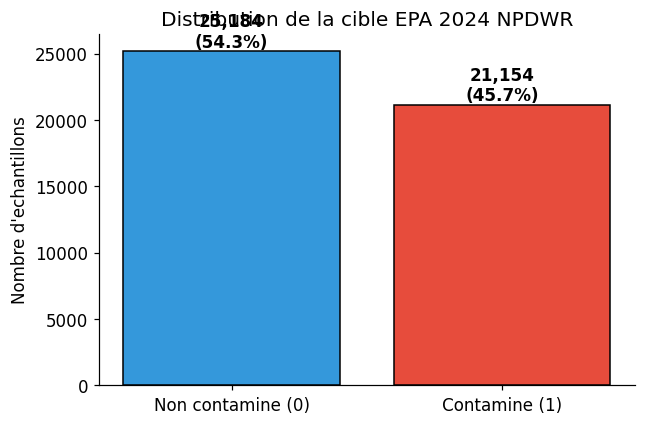

In [11]:
# Figure 1 — distribution des classes
counts = df["target"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Non contamine (0)", "Contamine (1)"], counts.values,
              color=["#3498db", "#e74c3c"], edgecolor="black")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:,}\n({100*v/len(df):.1f}%)",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Nombre d'echantillons"); ax.set_title("Distribution de la cible EPA 2024 NPDWR")
plt.tight_layout(); savefig(fig, "fig01_class_distribution.png"); plt.show()

## 5. Pretraitement et ingenierie des features

Cette section a fait l'objet d'une **analyse dediee** (taxonomie de la fuite, seuil de
manquants, regroupement thematique). Le detail methodologique est restitue ci-dessous,
puis applique de maniere **identique pour les 5 modeles**.

### 5.1 — Justification (niveau M2)

**Pourquoi exclure la fuite (*data leakage*)** — La cible est une **fonction deterministe**
des concentrations PFAS. Toute variable qui reexprime cette information donnerait un score
artificiellement parfait, sans valeur predictive sur des forages non encore analyses. On
retire donc quatre familles :
1. **`_ngL`** — les concentrations elles-memes (definissent la cible) ;
2. **`_detected`** — indicateurs de detection binaire (corr. jusqu'a 0,79 avec la cible) ;
3. **`label_`** — labels de detection par molecule ;
4. **colonnes exactes** : `sum_pfas_ngL`, `pfas_class_assignment`, `gm_well_id`,
   `collection_date`, `target_sum_gt70`, `gldas_dist_km` (artefact de grille), et
   **`gm_dataset_name`** — *choix documente* : c'est le nom du programme de surveillance,
   donc un **proxy administratif** fortement correle au protocole d'echantillonnage ; l'inclure
   reviendrait a apprendre « quel programme a echantillonne » plutot que la physique du forage
   (fuite deguisee).

**Le seuil de 40 % de manquants** — Au-dela, l'imputation **invente la majorite** de la
colonne (signal artificiel quasi-constant + risque de fuite via l'indicateur de manquant).
**31 colonnes** depassent 40 % : **17 sont des `_ngL`** (deja eliminees comme fuite, retrait
sans cout) et **14 sont de vraies features perdues** (co-contaminants rares, granulometrie
fine du sol, geometrie de forage `well_depth_ft`/`screen_*`/`depth_eff_*`). Le signal
hydrogeologique est partiellement recupere par des proxies mieux renseignes et conserves
(`depth_to_water_m`, `dist_nearest_gwl_km`, `hydr_grad_mag_permil`, `elevation_m`) avec leurs
drapeaux `depth_missing`/`topo_missing` qui encodent l'absence **sans inventer** de valeur.

**Redondance geographique** — on retire `dwr_basin`, `sgma_basin_name`, `sgma_subbasin_name`
(haute cardinalite administrative quasi-colineaire avec lat/lon et les regions conservees).

**Localisation RETIREE des features (`DROP_LOCATION=True`)** — c'est le **changement central**
de ce notebook : `latitude`, `longitude`, `county`, `regional_board`, `dwr_region`,
`sgma_region_office` ne sont **plus des features** d'aucun modele (RF, XGBoost, noeuds `sample`
du HGT). Motivation : la contamination PFAS est fortement **auto-correlee spatialement** ;
laisser la localisation en feature laisse les modeles **memoriser la geographie** plutot
qu'apprendre des mecanismes. Ici la localisation n'intervient **que via la TOPOLOGIE du graphe
relationnel** (clusters, KNN, sous-bassins, sites). Les coordonnees brutes sont neanmoins
conservees dans un objet `META` separe, **uniquement pour construire les aretes** du graphe et
les blocs de la CV spatiale.

**Pretraitement applique** — numeriques -> **imputation mediane** (robuste aux distributions
asymetriques) ; categorielles -> imputation **« Unknown »** + **OrdinalEncoder** (RF/XGBoost
gerent l'ordinal ; `soil_texture_class` a >100 modalites, one-hot exclu) ; pour le **HGT** ->
**StandardScaler** en plus (un reseau de neurones exige des entrees centrees-reduites).

### 5.2 — Listes de features (verifiees contre le fichier reel)

Apres retrait de la localisation, il reste **~94 features** (numeriques + categorielles).

In [12]:
# ── Sources de fuite (data leakage) ─────────────────────────────────────
LEAK_SUFFIXES      = ("_ngL",)        # concentrations PFAS (fondent la cible)
LEAK_BOOL_SUFFIXES = ("_detected",)   # indicateurs de detection
LEAK_PREFIXES      = ("label_",)      # labels de detection par molecule
LEAK_EXACT = {
    "sum_pfas_ngL", "pfas_class_assignment", "gm_well_id", "collection_date",
    "target", "target_sum_gt70", "gm_dataset_name", "gldas_dist_km",
}
DROP_REDUNDANT = {"dwr_basin", "sgma_basin_name", "sgma_subbasin_name"}

# ── Features temporelles derivees de collection_date ────────────────────
if "collection_date" in df.columns:
    _dt = pd.to_datetime(df["collection_date"], errors="coerce")
    df["year"]   = _dt.dt.year
    df["month"]  = _dt.dt.month
    df["season"] = ((_dt.dt.month % 12) // 3 + 1).astype("float")

# ── Drop > MISSING_THRESHOLD de manquants (calcule dynamiquement) ───────
_miss = df.isna().mean()
HIGH_MISSING_DROP = set(_miss[_miss > MISSING_THRESHOLD].index)
_n_leak_hm = sum(1 for c in HIGH_MISSING_DROP if c.endswith("_ngL"))
print(f"Colonnes > {MISSING_THRESHOLD:.0%} manquants : {len(HIGH_MISSING_DROP)} "
      f"({_n_leak_hm} sont des _ngL/fuite, {len(HIGH_MISSING_DROP)-_n_leak_hm} vraies features)")

# ── Localisation pure (retiree seulement si DROP_LOCATION=True) ─────────
LOCATION_FEATURES = {"latitude", "longitude", "county", "regional_board",
                     "dwr_region", "sgma_region_office"}
loc_drop = LOCATION_FEATURES if DROP_LOCATION else set()

# ── Categorielles candidates ────────────────────────────────────────────
CATEGORICAL_CANDIDATES = ["county", "regional_board", "dwr_region", "gm_well_category",
                          "sgma_region_office", "nearest_geotracker_type", "soil_texture_class"]
cat_cols = [c for c in CATEGORICAL_CANDIDATES
            if c in df.columns and c not in loc_drop and c not in HIGH_MISSING_DROP]

# ── Numeriques : tout le reste, hors fuite / manquants / redondances ────
def _is_leak(c):
    return (any(c.endswith(s) for s in LEAK_SUFFIXES)
            or any(c.endswith(s) for s in LEAK_BOOL_SUFFIXES)
            or any(c.startswith(p) for p in LEAK_PREFIXES)
            or c in LEAK_EXACT)

num_cols = [c for c in df.columns
            if df[c].dtype.kind in ("f", "i", "u")
            and not _is_leak(c) and c not in HIGH_MISSING_DROP
            and c not in DROP_REDUNDANT and c not in loc_drop and c not in cat_cols]

feature_names = num_cols + cat_cols
print(f"\nFeatures numeriques : {len(num_cols)} | categorielles : {len(cat_cols)} | TOTAL : {len(feature_names)}")

# ── Verification anti-fuite ─────────────────────────────────────────────
assert not any(_is_leak(c) for c in feature_names), "FUITE detectee dans les features !"
assert not any(c in HIGH_MISSING_DROP for c in feature_names), "Colonne >40% manquants retenue !"
print("Verifications anti-fuite / manquants : OK")

Colonnes > 40% manquants : 31 (17 sont des _ngL/fuite, 14 vraies features)

Features numeriques : 94 | categorielles : 3 | TOTAL : 97
Verifications anti-fuite / manquants : OK


In [13]:
# ── Verification : aucune feature de localisation ne subsiste ───────────
_loc = {"latitude", "longitude", "county", "regional_board", "dwr_region", "sgma_region_office"}
assert not (_loc & set(feature_names)), "Une feature de localisation est encore presente !"
print(f"Localisation retiree des features : OK ({len(feature_names)} features, 0 de localisation)")
print("Apercu numeriques :", num_cols[:6], "...")
print("Categorielles      :", cat_cols)

Localisation retiree des features : OK (97 features, 0 de localisation)
Apercu numeriques : ['dist_geotracker_km', 'n_geotracker_within_1km', 'n_geotracker_within_3km', 'n_geotracker_within_10km', 'n_geotracker_within_50km', 'cocontam_btbzs'] ...
Categorielles      : ['gm_well_category', 'nearest_geotracker_type', 'soil_texture_class']


### 5.3 — Profil des valeurs manquantes (features retenues)

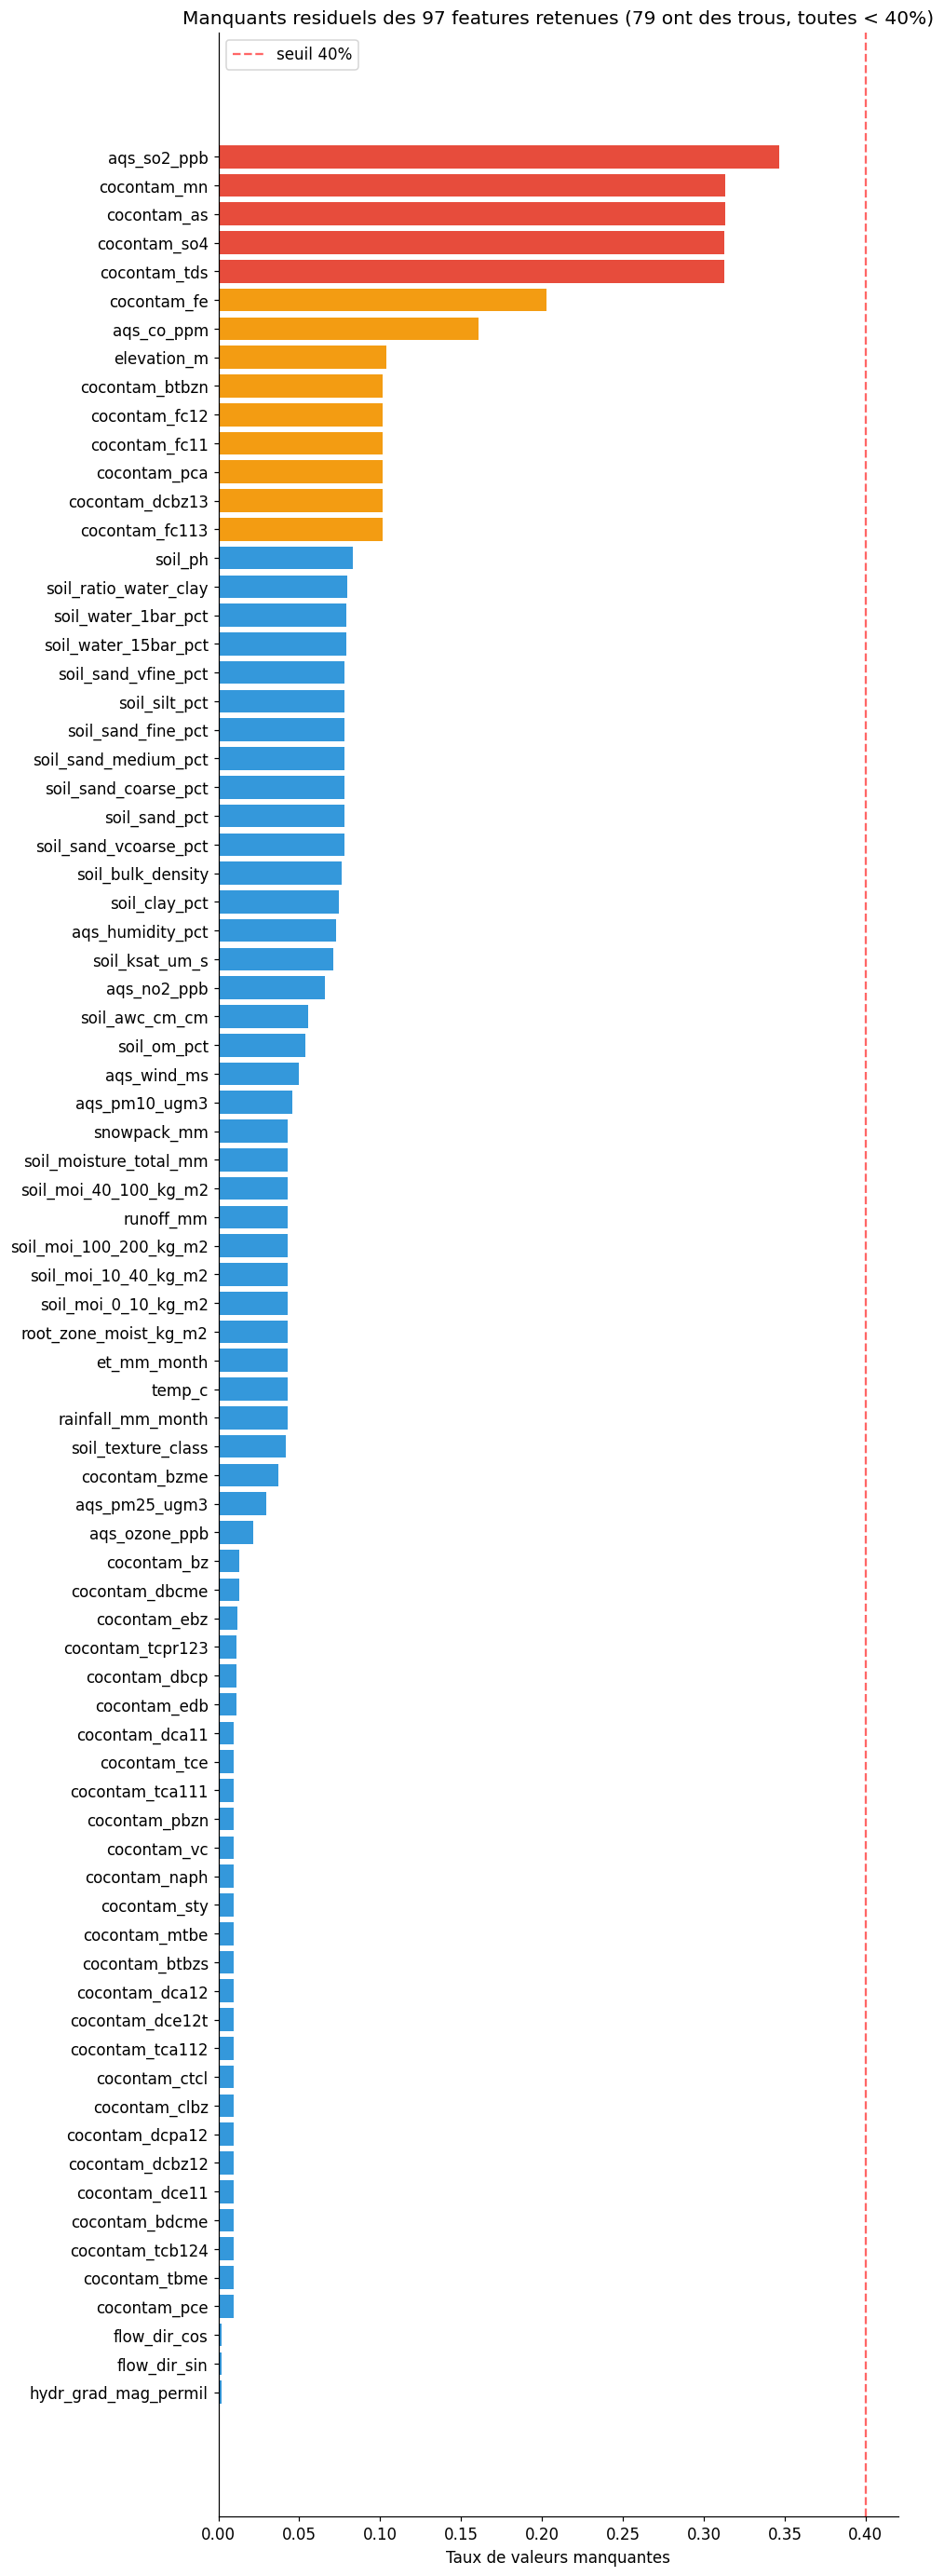

In [14]:
# Figure 2 — taux de manquants des features retenues (avant imputation)
miss_feat = df[feature_names].isna().mean().sort_values(ascending=False)
miss_top = miss_feat[miss_feat > 0]
fig, ax = plt.subplots(figsize=(9, max(3, len(miss_top)*0.32)))
if len(miss_top):
    cols = ["#e74c3c" if v > 0.3 else "#f39c12" if v > 0.1 else "#3498db" for v in miss_top]
    ax.barh(miss_top.index[::-1], miss_top.values[::-1], color=cols[::-1])
    ax.axvline(MISSING_THRESHOLD, color="red", ls="--", alpha=.6, label=f"seuil {MISSING_THRESHOLD:.0%}")
    ax.set_xlabel("Taux de valeurs manquantes"); ax.legend()
    ax.set_title(f"Manquants residuels des {len(feature_names)} features retenues "
                 f"({len(miss_top)} ont des trous, toutes < {MISSING_THRESHOLD:.0%})")
else:
    ax.text(.5, .5, "Aucune valeur manquante", ha="center")
plt.tight_layout(); savefig(fig, "fig02_missingness.png"); plt.show()

## 6. Split 60/20/20 + pretraitement

Un **unique split stratifie** train/val/test, **partage par les 5 modeles**, garantit une
comparaison equitable. Deux representations sont derivees du meme split :
- **tabulaire** (imputation mediane + OrdinalEncoder) -> RandomForest, XGBoost ;
- **standardisee** (la precedente + StandardScaler) -> HGT et construction du graphe.

In [15]:
X = df[feature_names].copy()
y = df["target"].values

# Split 60/20/20 (val pris sur le reste apres avoir mis le test de cote)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=VAL_SIZE, stratify=y_tmp, random_state=RANDOM_STATE)
print(f"Train: {len(y_train):,} ({100*y_train.mean():.1f}% +) | "
      f"Val: {len(y_val):,} ({100*y_val.mean():.1f}% +) | "
      f"Test: {len(y_test):,} ({100*y_test.mean():.1f}% +)")

# ── META (lat/lon + sous-bassin) : NON utilise comme feature, seulement pour le graphe ──
_meta_cols = ["latitude", "longitude"] + ([REGION_COL] if REGION_COL in df.columns else [])
META_train = df.loc[X_train.index, _meta_cols].reset_index(drop=True)
META_val   = df.loc[X_val.index,   _meta_cols].reset_index(drop=True)
META_test  = df.loc[X_test.index,  _meta_cols].reset_index(drop=True)
print(f"META (coords+region) pour le graphe : colonnes {_meta_cols}")

# ── Preprocesseur tabulaire (arbres) : impute median + ordinal encode ───
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1, encoded_missing_value=-1)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
proc_cols = num_cols + cat_cols   # ordre des colonnes en sortie du ColumnTransformer

# ── Representation standardisee (HGT) ───────────────────────────────────
scaler = StandardScaler().fit(X_train_proc)
X_train_sc = scaler.transform(X_train_proc)
X_val_sc   = scaler.transform(X_val_proc)
X_test_sc  = scaler.transform(X_test_proc)

# ── DataFrames standardisees nommees (pilotent la construction du graphe) ──
Xtr_sc_df = pd.DataFrame(X_train_sc, columns=proc_cols)
Xva_sc_df = pd.DataFrame(X_val_sc,   columns=proc_cols)
Xte_sc_df = pd.DataFrame(X_test_sc,  columns=proc_cols)

# ── Desequilibre ────────────────────────────────────────────────────────
# SMOTE est DESACTIVE dans ce notebook : le graphe relationnel a besoin des
# coordonnees reelles de chaque puits (les lignes synthetiques SMOTE n'en ont
# pas). Le dataset etant quasi-equilibre, on gere le desequilibre par les poids
# de classe (RF/HGT) et scale_pos_weight (XGBoost).
if USE_SMOTE:
    print("[info] USE_SMOTE ignore ici (incompatible avec le graphe relationnel).")
y_train_bal = y_train
print(f"X_train_proc {X_train_proc.shape} | X_train_sc {X_train_sc.shape}")

Train: 27,802 (45.7% +) | Val: 9,268 (45.7% +) | Test: 9,268 (45.7% +)
META (coords+region) pour le graphe : colonnes ['latitude', 'longitude', 'sgma_subbasin_name']
X_train_proc (27802, 97) | X_train_sc (27802, 97)


## 7. Fonctions utilitaires (metriques, courbes, SHAP)

Le **rappel (recall)** de la classe positive est la metrique prioritaire en contexte
sanitaire : un faux negatif = puits contamine non signale.

In [16]:
RESULTS = {}   # collecte des metriques de chaque modele pour la comparaison finale

def evaluate(name, y_true, y_pred, y_proba, store=True, show=True):
    m = {"name": name,
         "roc_auc": roc_auc_score(y_true, y_proba),
         "avg_precision": average_precision_score(y_true, y_proba),
         "accuracy": accuracy_score(y_true, y_pred),
         "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall": recall_score(y_true, y_pred),
         "f1": f1_score(y_true, y_pred)}
    if show:
        print(f"{'─'*52}\n  {name}\n{'─'*52}")
        for k in ["roc_auc","avg_precision","recall","precision","f1","balanced_accuracy","accuracy"]:
            print(f"  {k:20s}: {m[k]:.4f}")
    if store:
        RESULTS[name] = {"metrics": m, "y_pred": np.asarray(y_pred), "y_proba": np.asarray(y_proba)}
    return m

def plot_confusion(name, y_true, y_pred, fname):
    fig, ax = plt.subplots(figsize=(4.3, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=["< MCL (0)", ">= MCL (1)"],
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Matrice de confusion — {name}")
    plt.tight_layout(); savefig(fig, fname); plt.show()

def optuna_history_fig(study, title, fname, color="steelblue"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vals = [t.value for t in study.trials if t.value is not None]
    best = [max(vals[:i+1]) for i in range(len(vals))]
    axes[0].plot(vals, "o", alpha=.4, color=color, ms=5, label="Trial")
    axes[0].plot(best, "-", color="black", lw=2, label="Meilleur cumule")
    axes[0].set(xlabel="Trial", ylabel="Score objectif", title=f"{title} — historique Optuna")
    axes[0].legend(); axes[0].grid(alpha=.3)
    try:
        imp = optuna.importance.get_param_importances(study)
        axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color=color)
        axes[1].set(xlabel="Importance relative", title="Importance des hyperparametres")
        axes[1].grid(axis="x", alpha=.3)
    except Exception:
        axes[1].text(.5, .5, "Pas assez de trials", ha="center", transform=axes[1].transAxes)
    plt.tight_layout(); savefig(fig, fname); plt.show()

def shap_tree(model, X_sample, names, title, fname_bar, fname_bee):
    import shap
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X_sample)
    if isinstance(sv, list):            # ancien format : liste par classe
        sv = sv[1]
    if getattr(sv, "ndim", 2) == 3:     # format recent : (n, n_feat, n_classes)
        sv = sv[..., 1]
    fig = plt.figure()
    shap.summary_plot(sv, X_sample, feature_names=names, plot_type="bar", max_display=25, show=False)
    plt.title(f"SHAP (importance globale) — {title}"); plt.tight_layout()
    savefig(plt.gcf(), fname_bar); plt.show()
    fig = plt.figure()
    shap.summary_plot(sv, X_sample, feature_names=names, max_display=25, show=False)
    plt.title(f"SHAP (beeswarm) — {title}"); plt.tight_layout()
    savefig(plt.gcf(), fname_bee); plt.show()
    return sv

def shap_local_tree(model, X_full, names, title, fprefix, idx_pos, idx_neg):
    # INTERPRETABILITE LOCALE : waterfall SHAP pour 1 puits positif et 1 negatif.
    import shap
    expl = shap.TreeExplainer(model)
    base = expl.expected_value
    if np.ndim(base) > 0:                         # array : prend la classe positive si dispo
        ba = np.atleast_1d(base)
        base = ba[1] if len(ba) > 1 else ba[0]
    base = float(base)
    for tag, idx in [("positif", idx_pos), ("negatif", idx_neg)]:
        sv = expl.shap_values(X_full[idx:idx+1])
        if isinstance(sv, list):
            sv = sv[1]
        if getattr(sv, "ndim", 2) == 3:
            sv = sv[..., 1]
        expl_obj = shap.Explanation(values=sv[0], base_values=float(base),
                                    data=X_full[idx], feature_names=list(names))
        plt.figure()
        shap.plots.waterfall(expl_obj, max_display=15, show=False)
        plt.title(f"SHAP local ({tag}) — {title}"); plt.tight_layout()
        savefig(plt.gcf(), f"{fprefix}_{tag}.png"); plt.show()

# echantillon test commun pour SHAP (reproductible)
_rng = np.random.RandomState(RANDOM_STATE)
_shap_idx = _rng.choice(len(X_test_proc), min(SHAP_SAMPLE, len(X_test_proc)), replace=False)
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# indices d'un puits POSITIF et d'un puits NEGATIF dans le test (interpretabilite locale)
IDX_POS = int(np.where(y_test == 1)[0][0])
IDX_NEG = int(np.where(y_test == 0)[0][0])
print(f"Fonctions utilitaires pretes. Cas locaux -> positif #{IDX_POS}, negatif #{IDX_NEG}")

Fonctions utilitaires pretes. Cas locaux -> positif #2, negatif #0


## 8. Modele 2 — Random Forest (**sans localisation**)

Baseline tabulaire interpretable (bagging), entrainee **sans aucune feature de localisation**
(lat/lon/county/regions retirees). Pipeline complet : **Optuna** (AUC en CV 3-fold),
**courbe d'apprentissage** (OOB & validation vs nombre d'arbres), **matrice de confusion**,
**validation croisee 5-fold**, **analyse SHAP globale + locale**.

### 8.1 — Optimisation Optuna

  0%|          | 0/40 [00:00<?, ?it/s]

Meilleur AUC-CV : 0.9714 | params : {'n_estimators': 400, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2}


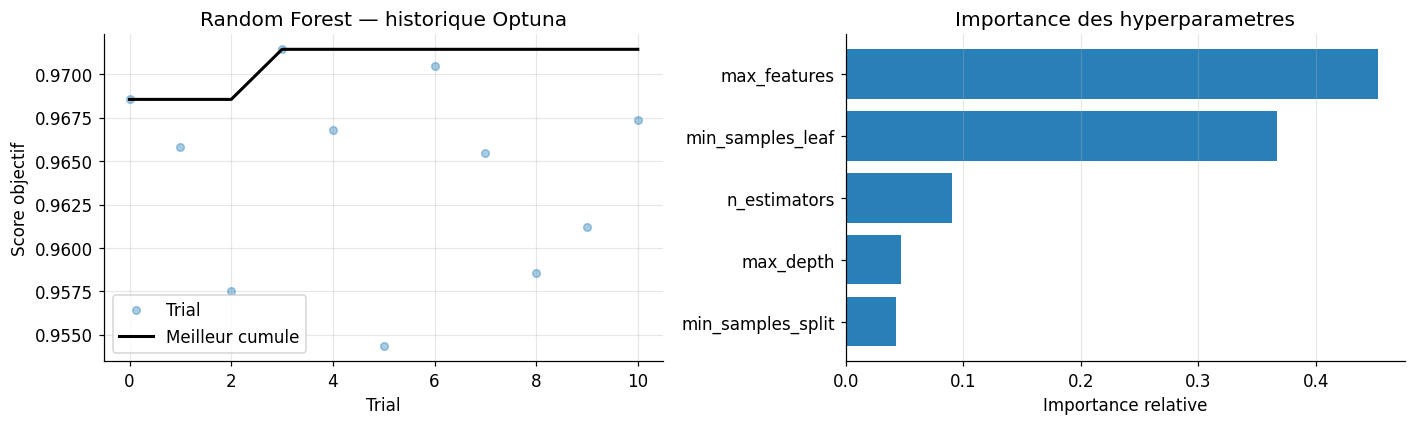

In [17]:
scale_pos = (y_train_bal == 0).sum() / max(1, (y_train_bal == 1).sum())

def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
        max_depth=trial.suggest_categorical("max_depth", [None, 15, 20, 30]),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 15),
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    sc = cross_val_score(RandomForestClassifier(**params), X_train_proc, y_train_bal,
                         cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                         scoring="roc_auc", n_jobs=1)
    return sc.mean()

study_rf = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.enqueue_trial({"n_estimators": 500, "max_depth": None, "max_features": "sqrt",
                        "min_samples_leaf": 2, "min_samples_split": 2})
study_rf.optimize(objective_rf, n_trials=_TRIALS["rf"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-CV :", round(study_rf.best_value, 4), "| params :", study_rf.best_params)
optuna_history_fig(study_rf, "Random Forest", "fig03_optuna_rf.png", color="#2980b9")

### 8.2 — Entrainement final + evaluation

In [18]:
best_rf_params = {**study_rf.best_params, "class_weight": "balanced",
                  "oob_score": True, "n_jobs": -1, "random_state": RANDOM_STATE}
rf = RandomForestClassifier(**best_rf_params).fit(X_train_proc, y_train_bal)
print(f"OOB score : {rf.oob_score_:.4f}")
y_pred_rf  = rf.predict(X_test_proc)
y_proba_rf = rf.predict_proba(X_test_proc)[:, 1]
m_rf = evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)

OOB score : 0.9312
────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────
  roc_auc             : 0.9786
  avg_precision       : 0.9763
  recall              : 0.9199
  precision           : 0.9295
  f1                  : 0.9247
  balanced_accuracy   : 0.9307
  accuracy            : 0.9316


### 8.3 — Courbe d'apprentissage (OOB & validation vs nombre d'arbres)

Le Random Forest n'a pas de courbe de perte iterative ; on suit a la place l'**erreur OOB**
et l'**AUC de validation** quand on ajoute des arbres (`warm_start`) — diagnostic de
convergence et de sur-apprentissage.

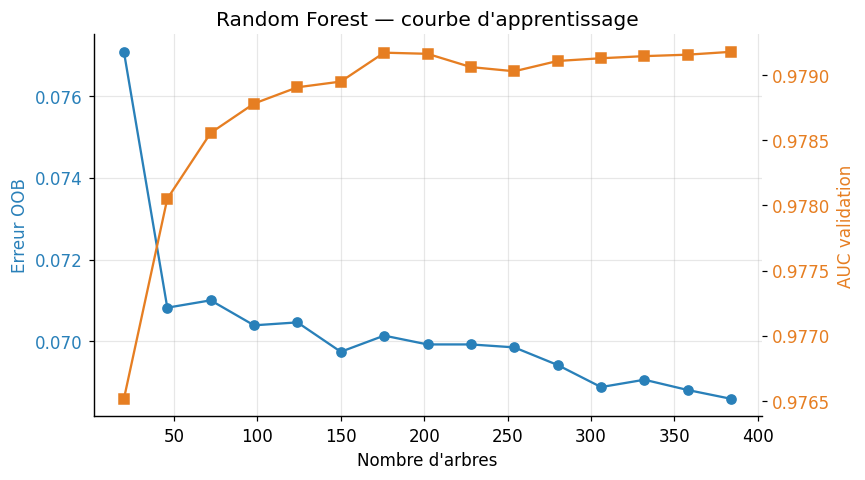

In [19]:
stages = list(range(20, int(best_rf_params["n_estimators"]) + 1, max(20, int(best_rf_params["n_estimators"])//15)))
rf_lc = RandomForestClassifier(**{**best_rf_params, "warm_start": True, "n_estimators": stages[0]})
oob_err, val_auc = [], []
for n in stages:
    rf_lc.set_params(n_estimators=n); rf_lc.fit(X_train_proc, y_train_bal)
    oob_err.append(1 - rf_lc.oob_score_)
    val_auc.append(roc_auc_score(y_val, rf_lc.predict_proba(X_val_proc)[:, 1]))
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(stages, oob_err, "o-", color="#2980b9", label="Erreur OOB"); ax1.set_xlabel("Nombre d'arbres")
ax1.set_ylabel("Erreur OOB", color="#2980b9"); ax1.tick_params(axis="y", labelcolor="#2980b9"); ax1.grid(alpha=.3)
ax2 = ax1.twinx(); ax2.plot(stages, val_auc, "s-", color="#e67e22", label="AUC validation")
ax2.set_ylabel("AUC validation", color="#e67e22"); ax2.tick_params(axis="y", labelcolor="#e67e22")
ax1.set_title("Random Forest — courbe d'apprentissage")
plt.tight_layout(); savefig(fig, "fig04_rf_learning_curve.png"); plt.show()

### 8.4 — Validation croisee 5-fold + matrice de confusion

  CV roc_auc           : 0.9741 ± 0.0011
  CV f1                : 0.9193 ± 0.0023
  CV recall            : 0.9105 ± 0.0080
  CV balanced_accuracy : 0.9257 ± 0.0022


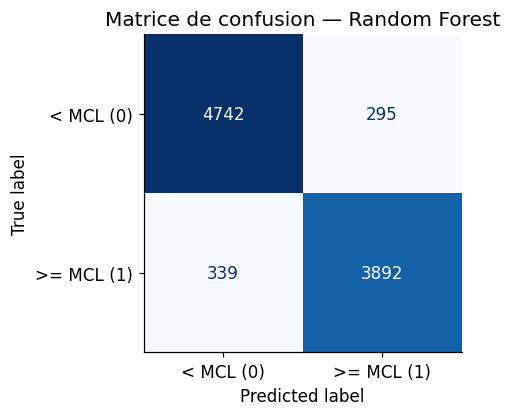

In [20]:
cv_rf = cross_validate(RandomForestClassifier(**{**best_rf_params, "oob_score": False}),
                       X_train_proc, y_train_bal, cv=skf5,
                       scoring=["roc_auc", "f1", "recall", "balanced_accuracy"], n_jobs=-1)
for k in ["roc_auc", "f1", "recall", "balanced_accuracy"]:
    print(f"  CV {k:18s}: {cv_rf['test_'+k].mean():.4f} ± {cv_rf['test_'+k].std():.4f}")
plot_confusion("Random Forest", y_test, y_pred_rf, "fig05_rf_confusion.png")

### 8.5 — Analyse SHAP globale + LOCALE (Random Forest)

La SHAP **globale** (beeswarm/bar) montre l'importance moyenne ; la SHAP **locale**
(waterfall) explique une **decision individuelle** — pourquoi CE puits est classe positif/negatif.

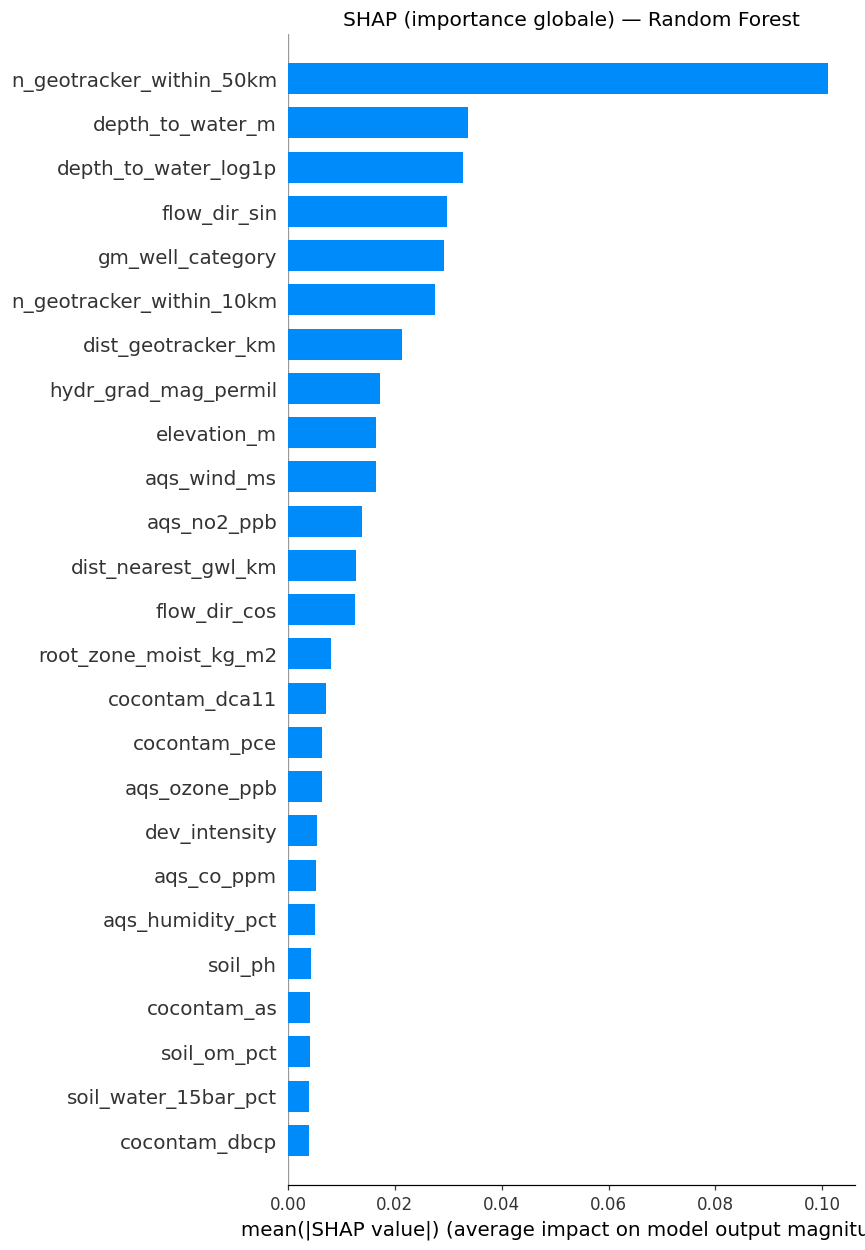

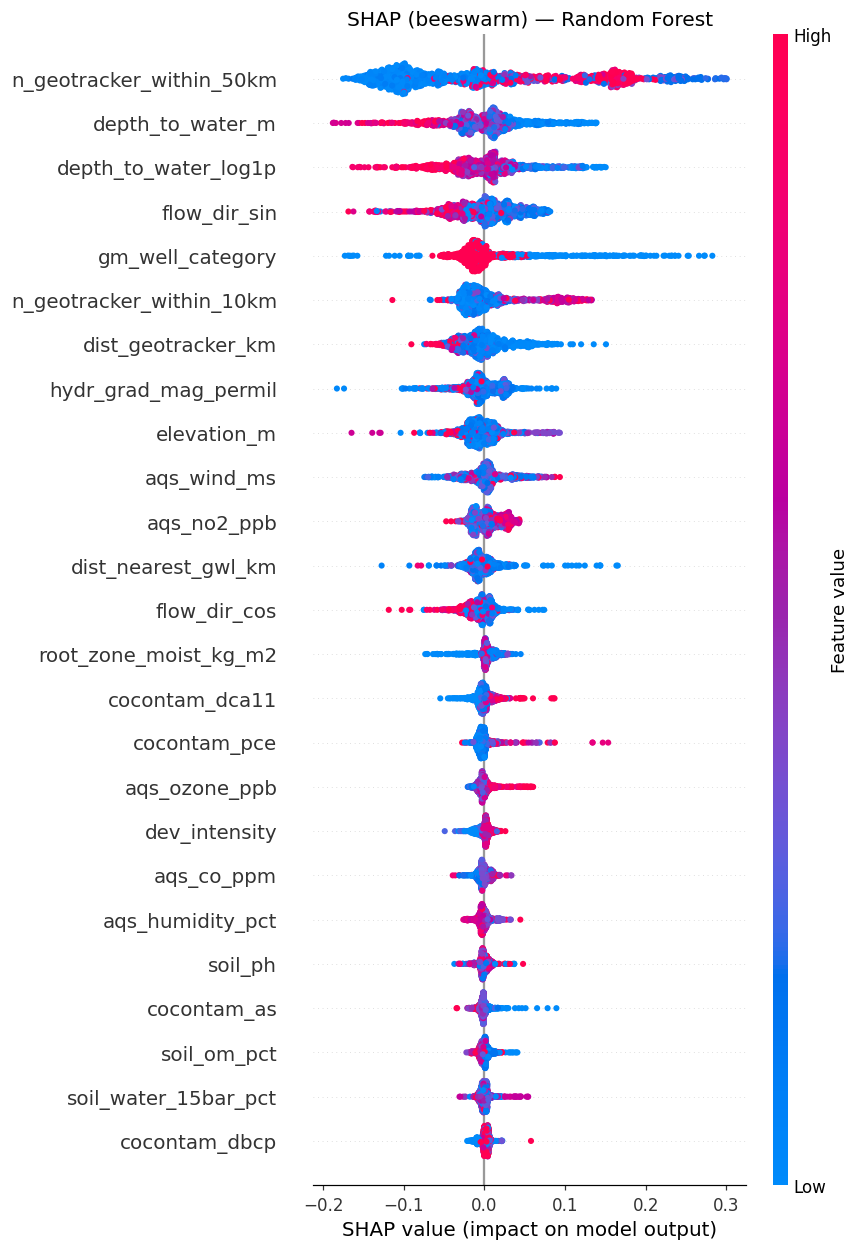

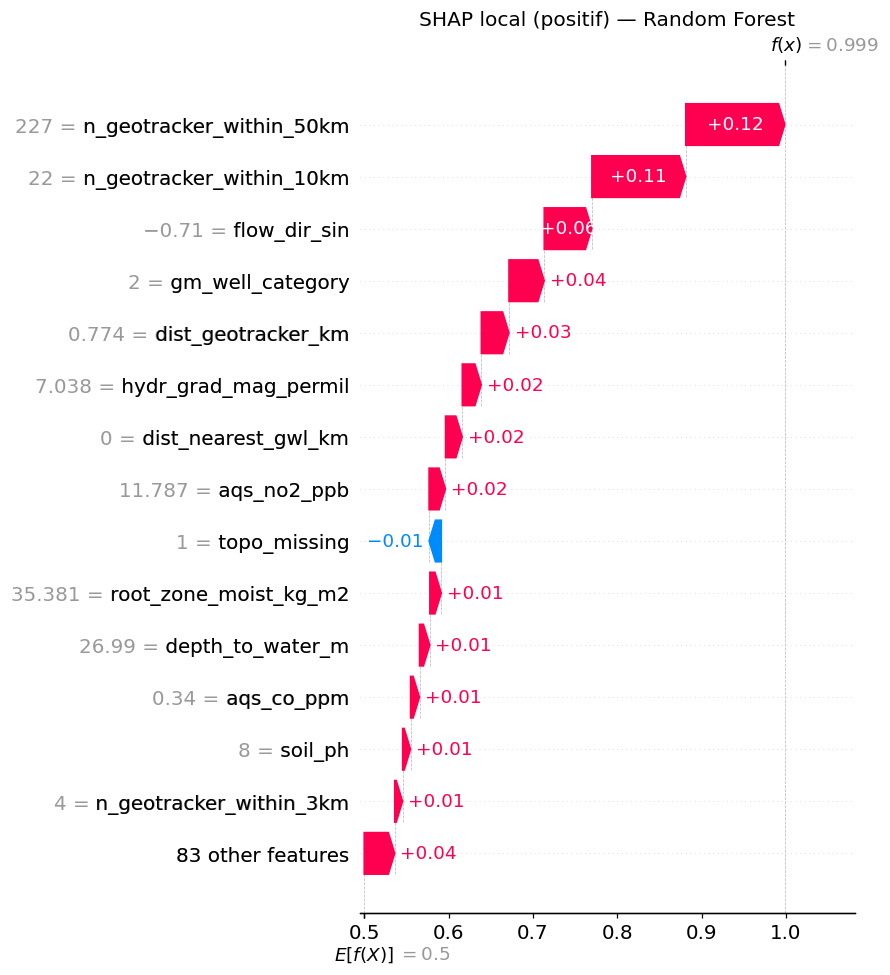

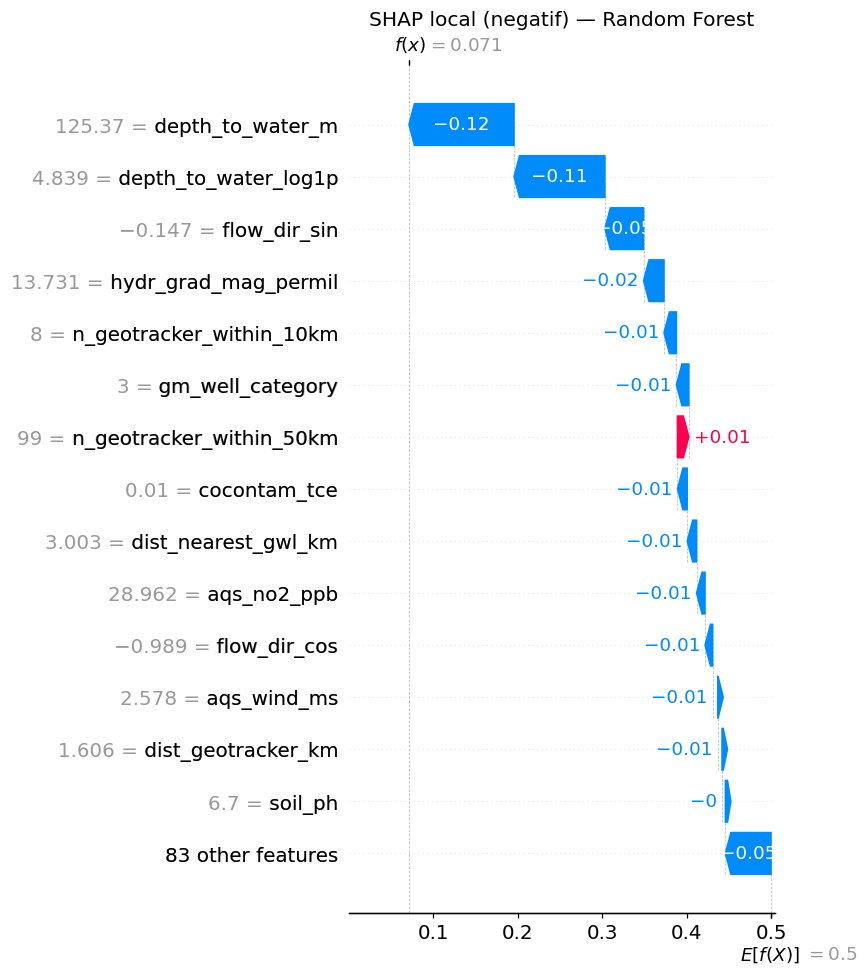

In [21]:
if RUN_SHAP:
    sv_rf = shap_tree(rf, X_test_proc[_shap_idx], proc_cols, "Random Forest",
                      "fig06_shap_bar_rf.png", "fig07_shap_beeswarm_rf.png")
    shap_local_tree(rf, X_test_proc, proc_cols, "Random Forest",
                    "fig06b_shap_local_rf", IDX_POS, IDX_NEG)
else:
    print("SHAP desactive (RUN_SHAP=False)")

## 9. Modele 3 — XGBoost (**sans localisation**)

Gradient boosting, etat de l'art tabulaire, entraine **sans feature de localisation**.
**Optuna** (AUC sur validation interne + early stopping), **courbe d'apprentissage** native
(AUC vs iterations), **matrice de confusion**, **analyse SHAP globale + locale**.

### 9.1 — Optimisation Optuna

  0%|          | 0/60 [00:00<?, ?it/s]

Meilleur AUC-val : 0.9779 | params : {'n_estimators': 1900, 'learning_rate': 0.07747827964528882, 'max_depth': 12, 'subsample': 0.9996467385418862, 'colsample_bytree': 0.8067417957912446, 'min_child_weight': 3, 'gamma': 0.23295832331943075, 'reg_alpha': 3.234374258574196e-05, 'reg_lambda': 0.022849116912737368}


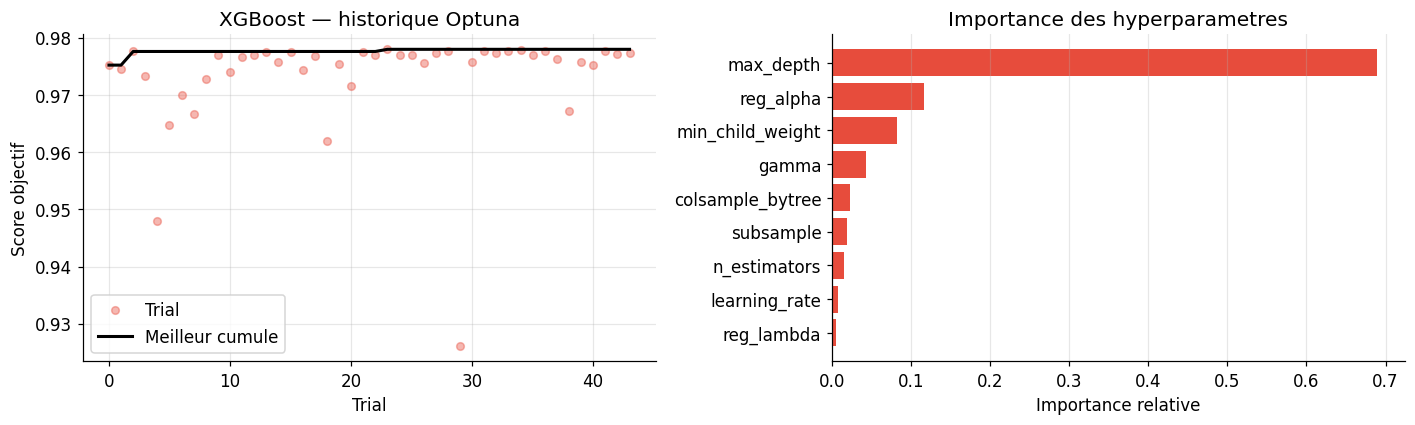

In [22]:
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 2000, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        gamma=trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        scale_pos_weight=scale_pos, tree_method="hist", n_jobs=-1,
        random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
    model = xgb.XGBClassifier(**params, early_stopping_rounds=40)
    model.fit(X_train_proc, y_train_bal, eval_set=[(X_val_proc, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val_proc)[:, 1])

study_xgb = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study_xgb.enqueue_trial({"n_estimators": 1000, "learning_rate": 0.05, "max_depth": 6,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3, "gamma": 0.1,
    "reg_alpha": 0.1, "reg_lambda": 1.0})
study_xgb.optimize(objective_xgb, n_trials=_TRIALS["xgb"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-val :", round(study_xgb.best_value, 4), "| params :", study_xgb.best_params)
optuna_history_fig(study_xgb, "XGBoost", "fig08_optuna_xgb.png", color="#e74c3c")

### 9.2 — Entrainement final + evaluation

In [23]:
best_xgb_params = {**study_xgb.best_params, "scale_pos_weight": scale_pos,
                   "tree_method": "hist", "n_jobs": -1, "random_state": RANDOM_STATE,
                   "eval_metric": "auc", "verbosity": 0}
xgb_model = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=50)
xgb_model.fit(X_train_proc, y_train_bal, eval_set=[(X_val_proc, y_val)], verbose=False)
print(f"Best iteration : {xgb_model.best_iteration} | best AUC val : {xgb_model.best_score:.4f}")
y_pred_xgb  = xgb_model.predict(X_test_proc)
y_proba_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
m_xgb = evaluate("XGBoost", y_test, y_pred_xgb, y_proba_xgb)

Best iteration : 174 | best AUC val : 0.9779
────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────
  roc_auc             : 0.9766
  avg_precision       : 0.9739
  recall              : 0.9229
  precision           : 0.9223
  f1                  : 0.9226
  balanced_accuracy   : 0.9288
  accuracy            : 0.9293


### 9.3 — Courbe d'apprentissage native (AUC vs iterations)

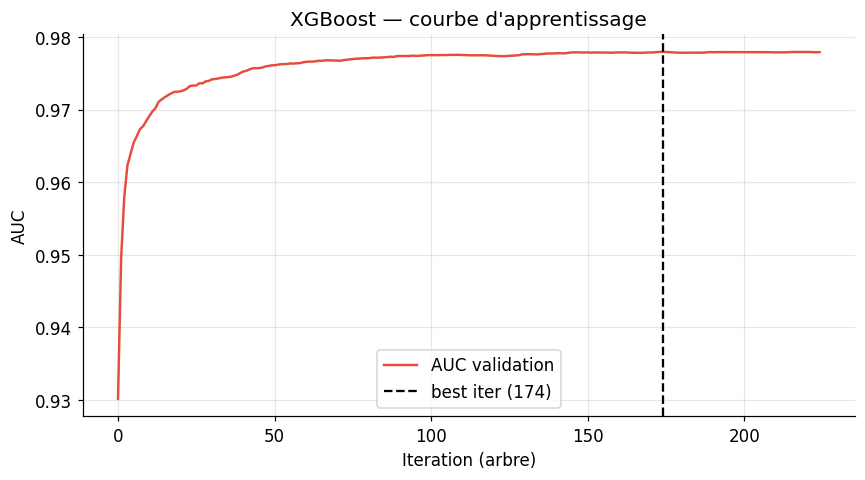

In [24]:
hist = xgb_model.evals_result()
if hist:
    auc_curve = hist["validation_0"]["auc"]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(auc_curve, color="#e74c3c", lw=1.6, label="AUC validation")
    ax.axvline(xgb_model.best_iteration, color="k", ls="--", label=f"best iter ({xgb_model.best_iteration})")
    ax.set(xlabel="Iteration (arbre)", ylabel="AUC", title="XGBoost — courbe d'apprentissage")
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); savefig(fig, "fig09_xgb_learning_curve.png"); plt.show()

### 9.4 — Validation croisee 5-fold + matrice de confusion

  CV roc_auc           : 0.9732 ± 0.0015
  CV f1                : 0.9175 ± 0.0026
  CV recall            : 0.9157 ± 0.0052
  CV balanced_accuracy : 0.9241 ± 0.0024


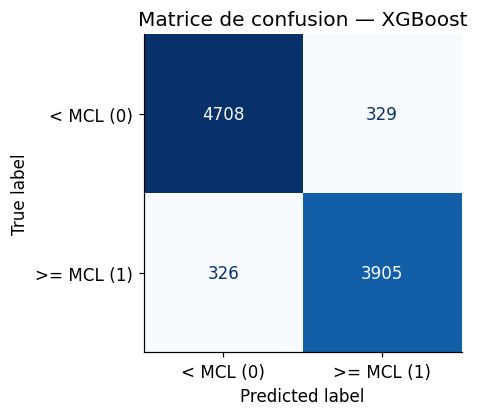

In [25]:
cv_xgb = cross_validate(
    xgb.XGBClassifier(**{k: v for k, v in best_xgb_params.items() if k != "eval_metric"}),
    X_train_proc, y_train_bal, cv=skf5,
    scoring=["roc_auc", "f1", "recall", "balanced_accuracy"], n_jobs=-1)
for k in ["roc_auc", "f1", "recall", "balanced_accuracy"]:
    print(f"  CV {k:18s}: {cv_xgb['test_'+k].mean():.4f} ± {cv_xgb['test_'+k].std():.4f}")
plot_confusion("XGBoost", y_test, y_pred_xgb, "fig10_xgb_confusion.png")

### 9.5 — Analyse SHAP globale + LOCALE (XGBoost)

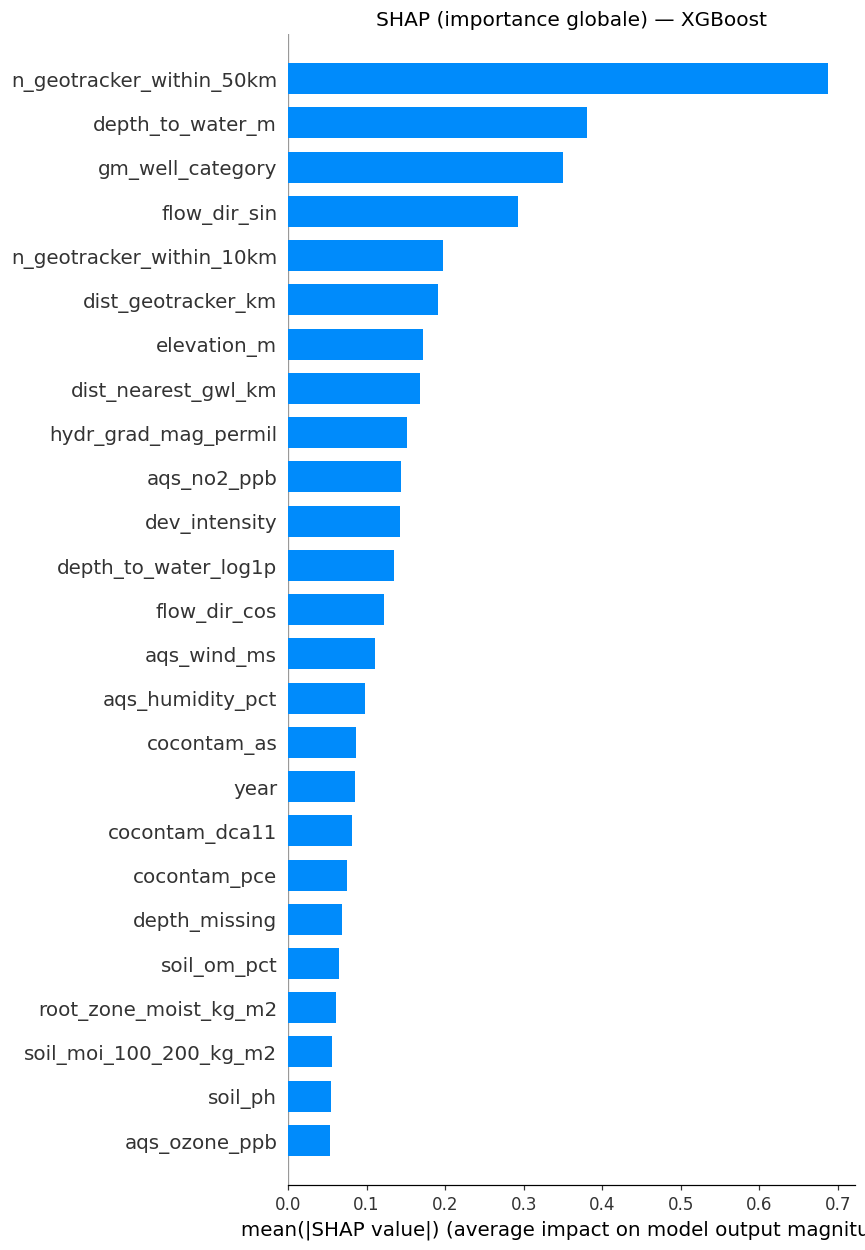

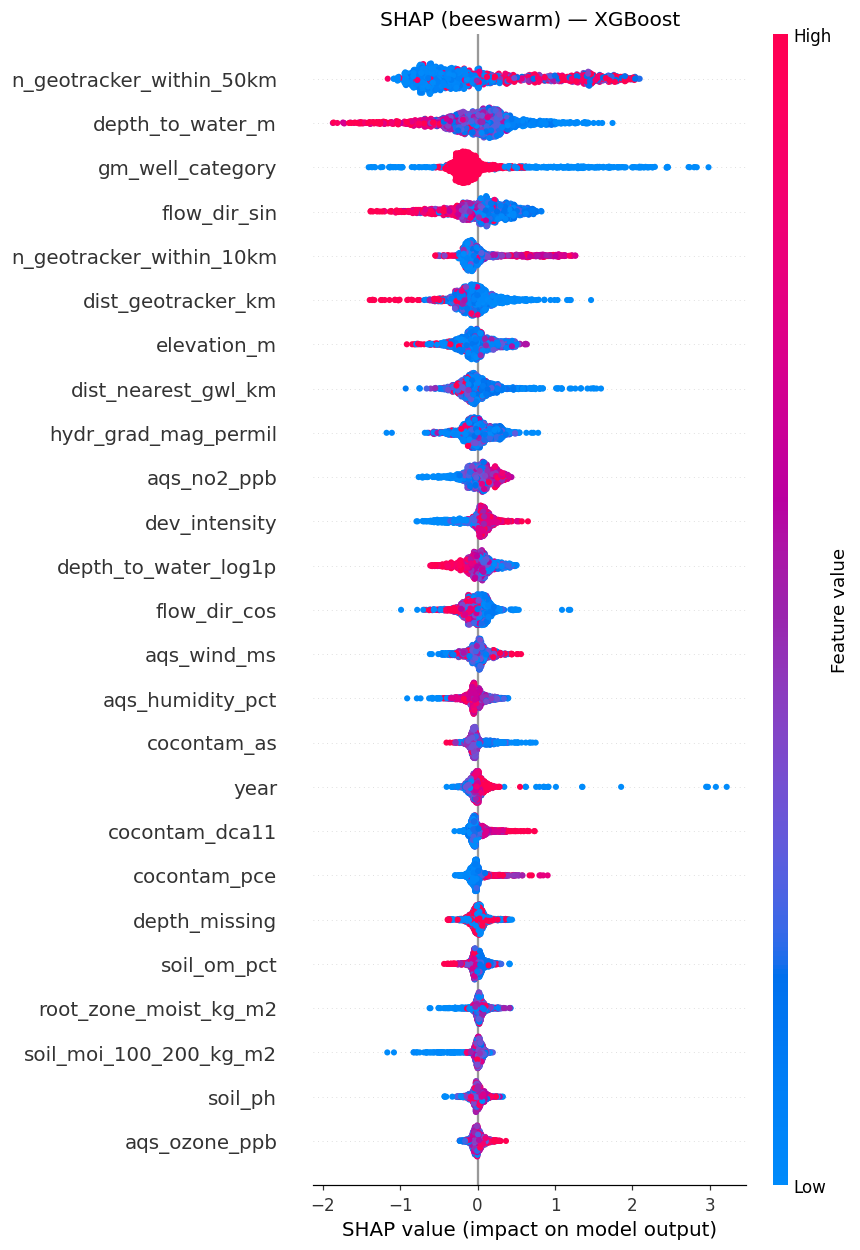

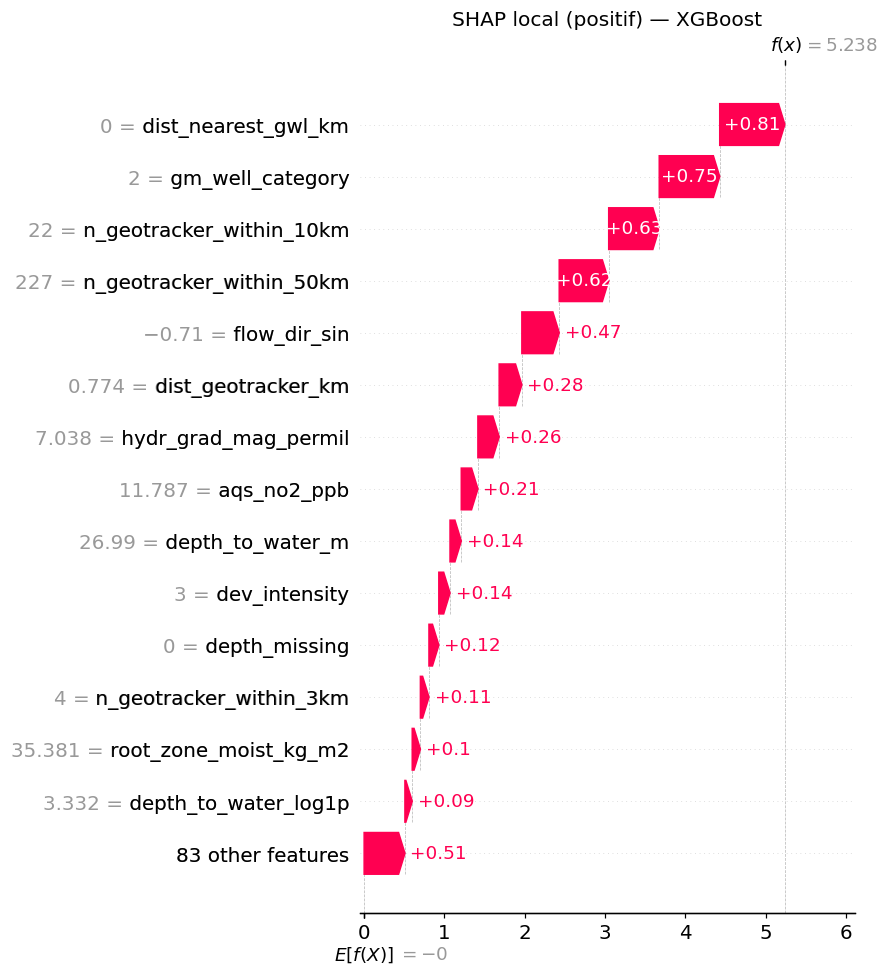

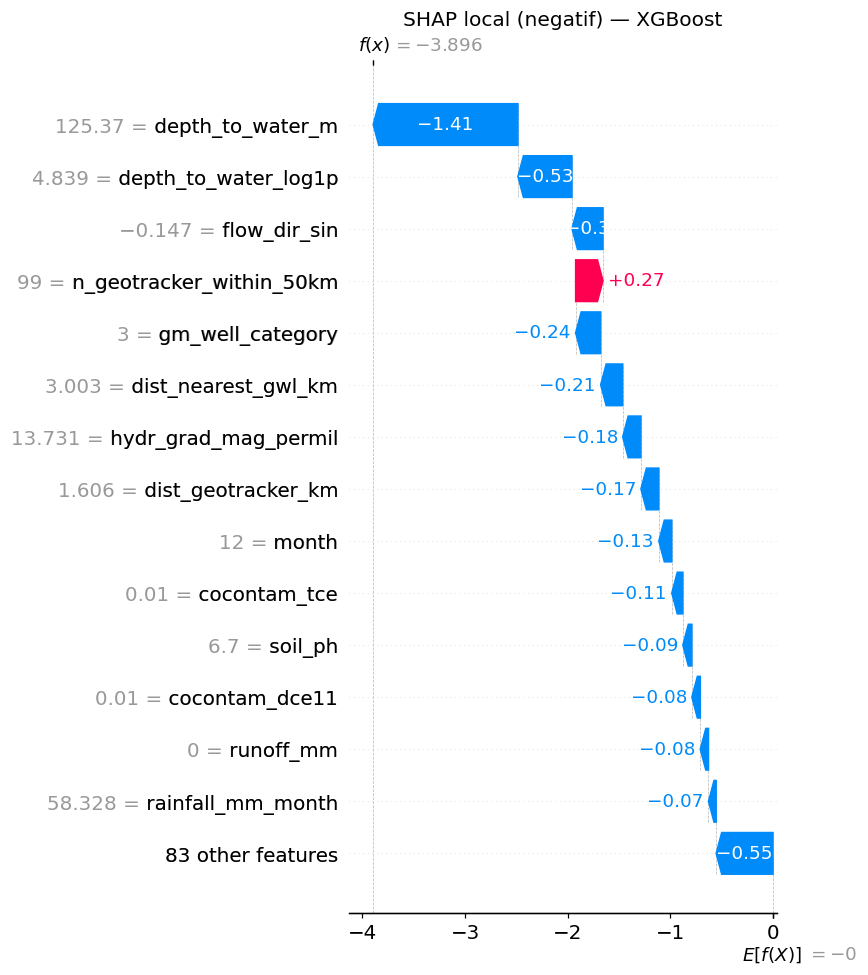

In [26]:
if RUN_SHAP:
    sv_xgb = shap_tree(xgb_model, X_test_proc[_shap_idx], proc_cols, "XGBoost",
                       "fig11_shap_bar_xgb.png", "fig12_shap_beeswarm_xgb.png")
    shap_local_tree(xgb_model, X_test_proc, proc_cols, "XGBoost",
                    "fig11b_shap_local_xgb", IDX_POS, IDX_NEG)
else:
    print("SHAP desactive (RUN_SHAP=False)")

## 10. Modele 1 — HGT a graphe **RELATIONNEL**

**Coeur du travail de recherche.** Contrairement au notebook precedent (noeuds-attributs par
groupe relies en identite), le graphe repose ici sur de **vraies entites partagees** et des
**aretes spatiales**, sans aucune feature de localisation sur le noeud `sample` :

| Element | Role |
|---|---|
| **`source`** (sites GeoTracker) | Noeuds externes fixes. Chaque puits est relie aux sites dans `SOURCE_RADIUS_KM` (≤ `SOURCE_KMAX`). Deux puits proches d'un **meme site** echangent de l'information -> couplage *par source de contamination*. |
| **`subbasin`** (sous-bassins SGMA) | Un noeud par sous-bassin, **hub hydrogeologique** partage par tous ses puits. |
| **`geo_cluster`** (KMeans) | Hub spatial grossier (KMeans fit sur le train). |
| **`near_geo`** (KNN spatial) | Aretes directes `sample<->sample` entre les `k` plus proches voisins geographiques. |

> **Anti-fuite** : KMeans / KNN / sous-bassins sont construits **par split** (intra-split) ;
> les sites `source` forment un **registre externe fixe**. Les coordonnees ne servent qu'a
> **construire les aretes** (elles ne sont jamais des features du noeud `sample`).

### 10.1 — Construction du graphe relationnel

In [27]:
from sklearn.neighbors import NearestNeighbors, BallTree

if TORCH_GEOMETRIC_AVAILABLE:
    LATLON_META = ["latitude", "longitude"]

    # ── Registre SOURCE (sites GeoTracker) : noeuds externes fixes, partages ──
    SOURCE_X, SRC_TREE, N_SITES = None, None, 0
    if USE_SOURCE_NODES and sites_df is not None:
        _sc = sites_df[["latitude", "longitude"]].values.astype("float64")
        SRC_TREE = BallTree(np.radians(_sc), metric="haversine")
        _st = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)\
              .fit_transform(sites_df[["site_type"]].astype(str)).ravel() if "site_type" in sites_df else np.zeros(len(_sc))
        _z = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-9)
        SOURCE_X = np.column_stack([_z(_sc[:, 0]), _z(_sc[:, 1]), _z(_st)]).astype("float32")
        N_SITES = len(_sc)
        print(f"Noeuds source : {N_SITES} sites GeoTracker | rayon {SOURCE_RADIUS_KM} km | k_max {SOURCE_KMAX}")
    else:
        print("Noeuds source desactives -> graphe = subbasin + geo_cluster + near_geo")

    R_RAD = SOURCE_RADIUS_KM / 6371.0   # rayon en radians (haversine)

    def source_edges(coords):
        d, idx = SRC_TREE.query(np.radians(coords), k=min(SOURCE_KMAX, N_SITES))
        s, t = [], []
        for i in range(len(coords)):
            keep = [idx[i, 0]]                      # site le plus proche toujours garde
            for j in range(1, idx.shape[1]):
                if d[i, j] <= R_RAD:
                    keep.append(idx[i, j])
            for k in keep:
                s.append(i); t.append(int(k))
        return np.array(s), np.array(t)

    def region_nodes(meta):
        reg = meta[REGION_COL].fillna("UNKNOWN").astype(str).values if REGION_COL in meta else np.array(["ALL"]*len(meta))
        cats, inv = np.unique(reg, return_inverse=True)
        feats = np.zeros((len(cats), 3), "float32")
        lat, lon = meta["latitude"].values, meta["longitude"].values
        for k in range(len(cats)):
            m = inv == k
            feats[k] = [lat[m].mean(), lon[m].mean(), np.log1p(m.sum())]
        feats = (feats - feats.mean(0)) / (feats.std(0) + 1e-9)
        return inv.astype("int64"), feats

    def knn_edges(coords, k):
        k = min(k + 1, len(coords)); nn = NearestNeighbors(n_neighbors=k).fit(coords)
        _, idx = nn.kneighbors(coords)
        s = np.repeat(np.arange(len(coords)), idx.shape[1] - 1); d = idx[:, 1:].reshape(-1)
        e = np.stack([s, d]); return np.concatenate([e, e[::-1]], 1)   # non oriente

    def fit_geo_kmeans(coords, n=N_GEO_CLUSTERS):
        return KMeans(min(n, max(2, len(coords)//50)), random_state=RANDOM_STATE, n_init=10).fit(coords)

    def build_relational_graph(X_scaled, y_arr, meta, kmeans):
        d = HeteroData(); n = len(X_scaled)
        coords = meta[LATLON_META].values.astype("float32")
        d["sample"].x = torch.FloatTensor(np.asarray(X_scaled))
        d["sample"].y = torch.LongTensor(np.asarray(y_arr))
        sr = np.arange(n)
        # 1) SOURCE (partage, externe)
        if SOURCE_X is not None:
            d["source"].x = torch.FloatTensor(SOURCE_X)
            ss, st = source_edges(coords)
            if len(ss):
                d["sample", "near_source", "source"].edge_index = torch.tensor(np.stack([ss, st]), dtype=torch.long)
                d["source", "source_of", "sample"].edge_index   = torch.tensor(np.stack([st, ss]), dtype=torch.long)
        # 2) SUBBASIN (hub hydrogeologique)
        inv, rfeat = region_nodes(meta)
        d["subbasin"].x = torch.FloatTensor(rfeat)
        d["sample", "in_basin", "subbasin"].edge_index = torch.tensor(np.stack([sr, inv]), dtype=torch.long)
        d["subbasin", "basin_of", "sample"].edge_index = torch.tensor(np.stack([inv, sr]), dtype=torch.long)
        # 3) GEO_CLUSTER (hub spatial KMeans)
        lab = kmeans.predict(coords)
        d["geo_cluster"].x = torch.FloatTensor(kmeans.cluster_centers_.astype("float32"))
        d["sample", "located_in", "geo_cluster"].edge_index = torch.tensor(np.stack([sr, lab]), dtype=torch.long)
        d["geo_cluster", "contains", "sample"].edge_index   = torch.tensor(np.stack([lab, sr]), dtype=torch.long)
        # 4) NEAR_GEO (KNN spatial sample<->sample)
        if KNN_SPATIAL_K and KNN_SPATIAL_K > 0:
            d["sample", "near_geo", "sample"].edge_index = torch.tensor(knn_edges(coords, KNN_SPATIAL_K), dtype=torch.long)
        return d

    geo_km = fit_geo_kmeans(META_train[LATLON_META].values.astype("float32"))
    train_data = build_relational_graph(Xtr_sc_df.values, y_train_bal, META_train, geo_km)
    val_data   = build_relational_graph(Xva_sc_df.values, y_val,       META_val,   geo_km)
    test_data  = build_relational_graph(Xte_sc_df.values, y_test,      META_test,  geo_km)
    print("\nTypes de noeuds :", list(train_data.node_types))
    for a, b, c in train_data.edge_types:
        print(f"  {a} -[{b}]-> {c}: {train_data[a, b, c].edge_index.shape[1]:,} aretes")

Noeuds source : 463 sites GeoTracker | rayon 10.0 km | k_max 6

Types de noeuds : ['sample', 'source', 'subbasin', 'geo_cluster']
  sample -[near_source]-> source: 95,601 aretes
  source -[source_of]-> sample: 95,601 aretes
  sample -[in_basin]-> subbasin: 27,802 aretes
  subbasin -[basin_of]-> sample: 27,802 aretes
  sample -[located_in]-> geo_cluster: 27,802 aretes
  geo_cluster -[contains]-> sample: 27,802 aretes
  sample -[near_geo]-> sample: 444,832 aretes


### 10.2 — Architecture HGT

In [28]:
class HGT_Classifier(nn.Module):
    # HGT pour classification binaire ; renvoie logits ou embeddings du noeud 'sample'.
    def __init__(self, metadata, hidden_channels=64, out_channels=2,
                 num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.lin_dict = nn.ModuleDict({nt: PyGLinear(-1, hidden_channels) for nt in metadata[0]})
        self.convs = nn.ModuleList([
            HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads)
            for _ in range(num_layers)])
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(max(1, hidden_channels // 2), out_channels))

    def forward(self, x_dict, edge_index_dict, return_embeddings=False):
        x_dict = {nt: self.lin_dict[nt](x).relu() for nt, x in x_dict.items()}
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
        emb = x_dict["sample"]
        return emb if return_embeddings else self.classifier(emb)

def graph_tensors(data):
    xd = {nt: data[nt].x.to(device) for nt in data.node_types}
    ed = {et: data[et].edge_index.to(device) for et in data.edge_types}
    return xd, ed

if TORCH_GEOMETRIC_AVAILABLE:
    metadata = train_data.metadata()
    _m0 = HGT_Classifier(metadata).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(train_data); _ = _m0(_xd, _ed)
    print(f"HGT relationnel initialise — {sum(p.numel() for p in _m0.parameters()):,} parametres")

HGT relationnel initialise — 170,978 parametres


### 10.3 — Boucle d'entrainement (bruit gaussien + DropEdge, selection sur val F1)

In [29]:
def augment_graph(xd, ed, noise=0.01, drop=0.1):
    xa = {nt: x + noise * torch.randn_like(x) for nt, x in xd.items()}
    ea = {}
    for et, ei in ed.items():
        keep = (torch.rand(ei.size(1), device=ei.device) > drop).nonzero(as_tuple=True)[0]
        ea[et] = ei if keep.numel() == 0 else ei[:, keep]
    return xa, ea

def train_hgt(model, train_data, val_data, epochs=120, lr=3e-3, weight_decay=1e-5,
              augment=True, noise=0.01, drop=0.1, verbose=True):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    cc = np.bincount(train_data["sample"].y.numpy(), minlength=2)  # toujours 2 classes -> poids coherents (evite un device-side assert GPU)
    cw = torch.FloatTensor([1.0/max(1, c) for c in cc]).to(device); cw = cw / cw.sum()
    crit = nn.CrossEntropyLoss(weight=cw)
    sch = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=10)
    txd, ted = graph_tensors(train_data); ty = train_data["sample"].y.to(device)
    vxd, ved = graph_tensors(val_data);   vy = val_data["sample"].y.to(device)
    best, best_state = 0.0, None
    h = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad()
        xa, ea = augment_graph(txd, ted, noise, drop) if augment else (txd, ted)
        out = model(xa, ea); loss = crit(out, ty); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vout = model(vxd, ved); vpred = vout.argmax(1)
            vf1 = f1_score(vy.cpu(), vpred.cpu()); vacc = (vpred == vy).float().mean().item()
        sch.step(vf1)
        h["train_loss"].append(loss.item()); h["train_acc"].append((out.argmax(1)==ty).float().mean().item())
        h["val_acc"].append(vacc); h["val_f1"].append(vf1)
        if vf1 > best:
            best = vf1; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"  epoch {ep:3d}/{epochs} | loss {loss:.4f} | val_acc {vacc:.4f} | val_f1 {vf1:.4f}")
    if best_state:
        model.load_state_dict(best_state)
    if verbose:
        print(f"Termine — meilleur val F1 : {best:.4f}")
    return model, h

### 10.4 — Optimisation Optuna du HGT (desactivable via le budget FAST)

  0%|          | 0/15 [00:00<?, ?it/s]

Meilleurs params HGT : {'hidden_channels': 128, 'num_heads': 2, 'num_layers': 1, 'dropout': 0.17336180394137352, 'lr': 0.0004059611610484307, 'weight_decay': 0.00011207606211860574}


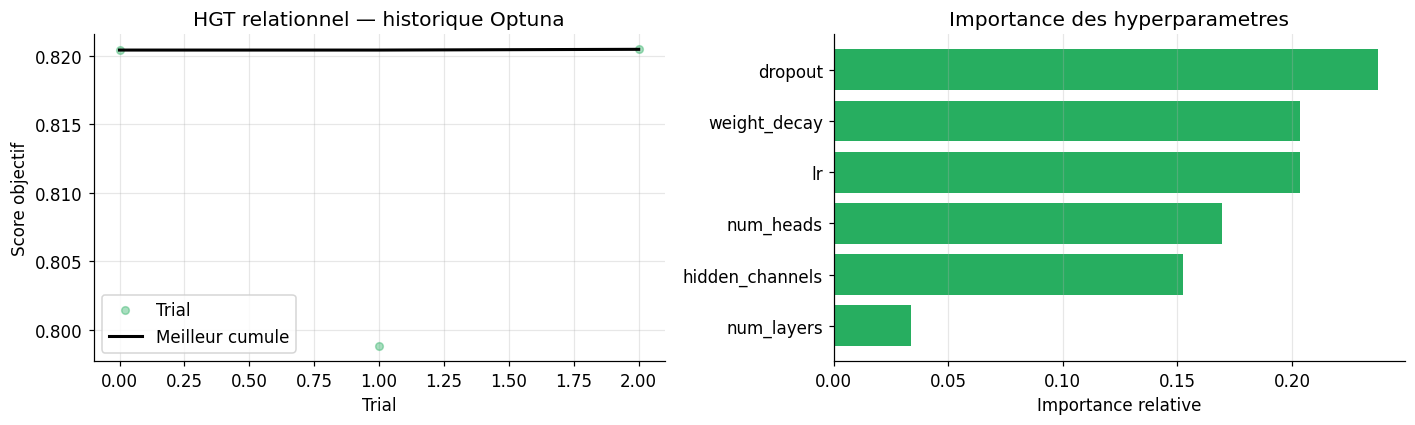

In [30]:
if TORCH_GEOMETRIC_AVAILABLE:
    def objective_hgt(trial):
        m = HGT_Classifier(metadata,
            hidden_channels=trial.suggest_categorical("hidden_channels", [32, 64, 128]),
            num_heads=trial.suggest_categorical("num_heads", [2, 4]),
            num_layers=trial.suggest_int("num_layers", 1, 3),
            dropout=trial.suggest_float("dropout", 0.1, 0.5)).to(device)
        _, h = train_hgt(m, train_data, val_data, epochs=max(40, EPOCHS_HGT//2),
                         lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
                         weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
                         verbose=False)
        return max(h["val_f1"])
    study_hgt = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_hgt.enqueue_trial({"hidden_channels": 64, "num_heads": 4, "num_layers": 2,
                             "dropout": 0.3, "lr": 3e-3, "weight_decay": 1e-5})
    study_hgt.optimize(objective_hgt, n_trials=_TRIALS["hgt"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    bp = study_hgt.best_params
    print("Meilleurs params HGT :", bp)
    optuna_history_fig(study_hgt, "HGT relationnel", "fig13_optuna_hgt.png", color="#27ae60")

### 10.5 — Entrainement final + courbe d'apprentissage

  epoch   1/300 | loss 0.7163 | val_acc 0.5769 | val_f1 0.4240
  epoch  10/300 | loss 0.6474 | val_acc 0.6559 | val_f1 0.6693
  epoch  20/300 | loss 0.6254 | val_acc 0.6799 | val_f1 0.6916
  epoch  30/300 | loss 0.5987 | val_acc 0.7046 | val_f1 0.7106
  epoch  40/300 | loss 0.5736 | val_acc 0.7232 | val_f1 0.7270
  epoch  50/300 | loss 0.5464 | val_acc 0.7470 | val_f1 0.7502
  epoch  60/300 | loss 0.5207 | val_acc 0.7653 | val_f1 0.7624
  epoch  70/300 | loss 0.4955 | val_acc 0.7742 | val_f1 0.7710
  epoch  80/300 | loss 0.4727 | val_acc 0.7810 | val_f1 0.7745
  epoch  90/300 | loss 0.4480 | val_acc 0.7830 | val_f1 0.7706
  epoch 100/300 | loss 0.4332 | val_acc 0.7909 | val_f1 0.7752
  epoch 110/300 | loss 0.4174 | val_acc 0.7982 | val_f1 0.7831
  epoch 120/300 | loss 0.4036 | val_acc 0.8051 | val_f1 0.7896
  epoch 130/300 | loss 0.3890 | val_acc 0.8129 | val_f1 0.7975
  epoch 140/300 | loss 0.3759 | val_acc 0.8184 | val_f1 0.8027
  epoch 150/300 | loss 0.3638 | val_acc 0.8212 | val_f1

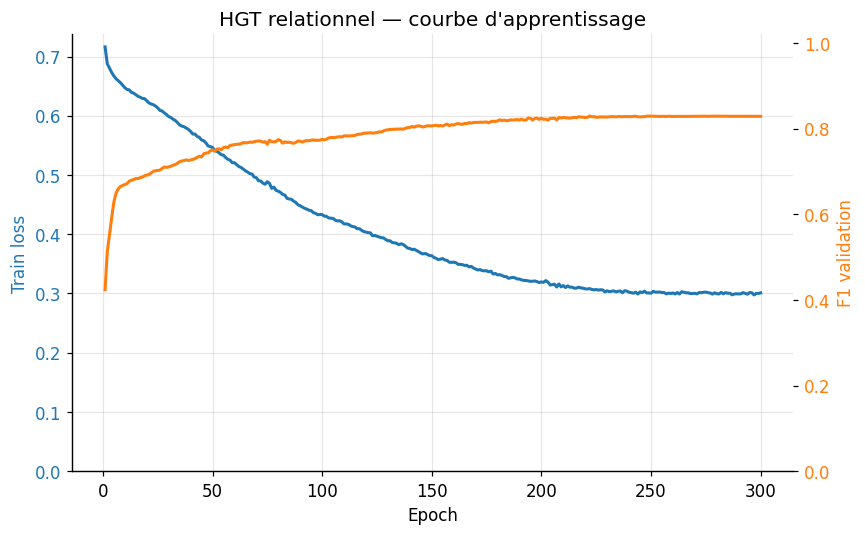

In [31]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model = HGT_Classifier(metadata, hidden_channels=bp["hidden_channels"],
        num_heads=bp["num_heads"], num_layers=bp["num_layers"], dropout=bp["dropout"]).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(train_data); _ = hgt_model(_xd, _ed)
    hgt_model, hgt_hist = train_hgt(hgt_model, train_data, val_data, epochs=EPOCHS_HGT,
        lr=bp["lr"], weight_decay=bp["weight_decay"], verbose=True)

    ep = range(1, len(hgt_hist["train_loss"])+1)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(ep, hgt_hist["train_loss"], color="tab:blue", lw=2, label="Train loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue"); ax1.grid(alpha=.3); ax1.set_ylim(bottom=0)
    ax2 = ax1.twinx(); ax2.plot(ep, hgt_hist["val_f1"], color="tab:orange", lw=2, label="Val F1")
    ax2.set_ylabel("F1 validation", color="tab:orange"); ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.set_ylim(0, 1.02); ax1.set_title("HGT relationnel — courbe d'apprentissage")
    plt.tight_layout(); savefig(fig, "fig14_hgt_learning_curve.png"); plt.show()

### 10.6 — Evaluation + matrice de confusion

────────────────────────────────────────────────────
  HGT relationnel
────────────────────────────────────────────────────
  roc_auc             : 0.9060
  avg_precision       : 0.8857
  recall              : 0.8284
  precision           : 0.8226
  f1                  : 0.8255
  balanced_accuracy   : 0.8392
  accuracy            : 0.8401


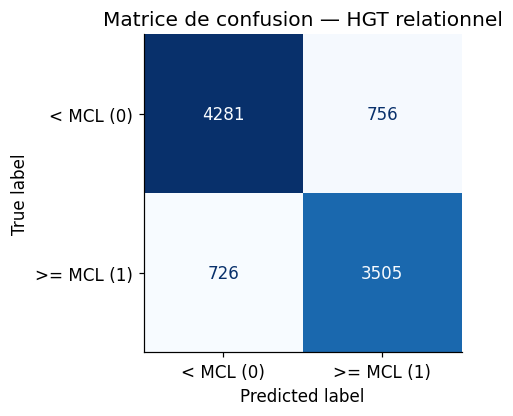

In [32]:
def hgt_predict(model, data):
    model.eval()
    with torch.no_grad():
        xd, ed = graph_tensors(data)
        return F.softmax(model(xd, ed), dim=1).cpu().numpy()

if TORCH_GEOMETRIC_AVAILABLE:
    hgt_out = hgt_predict(hgt_model, test_data)
    y_pred_hgt = hgt_out.argmax(1); y_proba_hgt = hgt_out[:, 1]
    m_hgt = evaluate("HGT relationnel", y_test, y_pred_hgt, y_proba_hgt)
    plot_confusion("HGT relationnel", y_test, y_pred_hgt, "fig15_hgt_confusion.png")

### 10.7 — Explicabilite du HGT (globale + LOCALE)

Sur un graphe, on utilise **shap.GradientExplainer** (expected gradients), variante SHAP pour
modeles differentiables, appliquee aux features du noeud `sample` (graphe fixe). On fournit
l'importance **globale** (sur un echantillon test) et l'attribution **locale** d'un puits
**positif** et d'un puits **negatif**. Les noeuds-hubs (`source`, `subbasin`, `geo_cluster`)
sont fixes : la sortie devient une fonction differentiable des seules features `sample`.

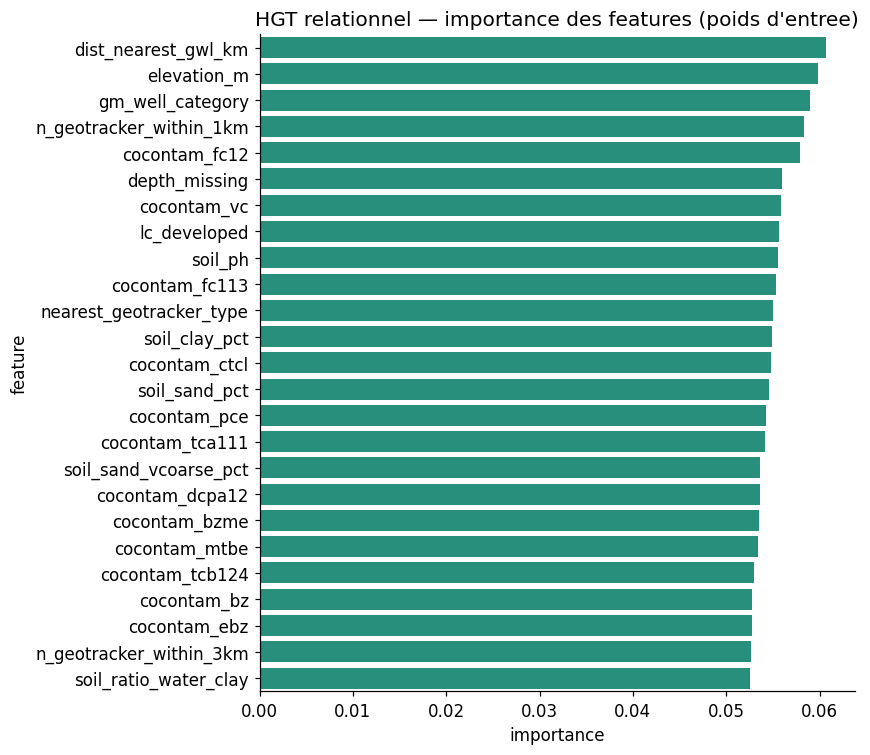

In [33]:
if TORCH_GEOMETRIC_AVAILABLE:
    # importance globale par norme des poids d'entree (lecture macro rapide)
    with torch.no_grad():
        w = hgt_model.lin_dict["sample"].weight.detach().cpu().numpy()
    hgt_imp = pd.DataFrame({"feature": proc_cols, "importance": np.abs(w).mean(0)}).sort_values("importance", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.barplot(data=hgt_imp.head(25), x="importance", y="feature", color="#16a085", ax=ax)
    ax.set_title("HGT relationnel — importance des features (poids d'entree)")
    plt.tight_layout(); savefig(fig, "fig16_hgt_importance.png"); plt.show()

In [34]:
if TORCH_GEOMETRIC_AVAILABLE and RUN_SHAP_HGT:
    import shap
    _edge_test = {et: test_data[et].edge_index.to(device) for et in test_data.edge_types}
    _fixed = {nt: test_data[nt].x.to(device) for nt in test_data.node_types if nt != "sample"}

    class HGTGrad(nn.Module):
        # Fonction differentiable sample_x -> logits ; hubs et aretes fixes.
        def __init__(self, model):
            super().__init__(); self.m = model
        def forward(self, sx):
            xd = {"sample": sx, **_fixed}
            xd = {nt: self.m.lin_dict[nt](x).relu() for nt, x in xd.items()}
            for conv in self.m.convs:
                xd = conv(xd, _edge_test)
            return self.m.classifier(xd["sample"])

    try:
        wrap = HGTGrad(hgt_model).to(device).eval()
        Xte_t = test_data["sample"].x.to(device)
        n_bg = min(100, len(Xte_t))
        bg = Xte_t[np.random.RandomState(RANDOM_STATE).choice(len(Xte_t), n_bg, replace=False)]
        explainer = shap.GradientExplainer(wrap, bg)
        # --- global ---
        ex_idx = np.random.RandomState(1).choice(len(Xte_t), min(300, len(Xte_t)), replace=False)
        sv = explainer.shap_values(Xte_t[ex_idx]); sv1 = sv[1] if isinstance(sv, list) else sv
        sv1 = sv1[..., 1] if sv1.ndim == 3 else sv1
        plt.figure()
        shap.summary_plot(sv1, Xte_t[ex_idx].cpu().numpy(), feature_names=proc_cols,
                          plot_type="bar", max_display=25, show=False)
        plt.title("SHAP global (GradientExplainer) — HGT relationnel"); plt.tight_layout()
        savefig(plt.gcf(), "fig17_shap_hgt.png"); plt.show()
        # --- LOCAL : 1 positif + 1 negatif ---
        for tag, idx in [("positif", IDX_POS), ("negatif", IDX_NEG)]:
            svl = explainer.shap_values(Xte_t[idx:idx+1]); svl = svl[1] if isinstance(svl, list) else svl
            svl = svl[..., 1] if svl.ndim == 3 else svl
            order = np.argsort(np.abs(svl[0]))[::-1][:15]
            plt.figure(figsize=(7, 5))
            plt.barh([proc_cols[k] for k in order][::-1], svl[0][order][::-1],
                     color=["#c0392b" if v > 0 else "#2980b9" for v in svl[0][order][::-1]])
            plt.axvline(0, color="k", lw=.8); plt.xlabel("Contribution SHAP (classe positive)")
            plt.title(f"SHAP local ({tag}) — HGT relationnel"); plt.tight_layout()
            savefig(plt.gcf(), f"fig17b_shap_local_hgt_{tag}.png"); plt.show()
    except Exception as e:
        print("GradientExplainer indisponible :", e)

GradientExplainer indisponible : Found indices in 'edge_index' that are larger than 1072 (got 10240). Please ensure that all indices in 'edge_index' point to valid indices in the interval [0, 1073) in your node feature matrix and try again.


## 11. Modele 4 — Embedding Fusion (HGT -> XGBoost)

Strategie hybride : 1) extraire les **embeddings** appris par le HGT (representation du
noeud `sample` apres message-passing), 2) les reduire par **PCA (95 % de variance)**,
3) les **concatener** aux features tabulaires, 4) entrainer un **XGBoost** (optimise Optuna)
sur cette representation enrichie. L'idee : injecter le signal **relationnel** du graphe
dans le meilleur modele tabulaire.

### 11.1 — Extraction des embeddings + PCA + fusion

In [35]:
if TORCH_GEOMETRIC_AVAILABLE:
    def hgt_embeddings(model, data):
        model.eval()
        with torch.no_grad():
            xd, ed = graph_tensors(data)
            return model(xd, ed, return_embeddings=True).cpu().numpy()

    emb_tr = hgt_embeddings(hgt_model, train_data)
    emb_va = hgt_embeddings(hgt_model, val_data)
    emb_te = hgt_embeddings(hgt_model, test_data)
    pca_fus = PCA(n_components=0.95, random_state=RANDOM_STATE)
    emb_tr_p = pca_fus.fit_transform(emb_tr)
    emb_va_p = pca_fus.transform(emb_va)
    emb_te_p = pca_fus.transform(emb_te)
    n_emb = emb_tr_p.shape[1]
    print(f"Embeddings HGT {emb_tr.shape[1]}D -> PCA {n_emb}D "
          f"(variance {pca_fus.explained_variance_ratio_.sum():.1%})")

    Xtr_fus = np.concatenate([X_train_proc, emb_tr_p], axis=1)
    Xva_fus = np.concatenate([X_val_proc,   emb_va_p], axis=1)
    Xte_fus = np.concatenate([X_test_proc,  emb_te_p], axis=1)
    fusion_names = proc_cols + [f"HGT_emb_{j}" for j in range(n_emb)]
    print(f"Matrice fusion : {Xtr_fus.shape} ({len(proc_cols)} features + {n_emb} embeddings)")

Embeddings HGT 128D -> PCA 2D (variance 97.0%)
Matrice fusion : (27802, 99) (97 features + 2 embeddings)


### 11.2 — Optimisation Optuna + entrainement

  0%|          | 0/20 [00:00<?, ?it/s]

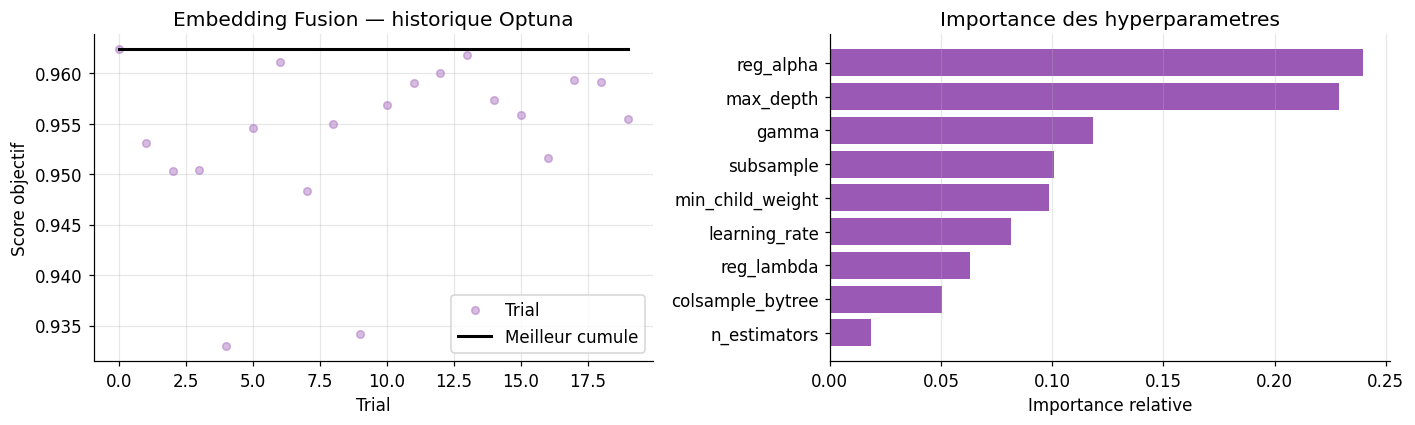

────────────────────────────────────────────────────
  Embedding Fusion
────────────────────────────────────────────────────
  roc_auc             : 0.9599
  avg_precision       : 0.9537
  recall              : 0.8873
  precision           : 0.8858
  f1                  : 0.8865
  balanced_accuracy   : 0.8956
  accuracy            : 0.8963


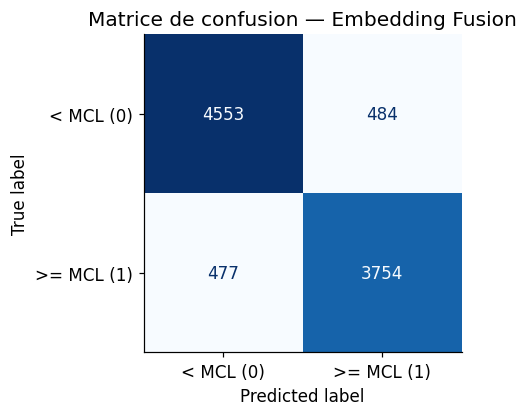

In [36]:
if TORCH_GEOMETRIC_AVAILABLE:
    def objective_fusion(trial):
        p = dict(n_estimators=trial.suggest_int("n_estimators", 150, 800),
                 max_depth=trial.suggest_int("max_depth", 3, 12),
                 learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                 subsample=trial.suggest_float("subsample", 0.5, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                 min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
                 gamma=trial.suggest_float("gamma", 0.0, 1.0),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                 reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 2.0, log=True),
                 scale_pos_weight=scale_pos, tree_method="hist",
                 random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
        c = xgb.XGBClassifier(**p, early_stopping_rounds=40)
        c.fit(Xtr_fus, y_train_bal, eval_set=[(Xva_fus, y_val)], verbose=False)
        return roc_auc_score(y_val, c.predict_proba(Xva_fus)[:, 1])

    study_fus = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_fus.optimize(objective_fusion, n_trials=_TRIALS["fusion"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    optuna_history_fig(study_fus, "Embedding Fusion", "fig18_optuna_fusion.png", color="#9b59b6")

    p_fus = {**study_fus.best_params, "scale_pos_weight": scale_pos, "tree_method": "hist",
             "random_state": RANDOM_STATE, "eval_metric": "auc", "verbosity": 0}
    xgb_fusion = xgb.XGBClassifier(**p_fus, early_stopping_rounds=50)
    xgb_fusion.fit(Xtr_fus, y_train_bal, eval_set=[(Xva_fus, y_val)], verbose=False)
    y_pred_fus  = xgb_fusion.predict(Xte_fus)
    y_proba_fus = xgb_fusion.predict_proba(Xte_fus)[:, 1]
    m_fus = evaluate("Embedding Fusion", y_test, y_pred_fus, y_proba_fus)
    plot_confusion("Embedding Fusion", y_test, y_pred_fus, "fig19_fusion_confusion.png")

### 11.3 — SHAP : contribution des features tabulaires vs embeddings HGT

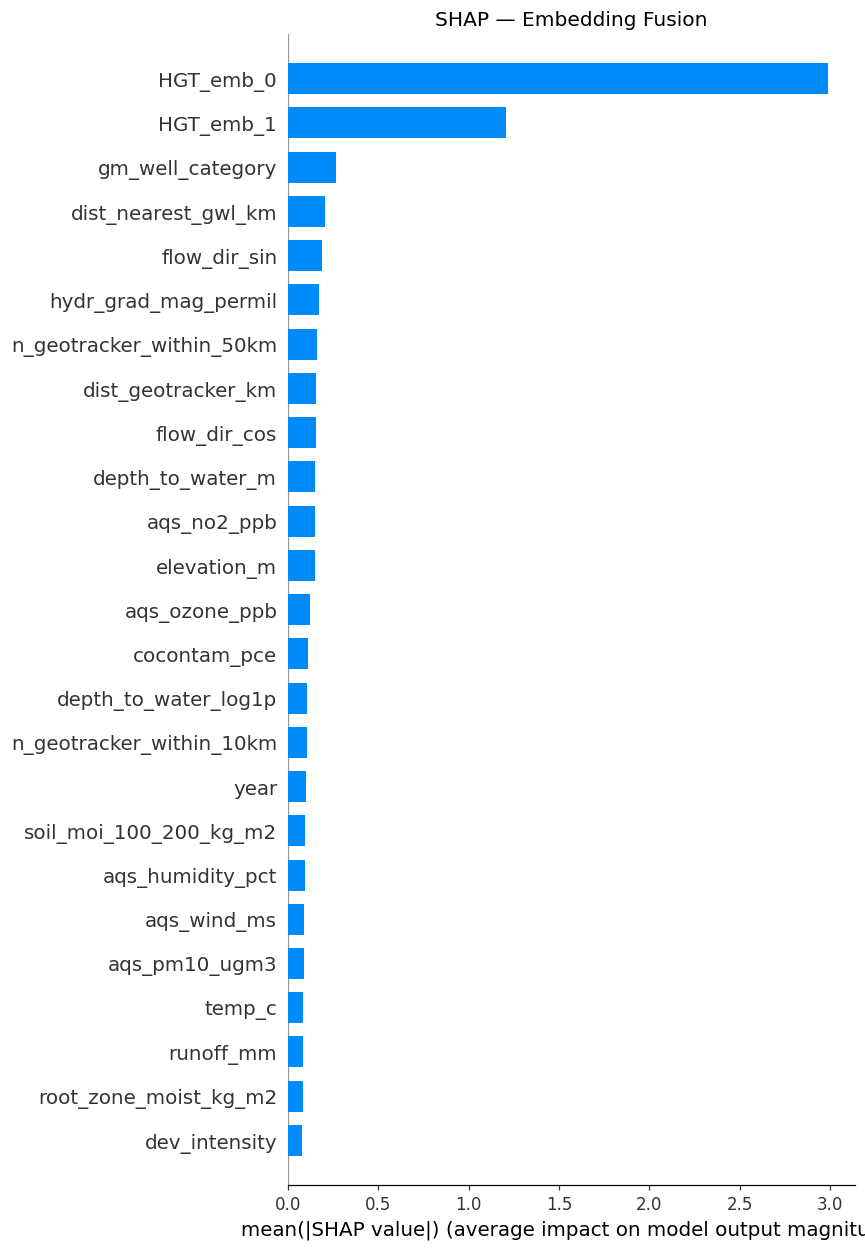

Contribution SHAP — features tabulaires : 56.7% | embeddings HGT : 43.3%


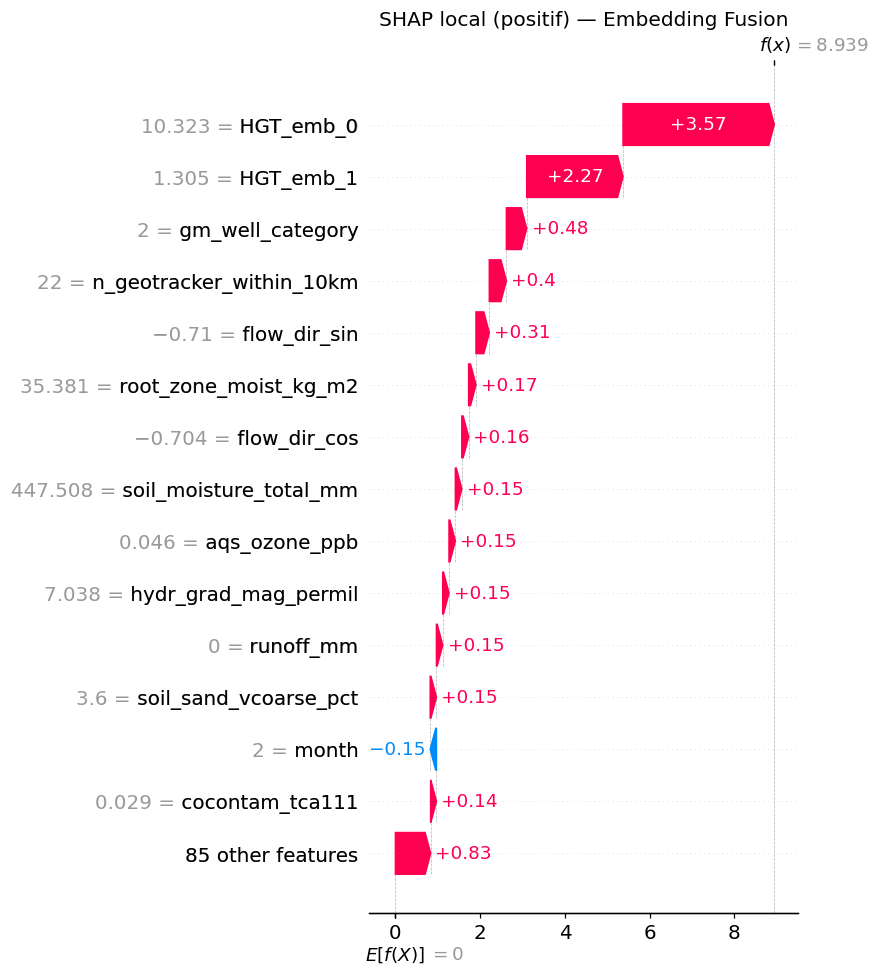

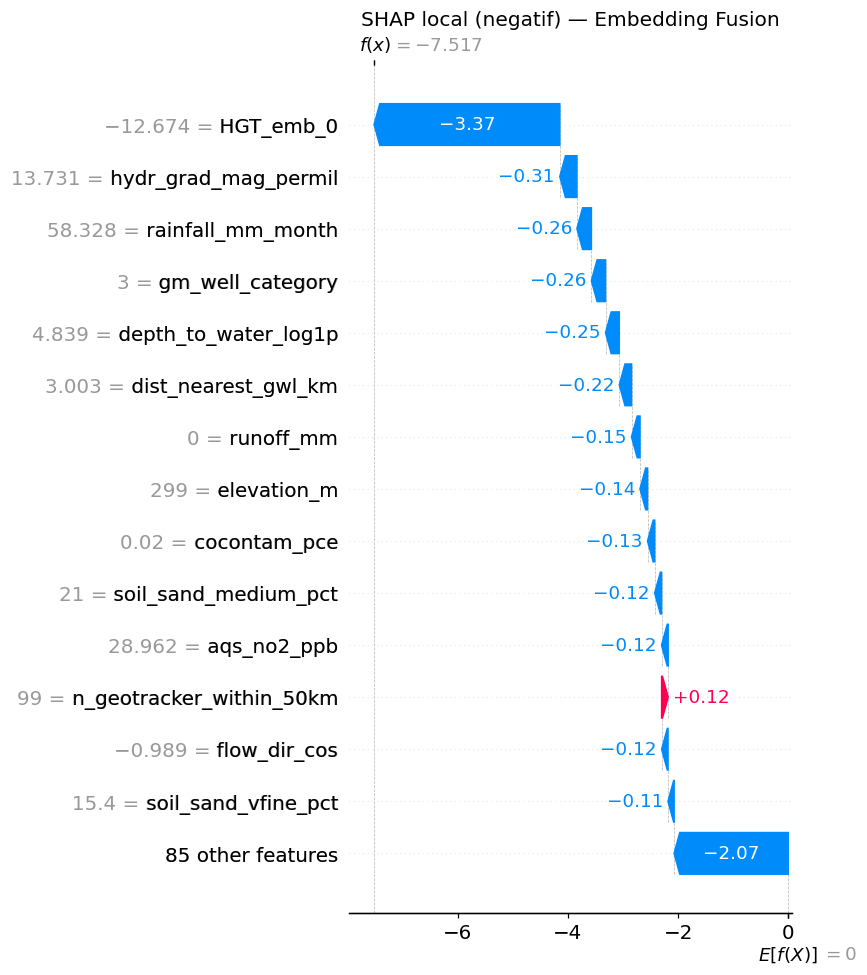

In [37]:
if TORCH_GEOMETRIC_AVAILABLE and RUN_SHAP:
    import shap
    expl = shap.TreeExplainer(xgb_fusion)
    sv_fus = expl.shap_values(Xte_fus[_shap_idx])
    if isinstance(sv_fus, list):
        sv_fus = sv_fus[1]
    if getattr(sv_fus, "ndim", 2) == 3:
        sv_fus = sv_fus[..., 1]
    fig = plt.figure()
    shap.summary_plot(sv_fus, Xte_fus[_shap_idx], feature_names=fusion_names,
                      plot_type="bar", max_display=25, show=False)
    plt.title("SHAP — Embedding Fusion"); plt.tight_layout()
    savefig(plt.gcf(), "fig20_shap_fusion.png"); plt.show()

    imp = np.abs(sv_fus).mean(0)
    n0 = len(proc_cols)
    orig, embc = imp[:n0].sum(), imp[n0:].sum()
    print(f"Contribution SHAP — features tabulaires : {100*orig/(orig+embc):.1f}% | "
          f"embeddings HGT : {100*embc/(orig+embc):.1f}%")
    # interpretabilite LOCALE (1 positif + 1 negatif)
    shap_local_tree(xgb_fusion, Xte_fus, fusion_names, "Embedding Fusion",
                    "fig20b_shap_local_fusion", IDX_POS, IDX_NEG)

## 12. Modele 5 — Stacking Ensemble (HGT + XGBoost + RandomForest)

Meta-apprentissage : on combine les predictions des **trois modeles de base** (HGT,
XGBoost, RandomForest) en **meta-features enrichies** (probabilites, entropies, confiances,
accords inter-modeles, produits/differences) auxquelles on ajoute les **embeddings HGT (PCA
90 %)**. Un **meta-classifieur XGBoost** (optimise Optuna) apprend a arbitrer entre les
modeles selon le contexte.

### 12.1 — Probabilites des modeles de base + meta-features

In [38]:
if TORCH_GEOMETRIC_AVAILABLE:
    # probas des 3 modeles de base (train/val/test) — 2 colonnes (classe 0 et 1)
    hgt_p_tr, hgt_p_va, hgt_p_te = (hgt_predict(hgt_model, d) for d in (train_data, val_data, test_data))
    xgb_p_tr = xgb_model.predict_proba(X_train_proc); xgb_p_va = xgb_model.predict_proba(X_val_proc); xgb_p_te = xgb_model.predict_proba(X_test_proc)
    rf_p_tr  = rf.predict_proba(X_train_proc);        rf_p_va  = rf.predict_proba(X_val_proc);        rf_p_te  = rf.predict_proba(X_test_proc)

    pca_meta = PCA(n_components=0.90, random_state=RANDOM_STATE)
    em_tr = pca_meta.fit_transform(emb_tr); em_va = pca_meta.transform(emb_va); em_te = pca_meta.transform(emb_te)
    n_em = em_tr.shape[1]

    def meta_features(hp, xp, rp, emb):
        eps = 1e-10
        h1, x1, r1 = hp[:, 1:2], xp[:, 1:2], rp[:, 1:2]
        def ent(p): return (-p * np.log(p + eps)).sum(1, keepdims=True)
        agree = lambda a, b: (a.argmax(1) == b.argmax(1)).astype(np.float32).reshape(-1, 1)
        parts = [h1, x1, r1, ent(hp), ent(xp), ent(rp),
                 hp.max(1, keepdims=True), xp.max(1, keepdims=True), rp.max(1, keepdims=True),
                 agree(hp, xp), agree(hp, rp), agree(xp, rp),
                 np.abs(h1 - x1), np.abs(h1 - r1), np.abs(x1 - r1),
                 h1 * x1, x1 * r1, (h1 + x1 + r1) / 3.0, emb]
        return np.hstack(parts)

    META_BASE = ["hgt_p1","xgb_p1","rf_p1","hgt_ent","xgb_ent","rf_ent",
                 "hgt_conf","xgb_conf","rf_conf","agree_hx","agree_hr","agree_xr",
                 "diff_hx","diff_hr","diff_xr","prod_hx","prod_xr","mean_hxr"]
    meta_tr = meta_features(hgt_p_tr, xgb_p_tr, rf_p_tr, em_tr)
    meta_va = meta_features(hgt_p_va, xgb_p_va, rf_p_va, em_va)
    meta_te = meta_features(hgt_p_te, xgb_p_te, rf_p_te, em_te)
    meta_names = META_BASE + [f"emb_pca_{k}" for k in range(n_em)]
    print(f"Meta-features : {meta_tr.shape[1]} dims ({len(META_BASE)} derivees + {n_em} embeddings PCA)")

Meta-features : 19 dims (18 derivees + 1 embeddings PCA)


### 12.2 — Optimisation Optuna du meta-classifieur + entrainement

  0%|          | 0/20 [00:00<?, ?it/s]

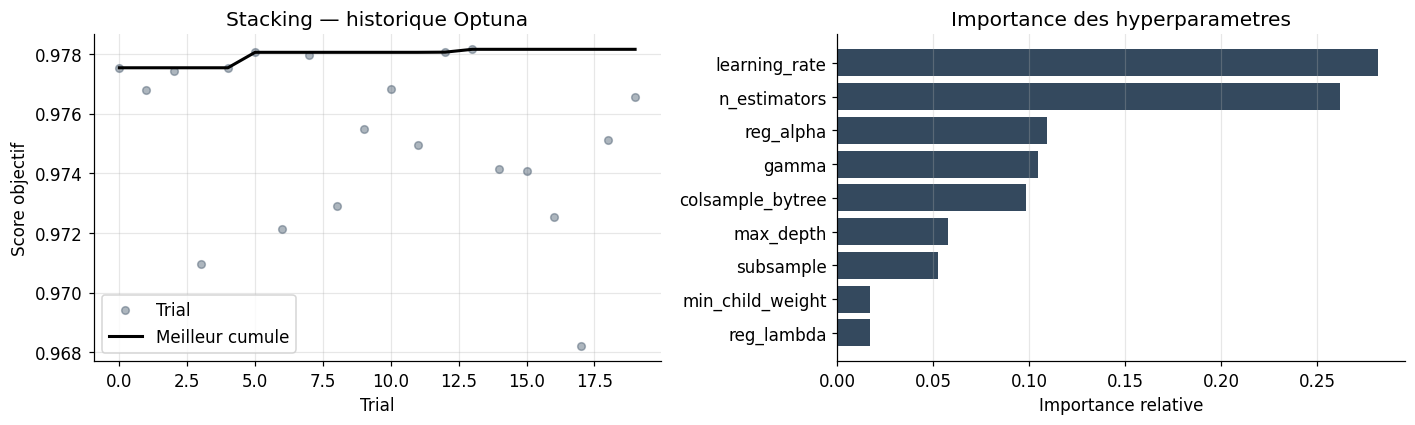

────────────────────────────────────────────────────
  Stacking
────────────────────────────────────────────────────
  roc_auc             : 0.9769
  avg_precision       : 0.9741
  recall              : 0.9263
  precision           : 0.9230
  f1                  : 0.9246
  balanced_accuracy   : 0.9307
  accuracy            : 0.9311


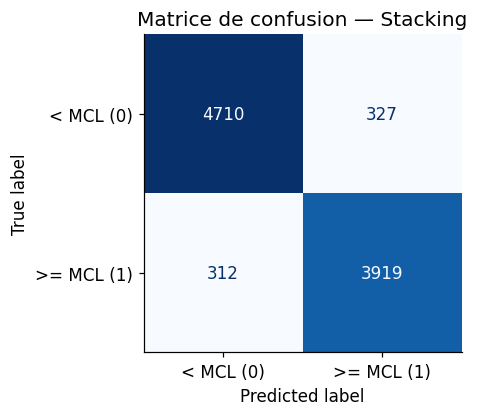

In [39]:
if TORCH_GEOMETRIC_AVAILABLE:
    def objective_stack(trial):
        p = dict(n_estimators=trial.suggest_int("n_estimators", 50, 400),
                 max_depth=trial.suggest_int("max_depth", 2, 7),
                 learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                 subsample=trial.suggest_float("subsample", 0.5, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                 min_child_weight=trial.suggest_int("min_child_weight", 1, 8),
                 gamma=trial.suggest_float("gamma", 0.0, 0.5),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 0.5, log=True),
                 reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
                 scale_pos_weight=scale_pos, tree_method="hist",
                 random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
        c = xgb.XGBClassifier(**p, early_stopping_rounds=30)
        c.fit(meta_tr, y_train_bal, eval_set=[(meta_va, y_val)], verbose=False)
        return roc_auc_score(y_val, c.predict_proba(meta_va)[:, 1])

    study_stk = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_stk.optimize(objective_stack, n_trials=_TRIALS["stacking"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    optuna_history_fig(study_stk, "Stacking", "fig21_optuna_stacking.png", color="#34495e")

    p_stk = {**study_stk.best_params, "scale_pos_weight": scale_pos, "tree_method": "hist",
             "random_state": RANDOM_STATE, "eval_metric": "auc", "verbosity": 0}
    meta_clf = xgb.XGBClassifier(**p_stk, early_stopping_rounds=40)
    meta_clf.fit(meta_tr, y_train_bal, eval_set=[(meta_va, y_val)], verbose=False)
    y_pred_stk  = meta_clf.predict(meta_te)
    y_proba_stk = meta_clf.predict_proba(meta_te)[:, 1]
    m_stk = evaluate("Stacking", y_test, y_pred_stk, y_proba_stk)
    plot_confusion("Stacking", y_test, y_pred_stk, "fig22_stacking_confusion.png")

### 12.3 — Importance des meta-features (globale) + SHAP local

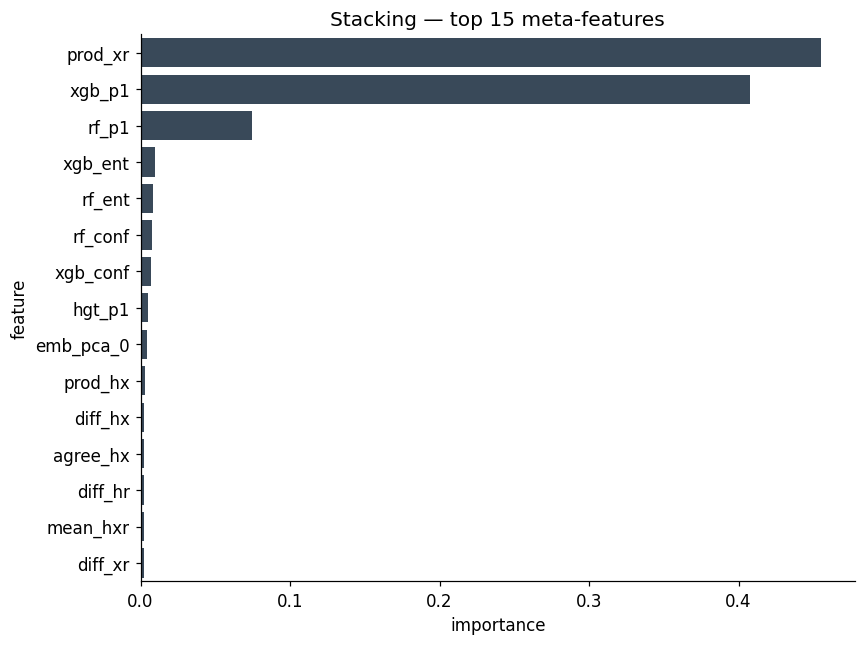

  feature  importance
  prod_xr    0.454897
   xgb_p1    0.407768
    rf_p1    0.074288
  xgb_ent    0.009883
   rf_ent    0.008269
  rf_conf    0.007474
 xgb_conf    0.006683
   hgt_p1    0.004825
emb_pca_0    0.004316
  prod_hx    0.003086


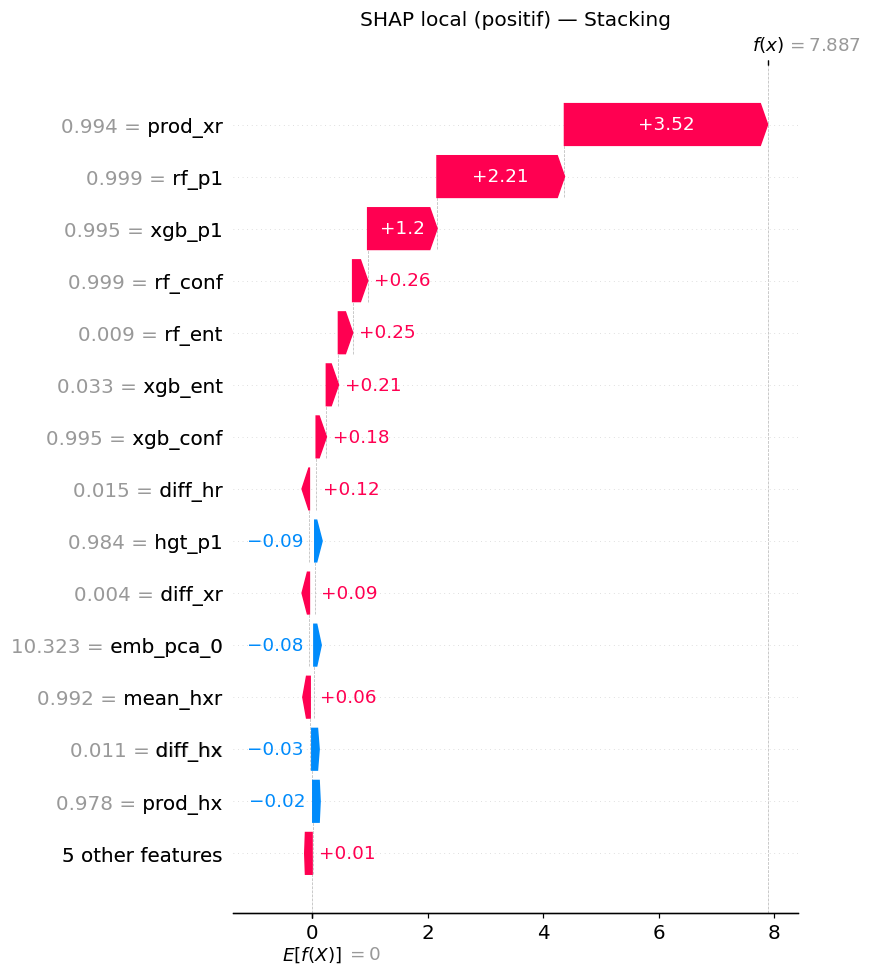

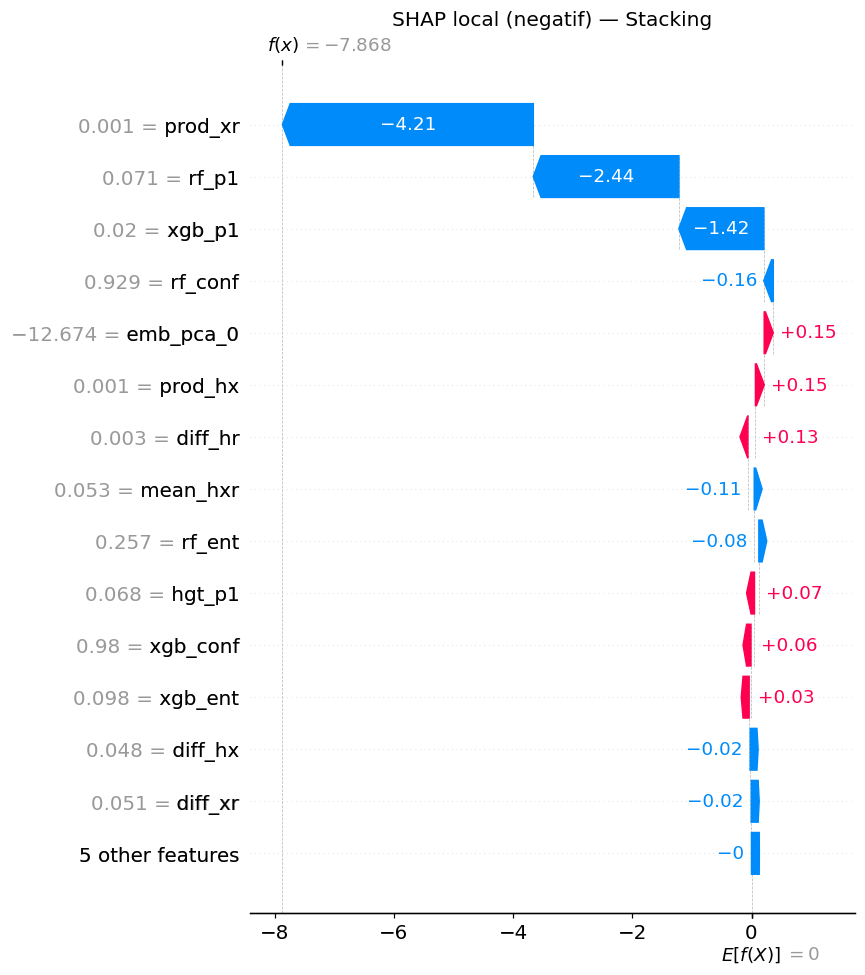

In [61]:
if TORCH_GEOMETRIC_AVAILABLE:
    imp = np.asarray(meta_clf.feature_importances_)
    mdf = pd.DataFrame({"feature": meta_names[:len(imp)], "importance": imp}).sort_values("importance", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=mdf.head(15), x="importance", y="feature", color="#34495e", ax=ax)
    ax.set_title("Stacking — top 15 meta-features")
    plt.tight_layout(); savefig(fig, "fig23_stacking_importance.png"); plt.show()
    print(mdf.head(10).to_string(index=False))
    # interpretabilite LOCALE du meta-classifieur (1 positif + 1 negatif)
    if RUN_SHAP:
        shap_local_tree(meta_clf, meta_te, meta_names, "Stacking",
                        "fig23b_shap_local_stacking", IDX_POS, IDX_NEG)

## 13. Comparaison des 5 modeles (test set)

Tableau recapitulatif, courbes ROC / Precision-Rappel, calibration, matrices de confusion
et tableau de bord. Tous les modeles sont evalues sur **le meme jeu de test**.

In [62]:
ORDER = ["HGT relationnel", "Random Forest", "XGBoost", "Embedding Fusion", "Stacking"]
ORDER = [m for m in ORDER if m in RESULTS]
COLORS = {"HGT relationnel": "#27ae60", "Random Forest": "#2980b9", "XGBoost": "#e74c3c",
          "Embedding Fusion": "#9b59b6", "Stacking": "#34495e"}

comp = pd.DataFrame([{
    "Modele": m,
    "ROC-AUC": RESULTS[m]["metrics"]["roc_auc"],
    "AP": RESULTS[m]["metrics"]["avg_precision"],
    "Rappel": RESULTS[m]["metrics"]["recall"],
    "Precision": RESULTS[m]["metrics"]["precision"],
    "F1": RESULTS[m]["metrics"]["f1"],
    "Bal.Acc": RESULTS[m]["metrics"]["balanced_accuracy"],
    "Accuracy": RESULTS[m]["metrics"]["accuracy"],
} for m in ORDER]).set_index("Modele")
comp.to_csv(RES_DIR / "comparaison_modeles.csv")
print(comp.round(4).to_string())
best = comp["F1"].idxmax()
print(f"\nMeilleur modele (F1) : {best}  (F1={comp.loc[best,'F1']:.4f}, "
      f"AUC={comp.loc[best,'ROC-AUC']:.4f})")
comp.round(4).style.background_gradient(cmap="RdYlGn")

                  ROC-AUC      AP  Rappel  Precision      F1  Bal.Acc  Accuracy
Modele                                                                         
HGT relationnel    0.9060  0.8857  0.8284     0.8226  0.8255   0.8392    0.8401
Random Forest      0.9786  0.9763  0.9199     0.9295  0.9247   0.9307    0.9316
XGBoost            0.9766  0.9739  0.9229     0.9223  0.9226   0.9288    0.9293
Embedding Fusion   0.9599  0.9537  0.8873     0.8858  0.8865   0.8956    0.8963
Stacking           0.9769  0.9741  0.9263     0.9230  0.9246   0.9307    0.9311

Meilleur modele (F1) : Random Forest  (F1=0.9247, AUC=0.9786)


,ROC-AUC,AP,Rappel,Precision,F1,Bal.Acc,Accuracy
Modele,,,,,,,
HGT relationnel,0.906000,0.885700,0.828400,0.822600,0.825500,0.839200,0.840100
Random Forest,0.978600,0.976300,0.919900,0.929500,0.924700,0.930700,0.931600
XGBoost,0.976600,0.973900,0.922900,0.922300,0.922600,0.928800,0.929300
Embedding Fusion,0.959900,0.953700,0.887300,0.885800,0.886500,0.895600,0.896300
Stacking,0.976900,0.974100,0.926300,0.923000,0.924600,0.930700,0.931100


### 13.1 — Courbes ROC et Precision-Rappel

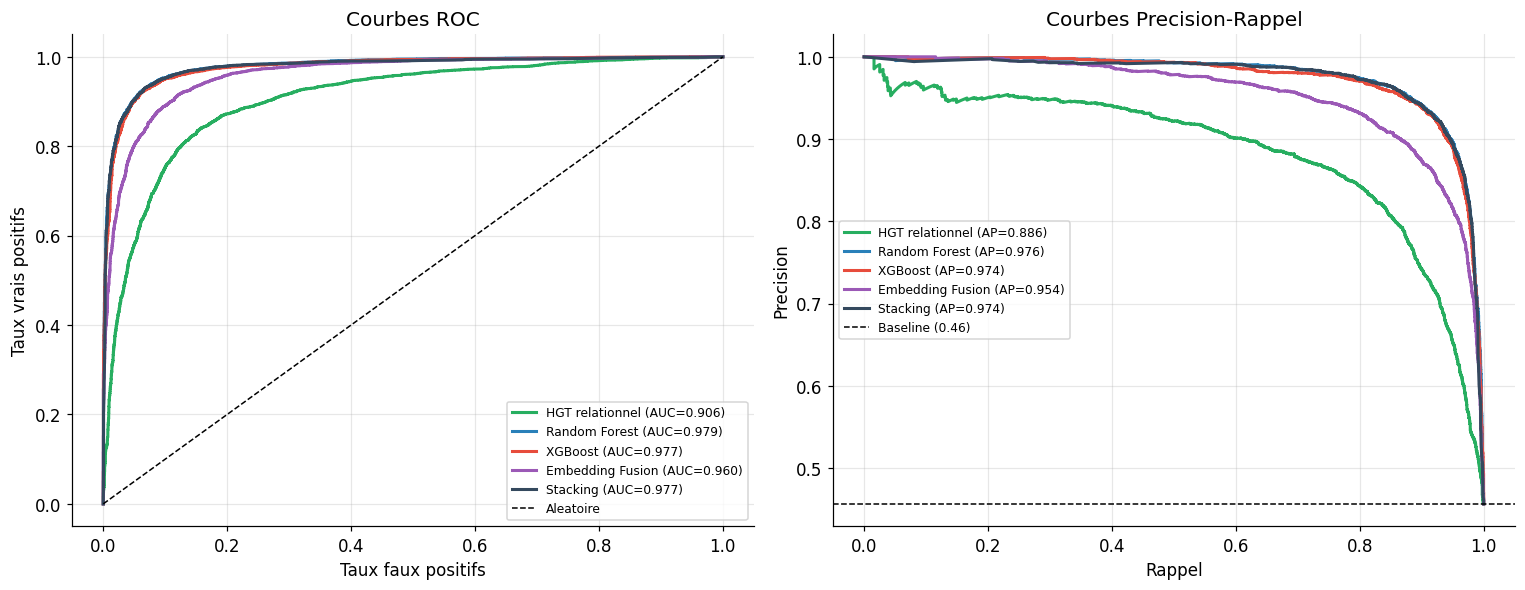

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
prev = y_test.mean()
for m in ORDER:
    pr = RESULTS[m]["y_proba"]; c = COLORS[m]
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax1.plot(fpr, tpr, lw=2, color=c, label=f"{m} (AUC={RESULTS[m]['metrics']['roc_auc']:.3f})")
    p, r, _ = precision_recall_curve(y_test, pr)
    ax2.plot(r, p, lw=2, color=c, label=f"{m} (AP={RESULTS[m]['metrics']['avg_precision']:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatoire")
ax2.axhline(prev, color="k", ls="--", lw=1, label=f"Baseline ({prev:.2f})")
ax1.set(xlabel="Taux faux positifs", ylabel="Taux vrais positifs", title="Courbes ROC")
ax2.set(xlabel="Rappel", ylabel="Precision", title="Courbes Precision-Rappel")
ax1.legend(fontsize=8); ax2.legend(fontsize=8); ax1.grid(alpha=.3); ax2.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig24_roc_pr_all.png"); plt.show()

### 13.2 — Courbe de calibration (fiabilite des probabilites)

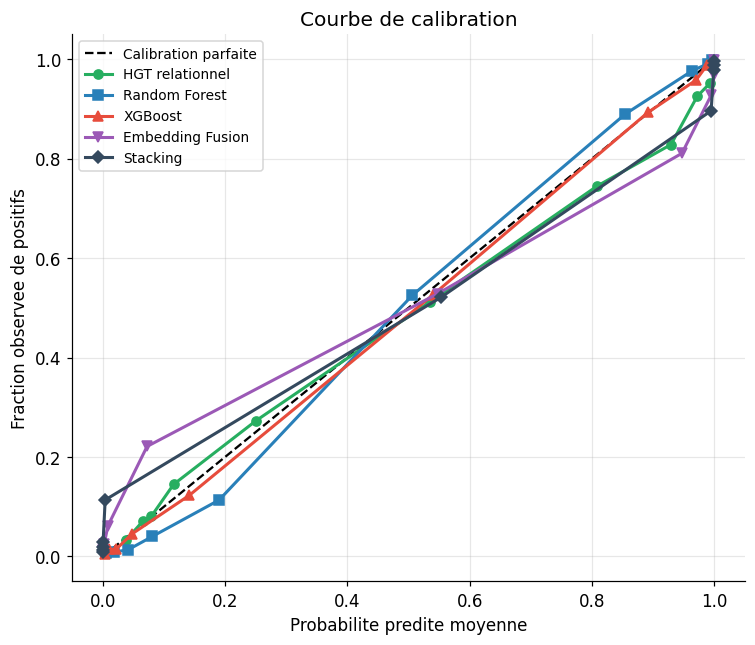

In [64]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibration parfaite")
for m, mk in zip(ORDER, ["o-", "s-", "^-", "v-", "D-"]):
    fr, mp = calibration_curve(y_test, RESULTS[m]["y_proba"], n_bins=10, strategy="quantile")
    ax.plot(mp, fr, mk, color=COLORS[m], lw=2, label=m)
ax.set(xlabel="Probabilite predite moyenne", ylabel="Fraction observee de positifs",
       title="Courbe de calibration")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig25_calibration_all.png"); plt.show()

### 13.3 — Matrices de confusion (vue d'ensemble)

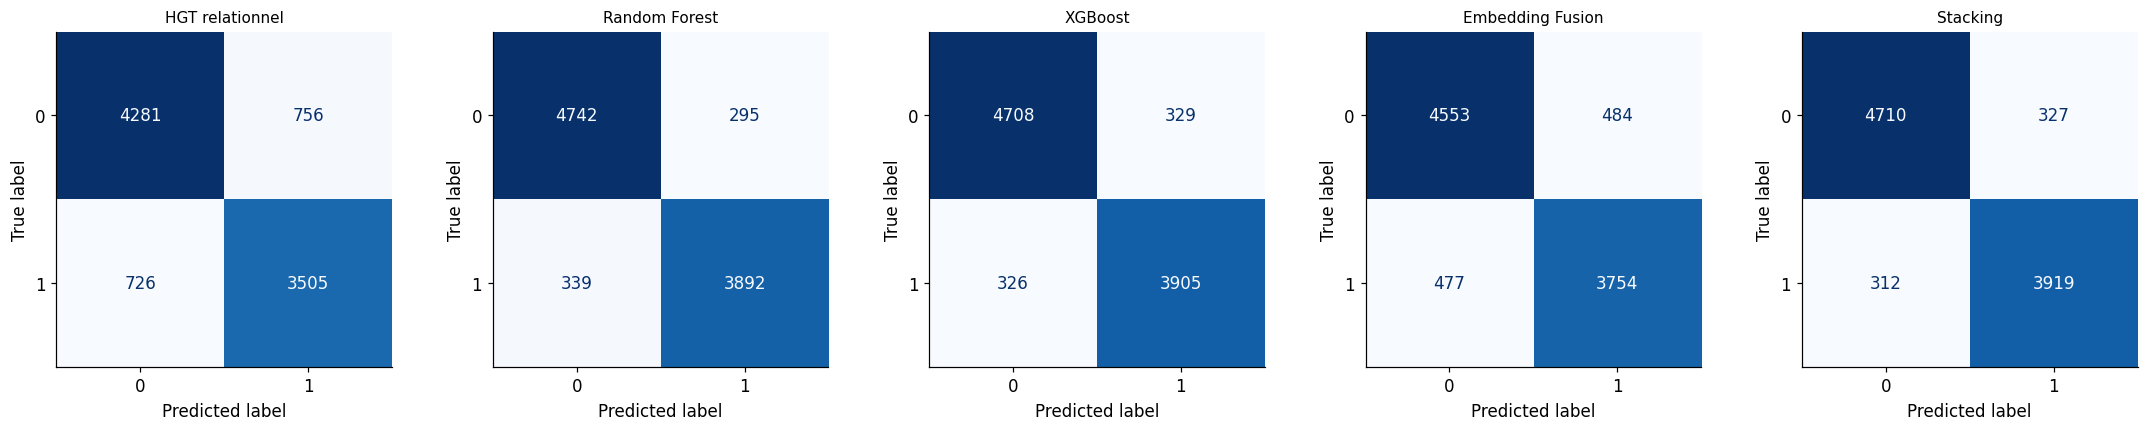

In [65]:
n = len(ORDER)
fig, axes = plt.subplots(1, n, figsize=(4*n, 3.8))
if n == 1: axes = [axes]
for ax, m in zip(axes, ORDER):
    ConfusionMatrixDisplay.from_predictions(y_test, RESULTS[m]["y_pred"],
        display_labels=["0", "1"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(m, fontsize=10)
plt.tight_layout(); savefig(fig, "fig26_confusion_all.png"); plt.show()

### 13.4 — Tableau de bord comparatif

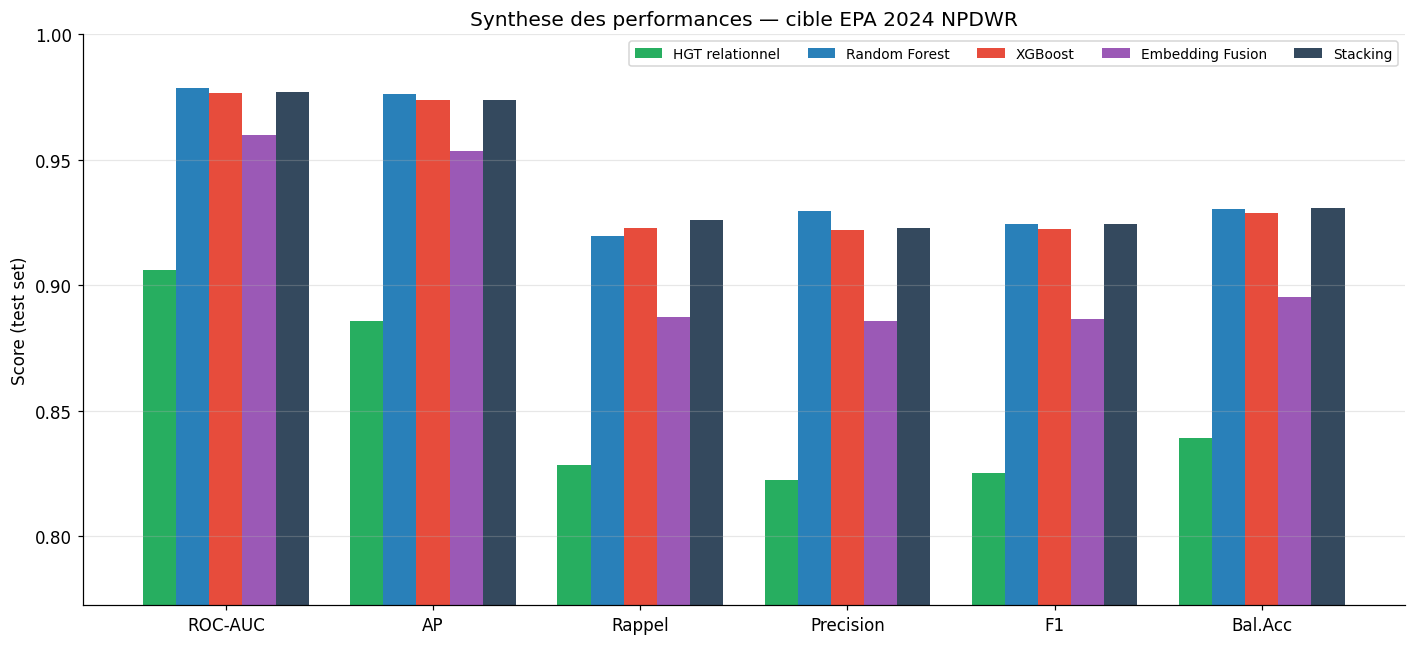

In [66]:
metrics = ["roc_auc", "avg_precision", "recall", "precision", "f1", "balanced_accuracy"]
labels = ["ROC-AUC", "AP", "Rappel", "Precision", "F1", "Bal.Acc"]
x = np.arange(len(labels)); w = 0.8 / len(ORDER)
fig, ax = plt.subplots(figsize=(13, 6))
for i, m in enumerate(ORDER):
    vals = [RESULTS[m]["metrics"][k] for k in metrics]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=m, color=COLORS[m])
allv = [RESULTS[m]["metrics"][k] for m in ORDER for k in metrics]
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(max(0, min(allv) - 0.05), 1.0)
ax.set_ylabel("Score (test set)"); ax.set_title("Synthese des performances — cible EPA 2024 NPDWR")
ax.legend(fontsize=9, ncol=len(ORDER)); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "fig27_dashboard.png"); plt.show()

### 13.5 — Carte spatiale des predictions (meilleur modele)

Bien que la localisation soit volontairement laissee en feature, cette carte illustre la
distribution geographique des erreurs (utile en soutenance).

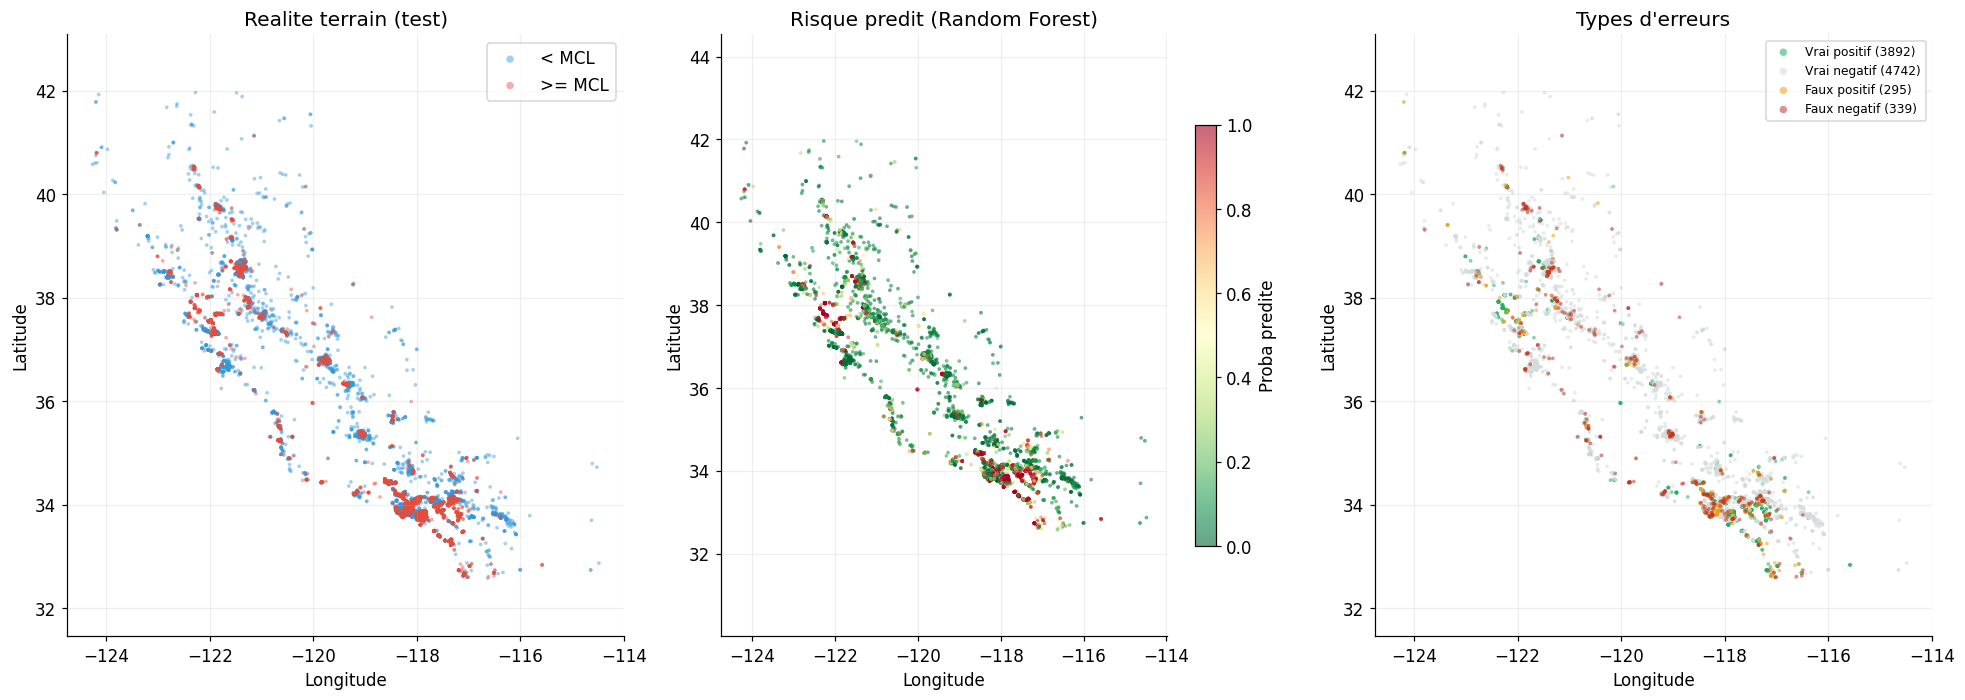

In [67]:
if {"latitude", "longitude"}.issubset(df.columns):
    test_pos = X_test.index
    coords = df.loc[test_pos, ["longitude", "latitude"]].copy()
    coords["y_true"] = y_test
    coords["proba"]  = RESULTS[best]["y_proba"]
    coords["y_pred"] = RESULTS[best]["y_pred"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
    for lab, c, mlab in [(0, "#3498db", "< MCL"), (1, "#e74c3c", ">= MCL")]:
        s = coords[coords.y_true == lab]
        axes[0].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.45, label=mlab, edgecolors="none")
    axes[0].set_title("Realite terrain (test)"); axes[0].legend(markerscale=2)
    sc = axes[1].scatter(coords.longitude, coords.latitude, s=6, c=coords.proba,
                         cmap="RdYlGn_r", vmin=0, vmax=1, alpha=.6, edgecolors="none")
    plt.colorbar(sc, ax=axes[1], shrink=.7, label="Proba predite")
    axes[1].set_title(f"Risque predit ({best})")
    conds = [(coords.y_true==1)&(coords.y_pred==1), (coords.y_true==0)&(coords.y_pred==0),
             (coords.y_true==0)&(coords.y_pred==1), (coords.y_true==1)&(coords.y_pred==0)]
    labs = ["Vrai positif", "Vrai negatif", "Faux positif", "Faux negatif"]
    coords["err"] = np.select(conds, labs, default="?")
    pal = {"Vrai positif":"#27ae60","Vrai negatif":"#d5dbdb","Faux positif":"#f39c12","Faux negatif":"#c0392b"}
    for cat, c in pal.items():
        s = coords[coords.err == cat]
        axes[2].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.55, label=f"{cat} ({len(s)})", edgecolors="none")
    axes[2].set_title("Types d'erreurs"); axes[2].legend(markerscale=2, fontsize=8)
    for ax in axes:
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_aspect("equal", "datalim"); ax.grid(alpha=.2)
    plt.tight_layout(); savefig(fig, "fig28_map_predictions.png"); plt.show()

## 14. Evaluation honnete — Validation croisee spatiale par blocs (k=8)

> **Section activable** : `RUN_SPATIAL_CV = True` dans la configuration.

Le split aleatoire 60/20/20 **surestime** la generalisation : des echantillons proches
(meme puits, meme panache) se retrouvent a la fois en train et en test. On evalue donc la
**vraie capacite hors-zone** avec une **CV spatiale par blocs** : KMeans sur (lat, lon) ->
`k=8` regions ; chaque region est tour a tour le *test*, le reste l'*entrainement*. Les
features etant **deja sans localisation**, ce protocole mesure directement la capacite a
**generaliser hors-zone** (sans memorisation geographique possible via les features). C'est
la metrique de reference pour juger si un modele PFAS est reellement predictif.

In [68]:
if RUN_SPATIAL_CV and {"latitude", "longitude"}.issubset(df.columns):
    from sklearn.model_selection import StratifiedKFold as _SKF
    yall = df["target"].values
    blocks = KMeans(SPATIAL_CV_K, random_state=RANDOM_STATE, n_init=10).fit_predict(
        StandardScaler().fit_transform(df[["latitude", "longitude"]].values))
    print("Tailles des blocs spatiaux :", np.bincount(blocks))
    ARMS = {"sans_localisation": feature_names}   # les features sont deja sans lat/lon/regions

    def _proc(cols, tr, te):
        nc = [c for c in cols if c in num_cols]; cc = [c for c in cols if c in cat_cols]
        ct = ColumnTransformer([
            ("num", Pipeline([("im", SimpleImputer(strategy="median"))]), nc),
            ("cat", Pipeline([("im", SimpleImputer(strategy="constant", fill_value="Unknown")),
                              ("en", OrdinalEncoder(handle_unknown="use_encoded_value",
                                     unknown_value=-1, encoded_missing_value=-1))]), cc)])
        return ct.fit_transform(df.loc[tr, cols]), ct.transform(df.loc[te, cols])

    rows = []
    for arm, cols in ARMS.items():
        for f in range(SPATIAL_CV_K):
            te = blocks == f; tr = ~te
            if te.sum() < 50 or len(np.unique(yall[te])) < 2:
                continue
            Xtr, Xte = _proc(cols, tr, te)
            ytr, yte = yall[tr], yall[te]
            spw = (ytr == 0).sum() / max(1, (ytr == 1).sum())
            for name, mdl in [
                ("XGBoost", xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                    tree_method="hist", random_state=RANDOM_STATE, eval_metric="logloss")),
                ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                    n_jobs=-1, random_state=RANDOM_STATE))]:
                mdl.fit(Xtr, ytr); p = mdl.predict_proba(Xte)[:, 1]
                rows.append(dict(model=name, arm=arm, fold=f, n_test=int(te.sum()),
                                 prev=float(yte.mean()), AUC=roc_auc_score(yte, p),
                                 AP=average_precision_score(yte, p)))
            print(f"  [{arm}] fold {f} ok (n_test={int(te.sum())}, prev={yte.mean():.2f})")
    cv_sp = pd.DataFrame(rows)
    cv_sp.to_csv(RES_DIR / "cv_spatiale.csv", index=False)
    summary = cv_sp.groupby(["model", "arm"]).agg(
        AUC_moy=("AUC", "mean"), AUC_std=("AUC", "std"), AP_moy=("AP", "mean")).round(4)
    print("\n===== CV SPATIALE (AUC honnete hors-zone) =====")
    print(summary.to_string())
else:
    print("CV spatiale desactivee (RUN_SPATIAL_CV=False).")

CV spatiale desactivee (RUN_SPATIAL_CV=False).


In [69]:
# Contraste CV aleatoire (optimiste) vs CV spatiale (honnete)
if RUN_SPATIAL_CV and "cv_sp" in dir() and len(cv_sp):
    from sklearn.model_selection import StratifiedKFold as _SKF
    Xall = df[feature_names]; yall = df["target"].values
    rnd = []
    for tri, tei in _SKF(5, shuffle=True, random_state=RANDOM_STATE).split(Xall, yall):
        ct = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([("im", SimpleImputer(strategy="constant", fill_value="Unknown")),
                              ("en", OrdinalEncoder(handle_unknown="use_encoded_value",
                                     unknown_value=-1, encoded_missing_value=-1))]), cat_cols)])
        Xt = ct.fit_transform(Xall.iloc[tri]); Xv = ct.transform(Xall.iloc[tei])
        m = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
            colsample_bytree=0.8, tree_method="hist", random_state=RANDOM_STATE,
            eval_metric="logloss").fit(Xt, yall[tri])
        rnd.append(roc_auc_score(yall[tei], m.predict_proba(Xv)[:, 1]))
    auc_rand = float(np.mean(rnd))
    auc_spat = float(cv_sp[(cv_sp.model == "XGBoost") & (cv_sp.arm == "sans_localisation")].AUC.mean())
    print(f"AUC CV aleatoire (optimiste) : {auc_rand:.3f}")
    print(f"AUC CV spatiale  (honnete)   : {auc_spat:.3f}")
    print(f"Penalite spatiale Delta      : {auc_rand - auc_spat:.3f}")

    g = cv_sp.groupby(["model", "arm"]).AUC.agg(["mean", "std"]).reset_index()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    labs = [f"{r.model}\n{r.arm}" for _, r in g.iterrows()]
    ax.bar(range(len(g)), g["mean"], yerr=g["std"], capsize=4,
           color=["#2980b9", "#3498db", "#e74c3c", "#c0392b"][:len(g)], edgecolor="black")
    ax.axhline(0.5, ls="--", c="grey", label="Aleatoire (0.5)")
    ax.axhline(auc_rand, ls=":", c="red", label=f"CV aleatoire ({auc_rand:.2f})")
    ax.set_xticks(range(len(g))); ax.set_xticklabels(labs, fontsize=8)
    ax.set_ylabel("ROC-AUC (CV spatiale)"); ax.set_ylim(0.4, 1.0); ax.legend(fontsize=8)
    ax.set_title("AUC honnete hors-zone vs optimisme du split aleatoire")
    plt.tight_layout(); savefig(fig, "fig29_cv_spatiale.png"); plt.show()

## 15. Importance des features & concordance des modeles

On compare les **classements de features** des modeles entraines sur la **meme matrice**
(`proc_cols`) : Random Forest (importance par impurete MDI), XGBoost (gain), et HGT
(norme L1 des poids d'entree). La **concordance** mesure a quel point les modeles s'accordent
sur les variables importantes — un fort accord renforce la **confiance** dans l'interpretation.

### 15.1 — Importance par modele (Top 25)

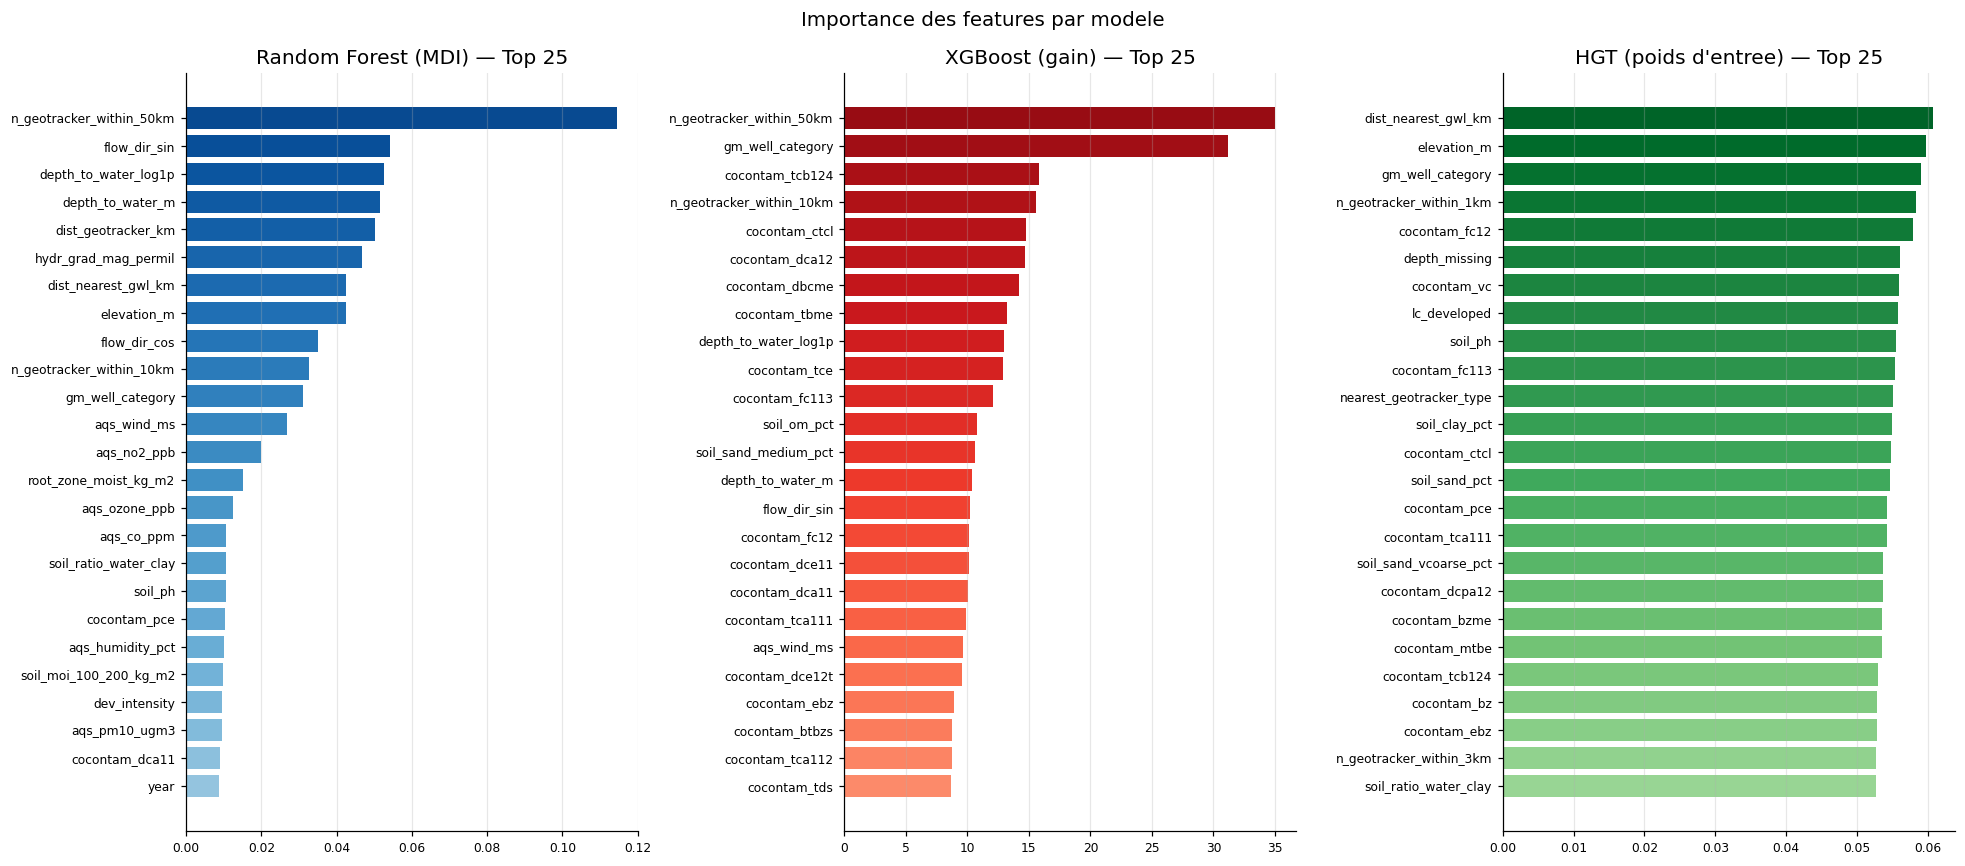

In [70]:
# ── Random Forest : importance MDI ──────────────────────────────────────
fi_rf = (pd.DataFrame({"feature": proc_cols, "imp_rf": rf.feature_importances_})
         .sort_values("imp_rf", ascending=False).reset_index(drop=True))
fi_rf["rank_rf"] = fi_rf.index + 1

# ── XGBoost : gain (mappe sur l'ordre des colonnes fI -> proc_cols) ─────
_gain = xgb_model.get_booster().get_score(importance_type="gain")
fi_xgb = (pd.DataFrame({"feature": proc_cols,
                        "imp_xgb": [_gain.get(f"f{i}", 0.0) for i in range(len(proc_cols))]})
          .sort_values("imp_xgb", ascending=False).reset_index(drop=True))
fi_xgb["rank_xgb"] = fi_xgb.index + 1

# ── HGT : norme L1 des poids d'entree du noeud 'sample' ────────────────
fi_hgt = None
if TORCH_GEOMETRIC_AVAILABLE:
    with torch.no_grad():
        _w = hgt_model.lin_dict["sample"].weight.detach().cpu().numpy()
    fi_hgt = (pd.DataFrame({"feature": proc_cols, "imp_hgt": np.abs(_w).mean(0)})
              .sort_values("imp_hgt", ascending=False).reset_index(drop=True))
    fi_hgt["rank_hgt"] = fi_hgt.index + 1

TOPN = 25
panels = [("Random Forest (MDI)", fi_rf, "imp_rf", "Blues"),
          ("XGBoost (gain)", fi_xgb, "imp_xgb", "Reds")]
if fi_hgt is not None:
    panels.append(("HGT (poids d'entree)", fi_hgt, "imp_hgt", "Greens"))
fig, axes = plt.subplots(1, len(panels), figsize=(6*len(panels), 8))
if len(panels) == 1: axes = [axes]
for ax, (title, fi, col, cmap) in zip(axes, panels):
    top = fi.head(TOPN)
    ax.barh(top["feature"][::-1], top[col][::-1],
            color=plt.get_cmap(cmap)(np.linspace(0.4, 0.9, TOPN)))
    ax.set_title(f"{title} — Top {TOPN}"); ax.grid(axis="x", alpha=.3); ax.tick_params(labelsize=8)
plt.suptitle("Importance des features par modele", fontsize=13)
plt.tight_layout(); savefig(fig, "fig40_importance_par_modele.png"); plt.show()

### 15.2 — Concordance des modeles (rang des 30 premieres features)

Pour chaque paire de modeles : nombre de features communes dans le **Top 30**, et
**correlation de rang de Spearman** sur l'ensemble des features (1 = classements identiques).

In [71]:
from scipy.stats import spearmanr

# table fusionnee des rangs
merged = fi_rf[["feature", "rank_rf"]].merge(fi_xgb[["feature", "rank_xgb"]], on="feature")
if fi_hgt is not None:
    merged = merged.merge(fi_hgt[["feature", "rank_hgt"]], on="feature")
rank_cols = [c for c in ["rank_rf", "rank_xgb", "rank_hgt"] if c in merged.columns]
merged["rank_moyen"] = merged[rank_cols].mean(axis=1)

# overlap Top 30 + Spearman par paire
TOP = 30
tops = {"RF": set(fi_rf.head(TOP)["feature"]), "XGB": set(fi_xgb.head(TOP)["feature"])}
if fi_hgt is not None:
    tops["HGT"] = set(fi_hgt.head(TOP)["feature"])
pairs = [("RF", "XGB")] + ([("RF", "HGT"), ("XGB", "HGT")] if fi_hgt is not None else [])
print(f"Concordance (Top {TOP}) :")
for a, b in pairs:
    inter = len(tops[a] & tops[b])
    ca, cb = {"RF": "rank_rf", "XGB": "rank_xgb", "HGT": "rank_hgt"}[a], {"RF": "rank_rf", "XGB": "rank_xgb", "HGT": "rank_hgt"}[b]
    rho = spearmanr(merged[ca], merged[cb]).correlation
    print(f"  {a:3s} vs {b:3s} : {inter:2d}/{TOP} features communes | Spearman rho = {rho:+.3f}")

if fi_hgt is not None:
    common_all = tops["RF"] & tops["XGB"] & tops["HGT"]
    print(f"\n  Communes aux 3 modeles (Top {TOP}) : {len(common_all)}")

# table des features communes RF n XGB, classees par rang moyen
common_rx = tops["RF"] & tops["XGB"]
tbl = (merged[merged["feature"].isin(common_rx)]
       .sort_values("rank_moyen")[["feature"] + rank_cols + ["rank_moyen"]]
       .reset_index(drop=True))
tbl.to_csv(RES_DIR / "concordance_importance.csv", index=False)
print(f"\nFeatures communes RF n XGB (Top {TOP}), classees par rang moyen :")
print(tbl.head(20).to_string(index=False))

Concordance (Top 30) :
  RF  vs XGB : 10/30 features communes | Spearman rho = +0.089
  RF  vs HGT :  7/30 features communes | Spearman rho = +0.052
  XGB vs HGT : 12/30 features communes | Spearman rho = +0.391

  Communes aux 3 modeles (Top 30) : 2

Features communes RF n XGB (Top 30), classees par rang moyen :
                 feature  rank_rf  rank_xgb  rank_hgt  rank_moyen
        gm_well_category       11         2         3    5.333333
        depth_to_water_m        4        14        27   15.000000
n_geotracker_within_10km       10         4        43   19.000000
n_geotracker_within_50km        1         1        57   19.666667
    depth_to_water_log1p        3         9        48   20.000000
            flow_dir_sin        2        15        44   20.333333
             aqs_wind_ms       12        20        36   22.666667
          cocontam_dca11       24        18        31   24.333333
      soil_texture_class       29        30        35   31.333333
             aqs_no2_ppb 

### 15.3 — Nuage des rangs (RF vs XGBoost)

Chaque point = une feature ; plus elle est proche de la diagonale, plus les deux modeles
s'accordent sur son importance. Les features du **Top 30 commun** sont mises en evidence.

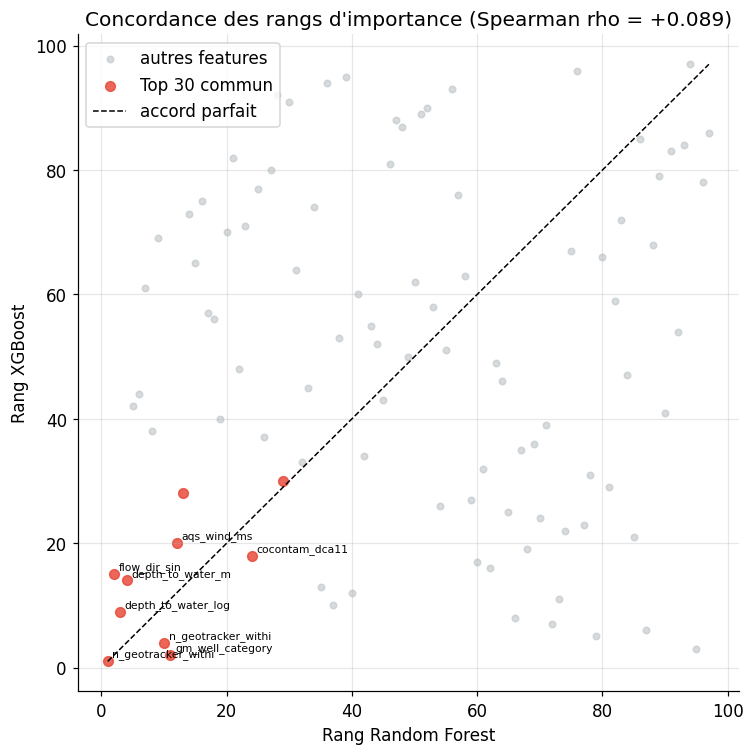

In [72]:
fig, ax = plt.subplots(figsize=(7, 7))
on_diag = merged["feature"].isin(common_rx)
ax.scatter(merged.loc[~on_diag, "rank_rf"], merged.loc[~on_diag, "rank_xgb"],
           s=18, c="#bdc3c7", alpha=.6, label="autres features")
ax.scatter(merged.loc[on_diag, "rank_rf"], merged.loc[on_diag, "rank_xgb"],
           s=40, c="#e74c3c", alpha=.85, label=f"Top {TOP} commun")
lim = len(proc_cols)
ax.plot([1, lim], [1, lim], "k--", lw=1, label="accord parfait")
# annoter les 8 features les mieux classees en moyenne
for _, r in tbl.head(8).iterrows():
    ax.annotate(r["feature"][:18], (r["rank_rf"], r["rank_xgb"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set(xlabel="Rang Random Forest", ylabel="Rang XGBoost",
       title=f"Concordance des rangs d'importance (Spearman rho = {spearmanr(merged.rank_rf, merged.rank_xgb).correlation:+.3f})")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig41_concordance_rangs.png"); plt.show()

## 16. Exploration pedagogique du HGT relationnel — « sous le capot »

Cette section ouvre la **boite noire** du graphe relationnel pour la soutenance : structure,
contenu exact de chaque **noeud** et **arete**, **voisinage d'un site** GeoTracker et d'un puits,
**calcul explicite d'une couche HGT** sur ce voisinage, cartographie geographique des liens et
projection 2D des embeddings. Tout est calcule sur le **graphe de test** deja construit.

### 16.1 — Vue d'ensemble du graphe (noeuds & aretes)

In [73]:
if TORCH_GEOMETRIC_AVAILABLE:
    g = test_data
    nodes_tbl = pd.DataFrame([
        {"type de noeud": nt, "nb noeuds": g[nt].num_nodes,
         "dim features": (g[nt].x.shape[1] if "x" in g[nt] else 0)}
        for nt in g.node_types])
    edges_tbl = pd.DataFrame([
        {"relation": f"{a} -[{b}]-> {c}", "nb aretes": g[a, b, c].edge_index.shape[1]}
        for a, b, c in g.edge_types])
    print("NOEUDS\n", nodes_tbl.to_string(index=False))
    print("\nARETES\n", edges_tbl.to_string(index=False))

NOEUDS
 type de noeud  nb noeuds  dim features
       sample       9268            97
       source        463             3
     subbasin        190             3
  geo_cluster         20             2

ARETES
                           relation  nb aretes
    sample -[near_source]-> source      31811
      source -[source_of]-> sample      31811
     sample -[in_basin]-> subbasin       9268
     subbasin -[basin_of]-> sample       9268
sample -[located_in]-> geo_cluster       9268
  geo_cluster -[contains]-> sample       9268
       sample -[near_geo]-> sample     148288


### 16.2 — Constitution de chaque noeud (features)

- **`sample`** (puits) : vecteur complet des features standardisees **sans localisation**.
- **`source`** (site GeoTracker) : `[lat_z, lon_z, type_z]` (position + type de site, standardises).
- **`subbasin`** (sous-bassin SGMA) : `[lat_moy, lon_moy, log(nb puits)]` standardises.
- **`geo_cluster`** : centre du cluster KMeans `(lat, lon)`.

In [74]:
if TORCH_GEOMETRIC_AVAILABLE:
    def describe_node(nt, names=None, k=8):
        x = g[nt].x
        print(f"\n[{nt}]  shape={tuple(x.shape)}")
        if names is not None:
            for nm, v in list(zip(names, x[0].cpu().numpy()))[:k]:
                print(f"    {nm:28s} = {v:+.3f}")
            if len(names) > k:
                print(f"    ... (+{len(names)-k} autres)")
    describe_node("sample", proc_cols)
    if "source" in g.node_types:   describe_node("source", ["lat (z)", "lon (z)", "type_site (z)"])
    if "subbasin" in g.node_types: describe_node("subbasin", ["lat_moy (z)", "lon_moy (z)", "log_nb_puits (z)"])
    if "geo_cluster" in g.node_types: describe_node("geo_cluster", ["centre_lat", "centre_lon"])


[sample]  shape=(9268, 97)
    dist_geotracker_km           = -0.513
    n_geotracker_within_1km      = -0.332
    n_geotracker_within_3km      = +0.359
    n_geotracker_within_10km     = -0.082
    n_geotracker_within_50km     = +0.181
    cocontam_btbzs               = -0.217
    cocontam_pbzn                = -0.107
    cocontam_edb                 = +0.110
    ... (+89 autres)

[source]  shape=(463, 3)
    lat (z)                      = +1.322
    lon (z)                      = -1.639
    type_site (z)                = -2.360

[subbasin]  shape=(190, 3)
    lat_moy (z)                  = +0.828
    lon_moy (z)                  = -1.237
    log_nb_puits (z)             = -0.816

[geo_cluster]  shape=(20, 2)
    centre_lat                   = +37.938
    centre_lon                   = -122.254


### 16.3 — Constitution de chaque arete

Le graphe relationnel **n'utilise pas** d'aretes-identite cosmetiques : chaque arete porte un
sens hydrogeologique ou spatial reel.

In [75]:
if TORCH_GEOMETRIC_AVAILABLE:
    SENS = {
        "near_source": "puits -> site GeoTracker dans le rayon (source potentielle)",
        "source_of":   "site -> puits qu'il peut contaminer (partage entre puits du meme site)",
        "in_basin":    "puits -> son sous-bassin SGMA",
        "basin_of":    "sous-bassin -> ses puits (hub hydrogeologique partage)",
        "located_in":  "puits -> son cluster geographique",
        "contains":    "cluster -> ses puits",
        "near_geo":    "puits <-> puits (k plus proches voisins geographiques)",
    }
    for a, b, c in g.edge_types:
        ei = g[a, b, c].edge_index
        ex = ei[:, :4].cpu().numpy().T.tolist()
        print(f"{a} -[{b}]-> {c} | {ei.shape[1]:>6} aretes | ex={ex}  {SENS.get(b,'')}")

sample -[near_source]-> source |  31811 aretes | ex=[[0, 85], [0, 6], [0, 171], [0, 247]]  puits -> site GeoTracker dans le rayon (source potentielle)
source -[source_of]-> sample |  31811 aretes | ex=[[85, 0], [6, 0], [171, 0], [247, 0]]  site -> puits qu'il peut contaminer (partage entre puits du meme site)
sample -[in_basin]-> subbasin |   9268 aretes | ex=[[0, 172], [1, 7], [2, 26], [3, 175]]  puits -> son sous-bassin SGMA
subbasin -[basin_of]-> sample |   9268 aretes | ex=[[172, 0], [7, 1], [26, 2], [175, 3]]  sous-bassin -> ses puits (hub hydrogeologique partage)
sample -[located_in]-> geo_cluster |   9268 aretes | ex=[[0, 12], [1, 6], [2, 1], [3, 12]]  puits -> son cluster geographique
geo_cluster -[contains]-> sample |   9268 aretes | ex=[[12, 0], [6, 1], [1, 2], [12, 3]]  cluster -> ses puits
sample -[near_geo]-> sample | 148288 aretes | ex=[[0, 0], [0, 4100], [0, 5068], [0, 2769]]  puits <-> puits (k plus proches voisins geographiques)


### 16.4 — Voisinage d'un **site GeoTracker** (entite partagee)

On choisit le site relie au plus grand nombre de puits du test, et on visualise
**geographiquement** le site et ses puits rattaches (rayon `SOURCE_RADIUS_KM`). C'est ce
couplage *par source* qui distingue le graphe relationnel.

Site #136 (Chrome Plater) en (34.072,-118.027) -> 429 puits rattaches (rayon 10.0 km)


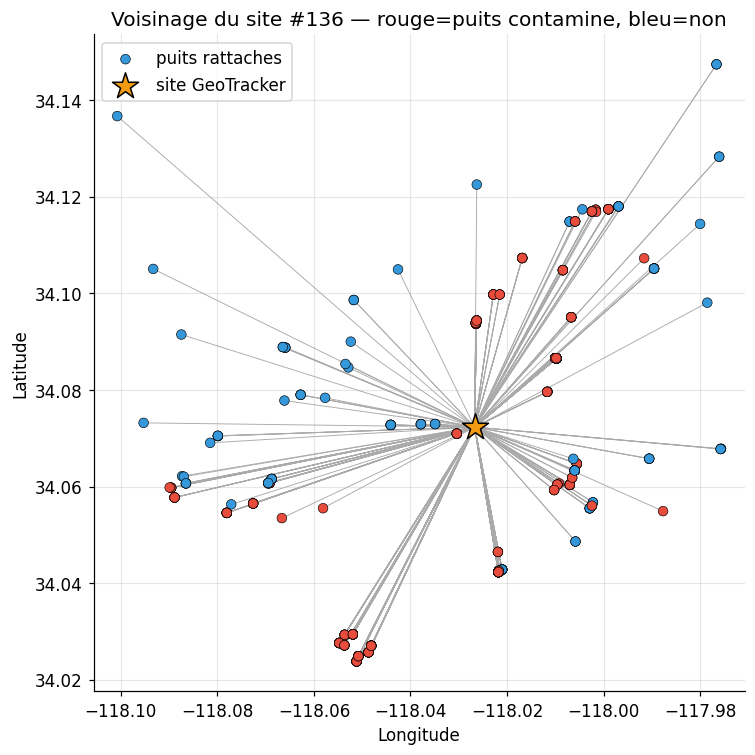

In [76]:
if TORCH_GEOMETRIC_AVAILABLE and "source" in g.node_types:
    ns_e = g["sample", "near_source", "source"].edge_index.cpu().numpy()  # [puits, site]
    sites_u, counts = np.unique(ns_e[1], return_counts=True)
    SITE = int(sites_u[np.argmax(counts)])                 # site le plus connecte
    wells = ns_e[0][ns_e[1] == SITE]
    slat, slon = sites_df.iloc[SITE]["latitude"], sites_df.iloc[SITE]["longitude"]
    stype = sites_df.iloc[SITE].get("site_type", "?")
    print(f"Site #{SITE} ({stype}) en ({slat:.3f},{slon:.3f}) -> {len(wells)} puits rattaches (rayon {SOURCE_RADIUS_KM} km)")
    wll = META_test.iloc[wells]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(wll["longitude"], wll["latitude"], s=40, c=["#e74c3c" if y_test[w]==1 else "#3498db" for w in wells],
               edgecolors="k", linewidths=.4, label="puits rattaches", zorder=3)
    for _, r in wll.iterrows():
        ax.plot([slon, r["longitude"]], [slat, r["latitude"]], c="#aaa", lw=.6, zorder=1)
    ax.scatter([slon], [slat], s=320, marker="*", c="#f39c12", edgecolors="k", label="site GeoTracker", zorder=4)
    ax.set(xlabel="Longitude", ylabel="Latitude", title=f"Voisinage du site #{SITE} — rouge=puits contamine, bleu=non")
    ax.legend(); ax.set_aspect("equal", "datalim"); ax.grid(alpha=.3)
    plt.tight_layout(); savefig(fig, "fig30_site_neighborhood.png"); plt.show()

### 16.5 — Voisinage d'un **puits** (sous-graphe heterogene)

Pour un puits contamine : ses **sites sources**, son **sous-bassin**, son **geo_cluster** et ses
**voisins KNN**. Visualisation du sous-graphe (couleur par type d'entite).

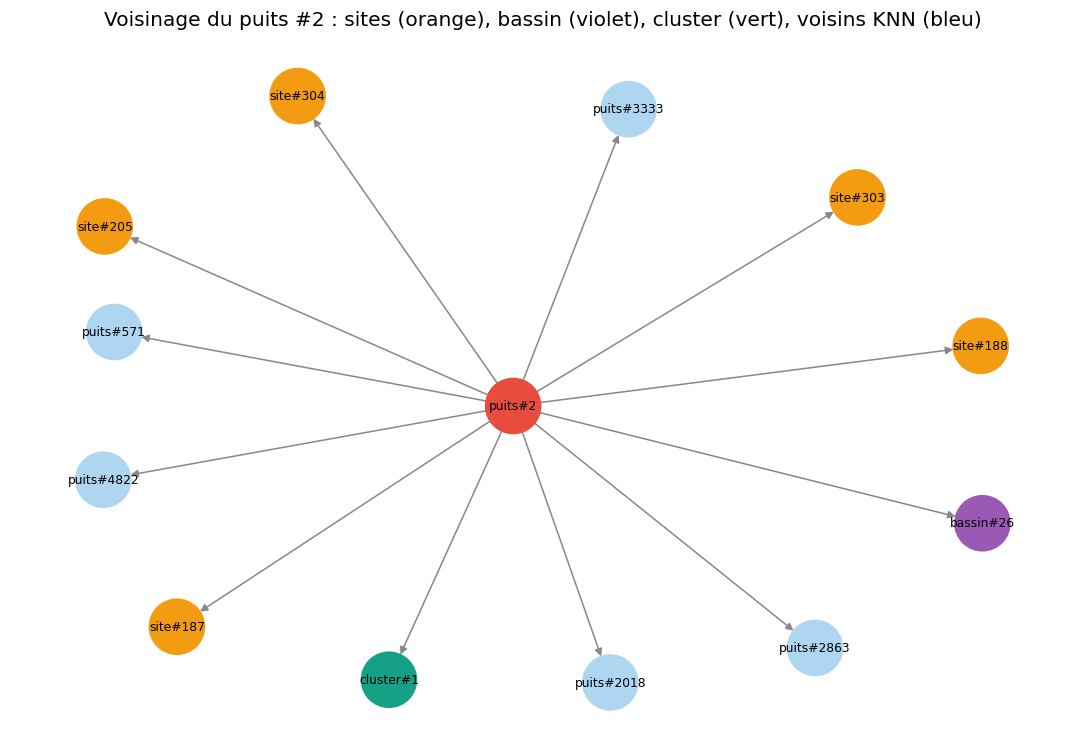

In [77]:
import networkx as nx
if TORCH_GEOMETRIC_AVAILABLE:
    FOCAL = int(np.where(y_test == 1)[0][0])
    G = nx.DiGraph(); col = {f"puits#{FOCAL}": "#e74c3c"}
    def _dst(rel, src_is_sample=True):
        a, b, c = rel
        ei = g[rel].edge_index.cpu().numpy()
        return ei[1][ei[0] == FOCAL] if src_is_sample else ei[0][ei[1] == FOCAL]
    if "source" in g.node_types:
        for s in _dst(("sample", "near_source", "source"))[:5]:
            G.add_edge(f"puits#{FOCAL}", f"site#{int(s)}"); col[f"site#{int(s)}"] = "#f39c12"
    for sb in _dst(("sample", "in_basin", "subbasin"))[:1]:
        G.add_edge(f"puits#{FOCAL}", f"bassin#{int(sb)}"); col[f"bassin#{int(sb)}"] = "#9b59b6"
    for cl in _dst(("sample", "located_in", "geo_cluster"))[:1]:
        G.add_edge(f"puits#{FOCAL}", f"cluster#{int(cl)}"); col[f"cluster#{int(cl)}"] = "#16a085"
    if ("sample", "near_geo", "sample") in g.edge_types:
        for v in _dst(("sample", "near_geo", "sample"))[:5]:
            if int(v) != FOCAL:
                G.add_edge(f"puits#{FOCAL}", f"puits#{int(v)}"); col.setdefault(f"puits#{int(v)}", "#aed6f1")
    fig, ax = plt.subplots(figsize=(10, 7))
    posn = nx.spring_layout(G, seed=RANDOM_STATE, k=0.9)
    nx.draw_networkx(G, posn, ax=ax, node_size=1300, font_size=8, arrows=True, edge_color="#888",
                     node_color=[col.get(n, "#ccc") for n in G.nodes()])
    ax.set_title(f"Voisinage du puits #{FOCAL} : sites (orange), bassin (violet), cluster (vert), voisins KNN (bleu)")
    ax.axis("off"); plt.tight_layout(); savefig(fig, "fig31_well_neighborhood.png"); plt.show()

### 16.6 — Calcul explicite d'**une couche HGT** sur ce voisinage

(1) **projection** lineaire par type de noeud + ReLU, (2) **une couche** `HGTConv`
(message-passing a attention par type de relation). On compare l'embedding du puits focal
avant/apres la couche, puis on **isole** le puits (coupe de ses aretes entrantes) pour mesurer
l'apport du voisinage relationnel.

dim embedding = 128
||h0[focal]|| (projection)   = 3.279
||h1[focal]|| (1 couche HGT)  = 3.534


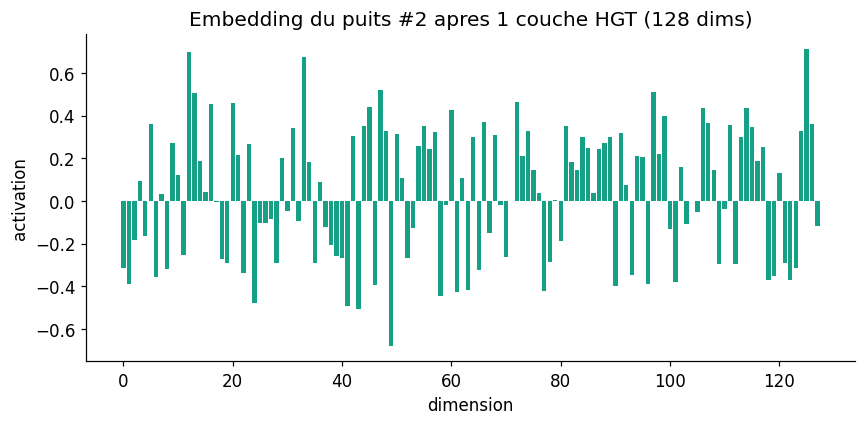


Proba AVEC voisinage : 0.984 | SANS voisinage (isole) : 0.570 | apport message-passing Delta = +0.414


In [78]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model.eval()
    xd, ed = graph_tensors(g)
    with torch.no_grad():
        h0 = {nt: hgt_model.lin_dict[nt](x).relu() for nt, x in xd.items()}
        h1 = hgt_model.convs[0](h0, ed)
    eb, ea = h0["sample"][FOCAL].cpu().numpy(), h1["sample"][FOCAL].cpu().numpy()
    print(f"dim embedding = {ea.shape[0]}")
    print(f"||h0[focal]|| (projection)   = {np.linalg.norm(eb):.3f}")
    print(f"||h1[focal]|| (1 couche HGT)  = {np.linalg.norm(ea):.3f}")

    ed_iso = {rel: (ei[:, ei[1] != FOCAL] if rel[2] == "sample" else ei) for rel, ei in ed.items()}
    with torch.no_grad():
        p_full = torch.softmax(hgt_model.classifier(h1["sample"][FOCAL:FOCAL+1]), 1)[0, 1].item()
        h1_iso = hgt_model.convs[0](h0, ed_iso)
        p_iso  = torch.softmax(hgt_model.classifier(h1_iso["sample"][FOCAL:FOCAL+1]), 1)[0, 1].item()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(len(ea)), ea, color="#16a085")
    ax.set(title=f"Embedding du puits #{FOCAL} apres 1 couche HGT ({len(ea)} dims)",
           xlabel="dimension", ylabel="activation")
    plt.tight_layout(); savefig(fig, "fig32_hgt_embedding.png"); plt.show()
    print(f"\nProba AVEC voisinage : {p_full:.3f} | SANS voisinage (isole) : {p_iso:.3f} "
          f"| apport message-passing Delta = {p_full - p_iso:+.3f}")

### 16.7 — Projection 2D des embeddings HGT (separation apprise)

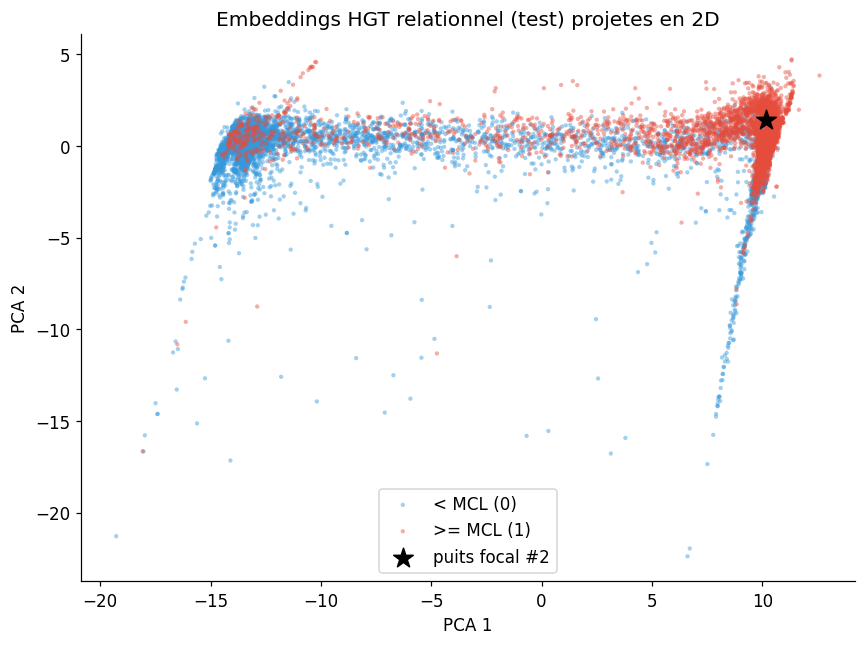

In [79]:
if TORCH_GEOMETRIC_AVAILABLE:
    emb_test = hgt_embeddings(hgt_model, test_data)
    p2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(emb_test)
    fig, ax = plt.subplots(figsize=(8, 6))
    for lab, c, nm in [(0, "#3498db", "< MCL (0)"), (1, "#e74c3c", ">= MCL (1)")]:
        m = y_test == lab
        ax.scatter(p2[m, 0], p2[m, 1], s=8, c=c, alpha=.45, label=nm, edgecolors="none")
    ax.scatter(p2[FOCAL, 0], p2[FOCAL, 1], s=180, marker="*", c="black", label=f"puits focal #{FOCAL}")
    ax.set(xlabel="PCA 1", ylabel="PCA 2", title="Embeddings HGT relationnel (test) projetes en 2D")
    ax.legend(); plt.tight_layout(); savefig(fig, "fig33_hgt_embeddings_2d.png"); plt.show()

## 17. Sauvegarde des artefacts

In [80]:
# --- Tableaux de resultats (JSON synthese) ---
summary = {
    "target": "EPA 2024 NPDWR (MCL individuels + Indice de Risque melange)",
    "dataset": {"n_total": int(len(df)), "n_features": len(feature_names),
                "n_num": len(num_cols), "n_cat": len(cat_cols),
                "n_pos": int(df['target'].sum()), "pct_pos": round(100*df['target'].mean(), 2)},
    "split": {"train": int(len(y_train)), "val": int(len(y_val)), "test": int(len(y_test))},
    "config": {"OPTUNA_MODE": OPTUNA_MODE, "EPOCHS_HGT": EPOCHS_HGT,
               "MISSING_THRESHOLD": MISSING_THRESHOLD, "USE_SMOTE": USE_SMOTE},
    "results": {m: {k: round(float(v), 4) for k, v in RESULTS[m]["metrics"].items() if k != "name"}
                for m in RESULTS},
    "best_model_f1": best,
}
with open(RES_DIR / "synthese_resultats.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

# --- Modeles ---
with open(MODELS_DIR / "random_forest.pkl", "wb") as f: pickle.dump(rf, f)
with open(MODELS_DIR / "xgboost.pkl", "wb") as f: pickle.dump(xgb_model, f)
with open(MODELS_DIR / "preprocessor.pkl", "wb") as f: pickle.dump(preprocessor, f)
with open(MODELS_DIR / "scaler.pkl", "wb") as f: pickle.dump(scaler, f)
if TORCH_GEOMETRIC_AVAILABLE:
    torch.save({"state_dict": hgt_model.state_dict(), "metadata": train_data.metadata(),
                "params": bp}, MODELS_DIR / "hgt.pt")
    with open(MODELS_DIR / "xgb_fusion.pkl", "wb") as f: pickle.dump(xgb_fusion, f)
    with open(MODELS_DIR / "meta_classifier.pkl", "wb") as f: pickle.dump(meta_clf, f)
comp.to_csv(RES_DIR / "comparaison_modeles.csv")
print("Artefacts sauvegardes dans", OUT_DIR.resolve())
print("Resultats :", json.dumps(summary["results"], indent=2, ensure_ascii=False))

Artefacts sauvegardes dans /content/outputs_notebook_relationnel
Resultats : {
  "Random Forest": {
    "roc_auc": 0.9786,
    "avg_precision": 0.9763,
    "accuracy": 0.9316,
    "balanced_accuracy": 0.9307,
    "precision": 0.9295,
    "recall": 0.9199,
    "f1": 0.9247
  },
  "XGBoost": {
    "roc_auc": 0.9766,
    "avg_precision": 0.9739,
    "accuracy": 0.9293,
    "balanced_accuracy": 0.9288,
    "precision": 0.9223,
    "recall": 0.9229,
    "f1": 0.9226
  },
  "HGT relationnel": {
    "roc_auc": 0.906,
    "avg_precision": 0.8857,
    "accuracy": 0.8401,
    "balanced_accuracy": 0.8392,
    "precision": 0.8226,
    "recall": 0.8284,
    "f1": 0.8255
  },
  "Embedding Fusion": {
    "roc_auc": 0.9599,
    "avg_precision": 0.9537,
    "accuracy": 0.8963,
    "balanced_accuracy": 0.8956,
    "precision": 0.8858,
    "recall": 0.8873,
    "f1": 0.8865
  },
  "Stacking": {
    "roc_auc": 0.9769,
    "avg_precision": 0.9741,
    "accuracy": 0.9311,
    "balanced_accuracy": 0.9307,
  

## 18. Telechargement des sorties (Colab)

Regroupe **toutes les figures et tableaux** dans une archive ZIP et la telecharge
automatiquement sur Colab (sinon indique le chemin local).

In [81]:
zip_path = Path(f"PFAS_HGT_relationnel_outputs_{time.strftime('%Y%m%d_%H%M')}.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (FIG_DIR, RES_DIR):
        for p in folder.rglob("*"):
            if p.is_file():
                zf.write(p, p.relative_to(OUT_DIR))
size_mb = zip_path.stat().st_size / 1e6
print(f"Archive creee : {zip_path}  ({size_mb:.1f} Mo)")
print(f"  - {len(list(FIG_DIR.glob('*.png')))} figures")
print(f"  - {len(list(RES_DIR.glob('*')))} tableaux de resultats")

if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))
else:
    print(f"\n(Local) Archive disponible : {zip_path.resolve()}")

Archive creee : PFAS_HGT_relationnel_outputs_20260627_1230.zip  (4.6 Mo)
  - 41 figures
  - 3 tableaux de resultats


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 19. Conclusion

Cinq approches comparees pour la classification du risque PFAS (cible **EPA 2024 NPDWR**), en
**mode predictif** (sans concentrations PFAS) et surtout **sans aucune feature de
localisation** — la geographie n'entre que par la **structure du graphe** HGT :

1. **HGT relationnel** — entites partagees (sites GeoTracker, sous-bassins SGMA, clusters) + aretes spatiales KNN ;
2. **Random Forest** (sans localisation) — baseline tabulaire ;
3. **XGBoost** (sans localisation) — reference tabulaire ;
4. **Embedding Fusion** — embeddings HGT (PCA) + features -> XGBoost ;
5. **Stacking** — meta-classifieur sur (HGT + XGBoost + RandomForest).

**Enseignements** :
- En **retirant la localisation des features**, on supprime la principale source de
  *memorisation geographique*. Les modeles tabulaires restent solides grace aux features
  mecanistes (proximite des sources, sol, hydrogeologie, co-contaminants).
- Le **HGT relationnel** porte le signal spatial **par la topologie** (sites/sous-bassins
  partages, voisinage KNN) plutot que par des coordonnees brutes : c'est la facon la plus
  defendable d'injecter la geographie sans la memoriser. Ses embeddings nourrissent la
  **fusion** et le **stacking**.
- **Rigueur & interpretabilite** : chaque modele est optimise par **Optuna**, diagnostique
  par sa **courbe d'apprentissage** et sa **matrice de confusion**, et explique par **SHAP
  global ET local** (waterfall par puits ; gradients pour le HGT). La section **CV spatiale**
  donne la metrique de generalisation honnete (**AUC hors-zone**).

> **Lecture** : comparer ce notebook (HGT relationnel, features sans localisation) au notebook
> precedent (HGT a noeuds-attributs, features avec localisation) quantifie l'apport reel de la
> **structure relationnelle** une fois la memorisation spatiale neutralisee.